In [2]:
import pandas as pd

df = pd.read_excel('BASE_1_Manga_Produtos.xlsx')

In [3]:
df.isnull().sum()

empresa                                        91
faturamento_empresa_brl                        76
produto                                        94
tipo_cliente                                   90
mercado_principal                              80
indice_concorrencia_1a5                        84
indice_valor_agregado_1a5                      98
margem_media_percentual                        79
indice_complexidade_produtiva_1a5              78
indice_capex_1a5                               91
indice_escalabilidade_1a5                      90
indice_exigencia_regulatoria_1a5               69
certificacoes_principais                       79
indice_compatibilidade_refugo_1a5              87
indice_compatibilidade_operacao_fazenda_1a5    67
dtype: int64

In [4]:
df = df.dropna(subset=['produto'])
df.isnull().sum()

empresa                                        85
faturamento_empresa_brl                        72
produto                                         0
tipo_cliente                                   86
mercado_principal                              78
indice_concorrencia_1a5                        82
indice_valor_agregado_1a5                      92
margem_media_percentual                        72
indice_complexidade_produtiva_1a5              75
indice_capex_1a5                               85
indice_escalabilidade_1a5                      86
indice_exigencia_regulatoria_1a5               68
certificacoes_principais                       75
indice_compatibilidade_refugo_1a5              80
indice_compatibilidade_operacao_fazenda_1a5    65
dtype: int64

In [5]:
categorias = {
    "Alimentos & Bebidas (Produto Final)": [
        "Sorbet / picolé",
        "Suco pronto (NFC)",
        "Cubos IQF",
        "Geleia/compota",
        "Chutney de manga",
        "Molho agridoce / culinário",
        "Snack de manga desidratada",
        "Manga desidratada em pedacos",
        "Manga desidratada em pedaços",
        "Bebida funcional com manga",
        "Bebida alcoólica / fermentado"
    ],

    "Ingredientes Alimentícios & Funcionais (B2B)": [
        "Concentrado de manga",
        "Polpa congelada",
        "Purê de manga asséptico",
        "Base para néctar",
        "Pectina",
        "Fibra alimentar de manga",
        "Ingrediente antioxidante",
        "Corante natural",
        "Aroma / extrato natural",
        "Pó de manga (spray-dried)"
    ],

    "Cosméticos, Higiene & Perfumaria": [
        "Base cosmética (extrato)",
        "Esfoliante natural",
        "Sabonete / hidratante com manga",
        "Fragrância para perfumaria",
        "Óleo / manteiga de semente de manga"
    ],

    "Sustentabilidade, Energia & Bioinsumos": [
        "Biogás / energia",
        "Subproduto industrial de bagaço processado",
        "Biocomposto / fertilizante orgânico"
    ],

    "Nutrição Animal & Agro": [
        "Ração / ingrediente para ração animal"
    ]
}


def classificar_categoria(produto):
    for categoria, produtos in categorias.items():
        if produto in produtos:
            return categoria
    return "Categoria não definida"

df["categoria"] = df["produto"].apply(classificar_categoria)

df["categoria"].value_counts()

categoria
Ingredientes Alimentícios & Funcionais (B2B)    593
Alimentos & Bebidas (Produto Final)             548
Cosméticos, Higiene & Perfumaria                266
Sustentabilidade, Energia & Bioinsumos          154
Nutrição Animal & Agro                           45
Name: count, dtype: int64

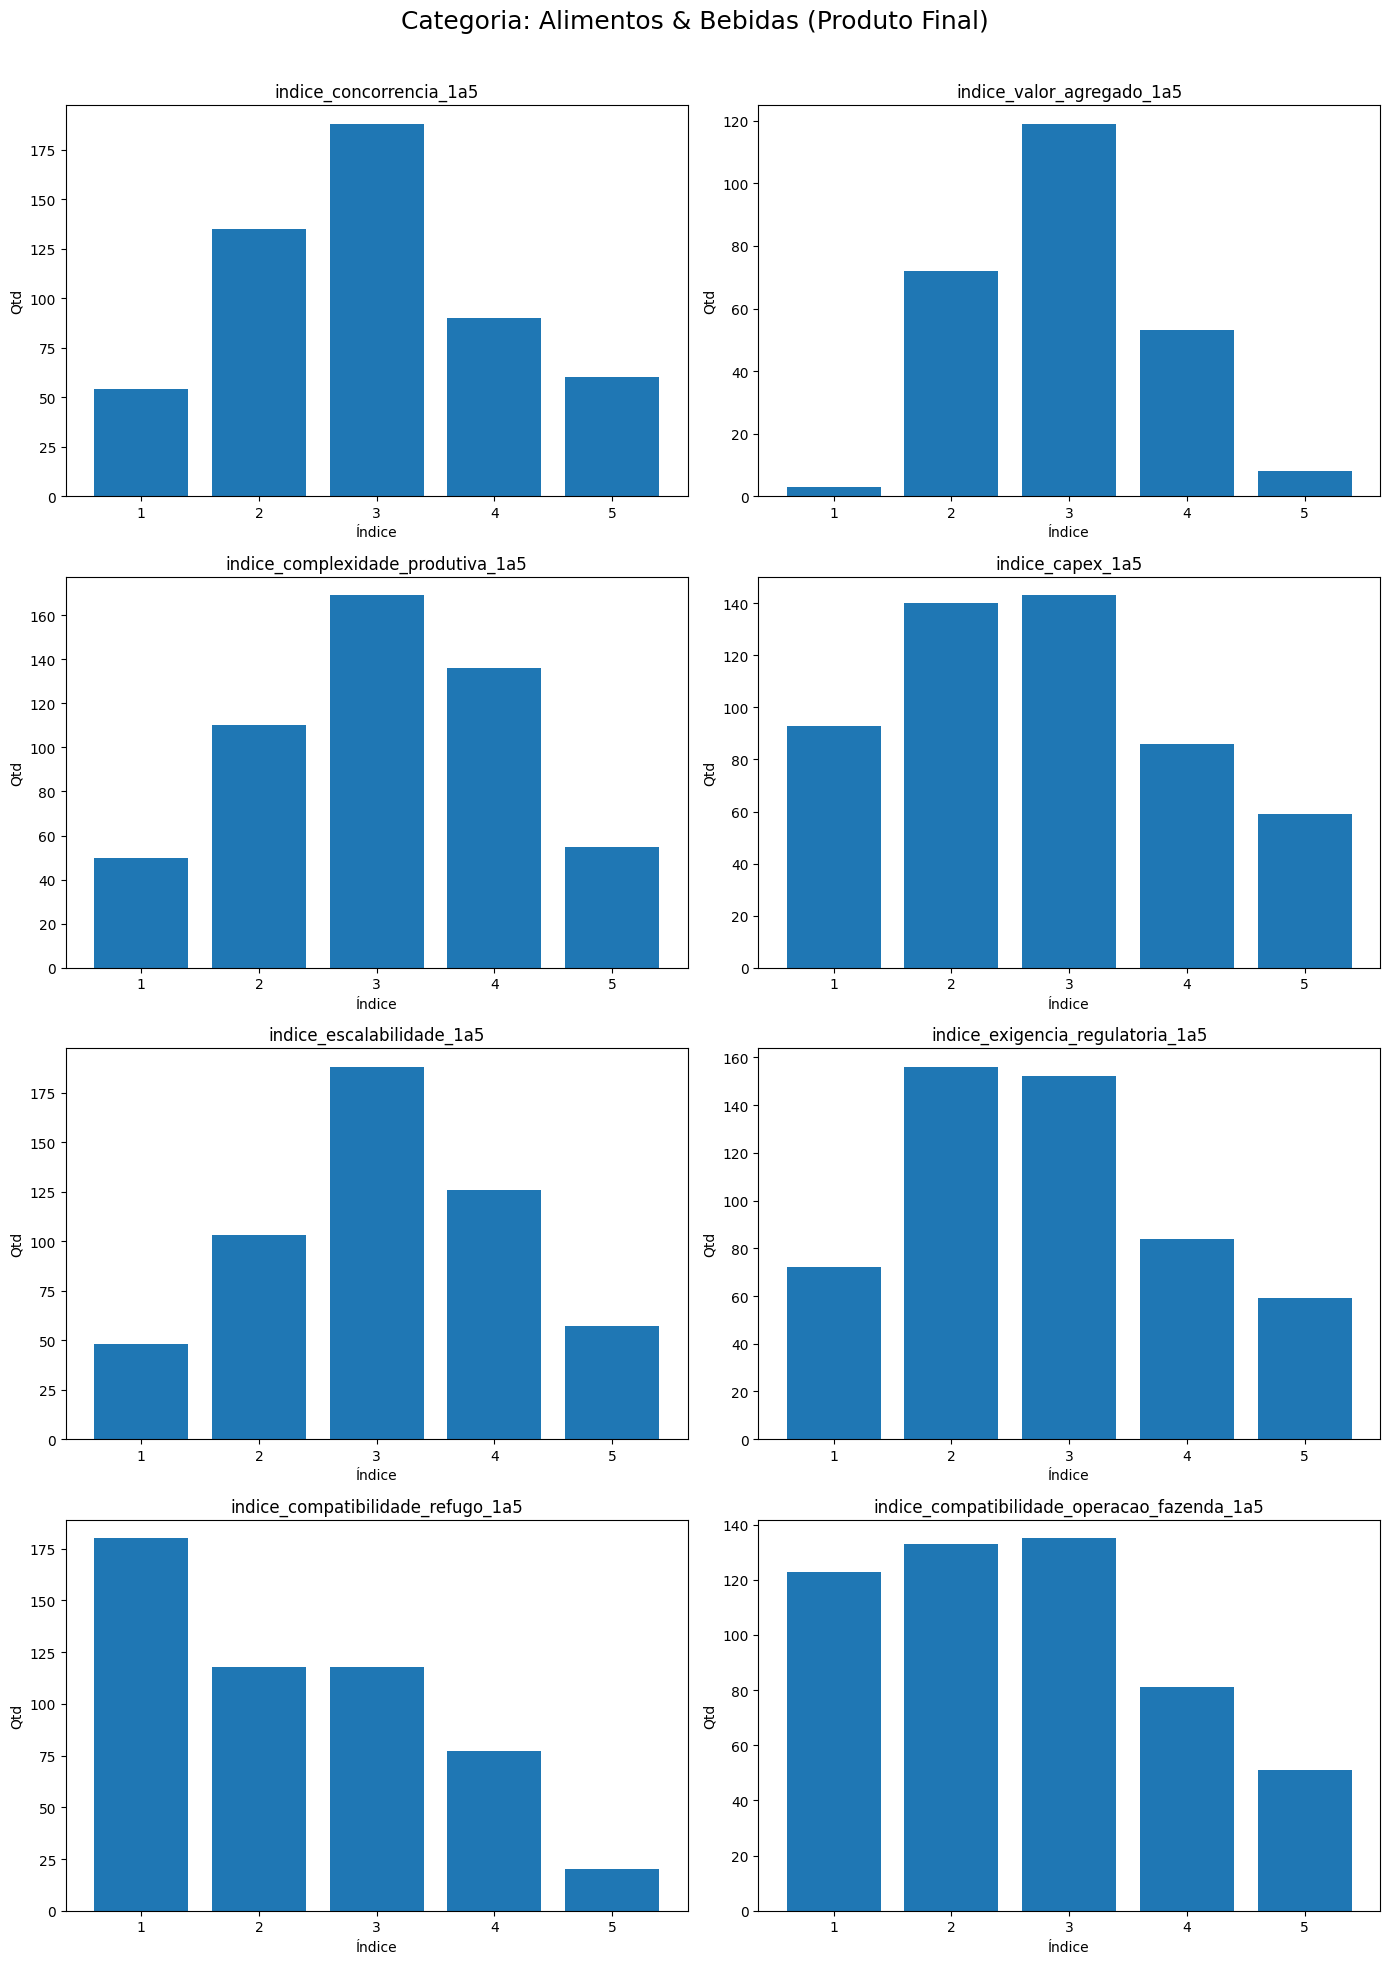

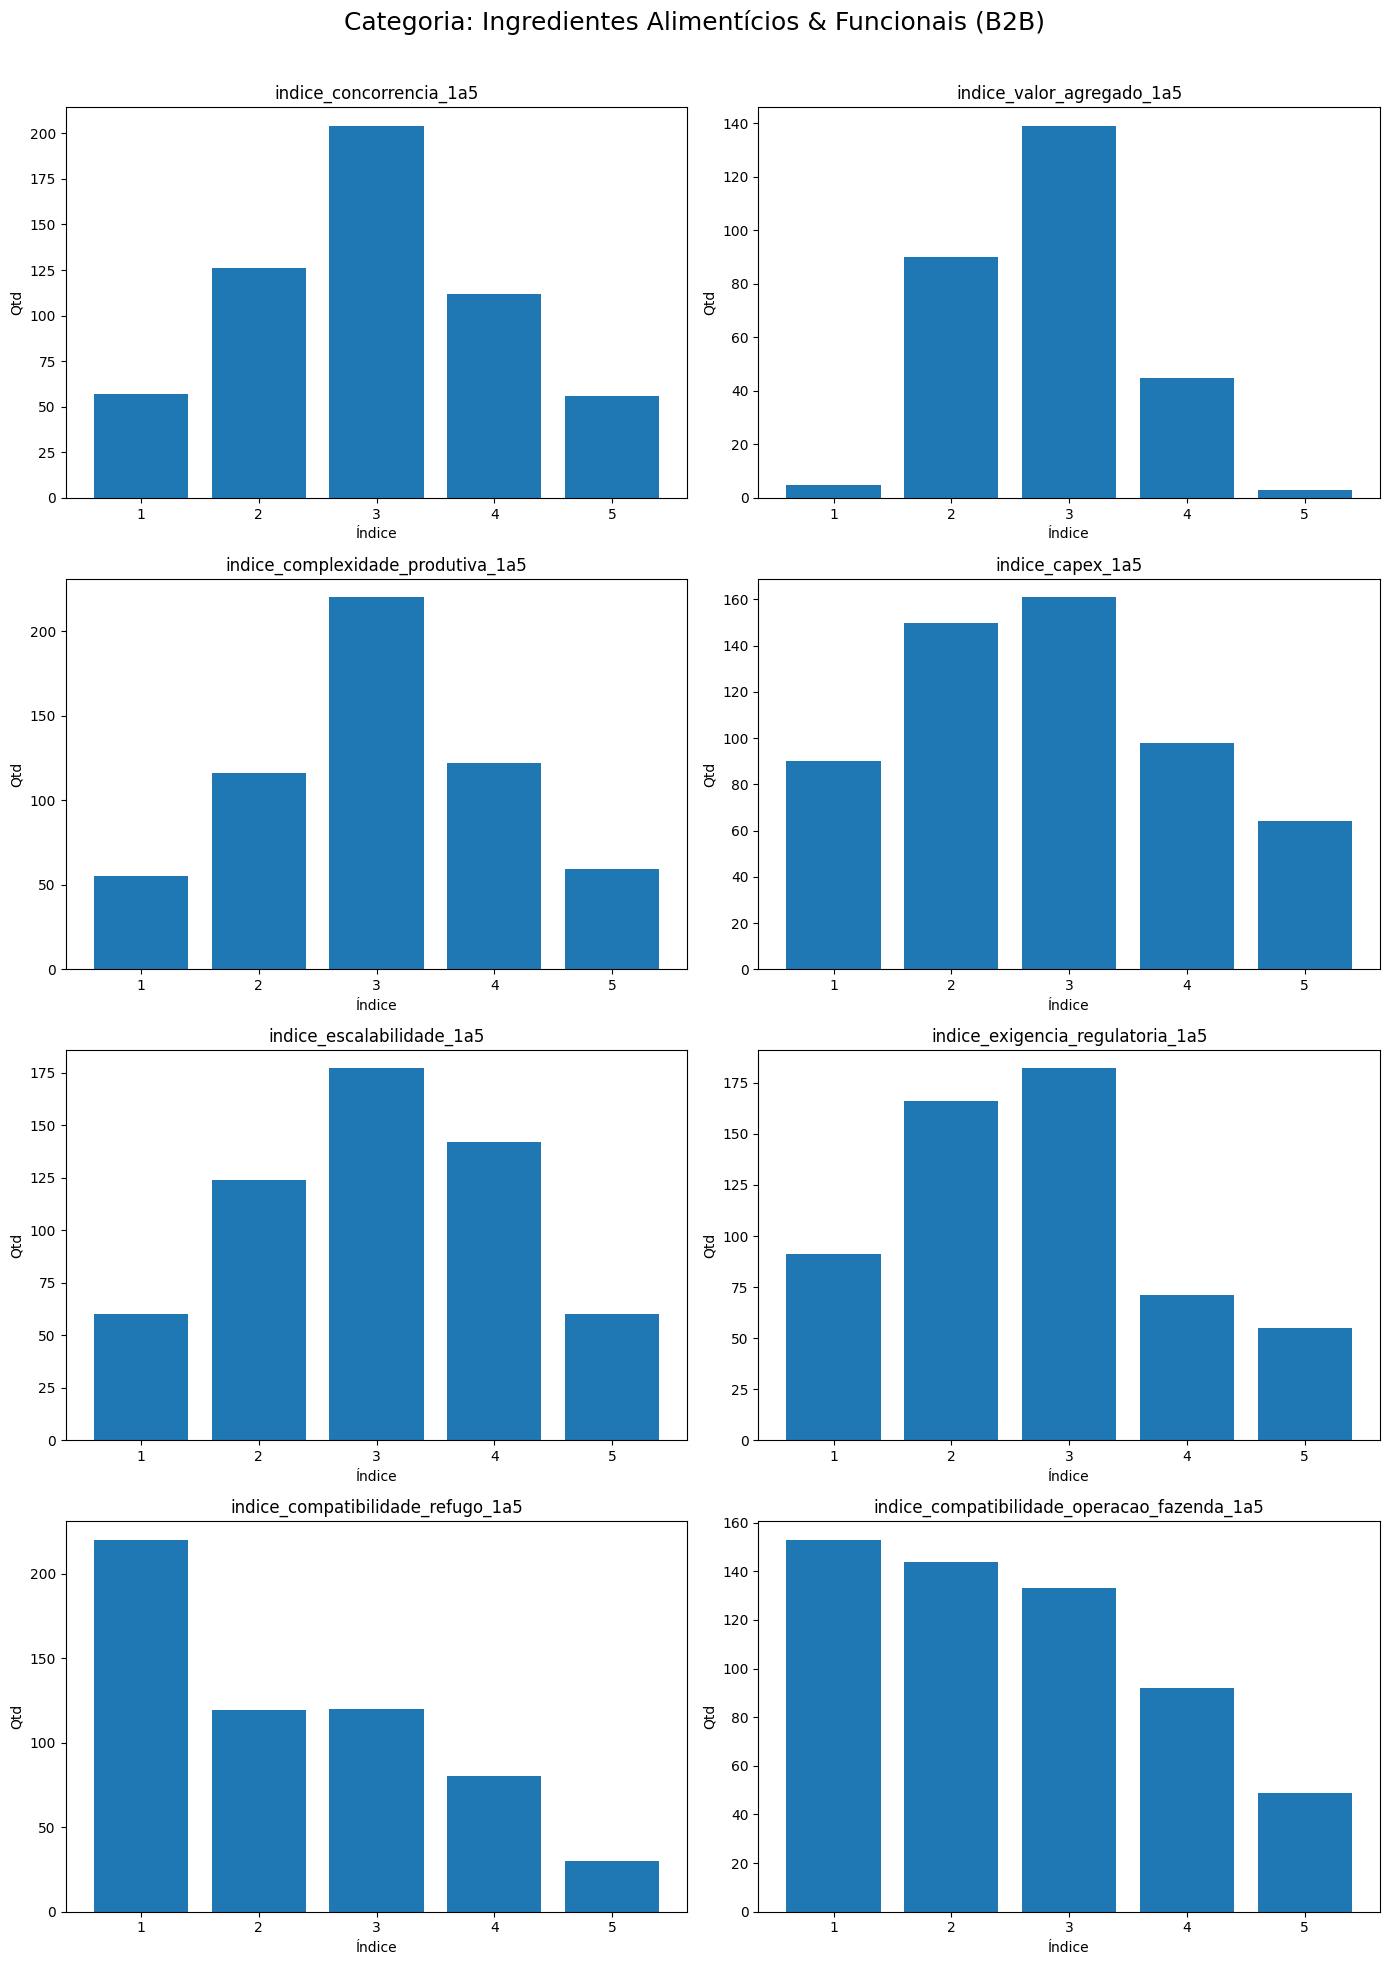

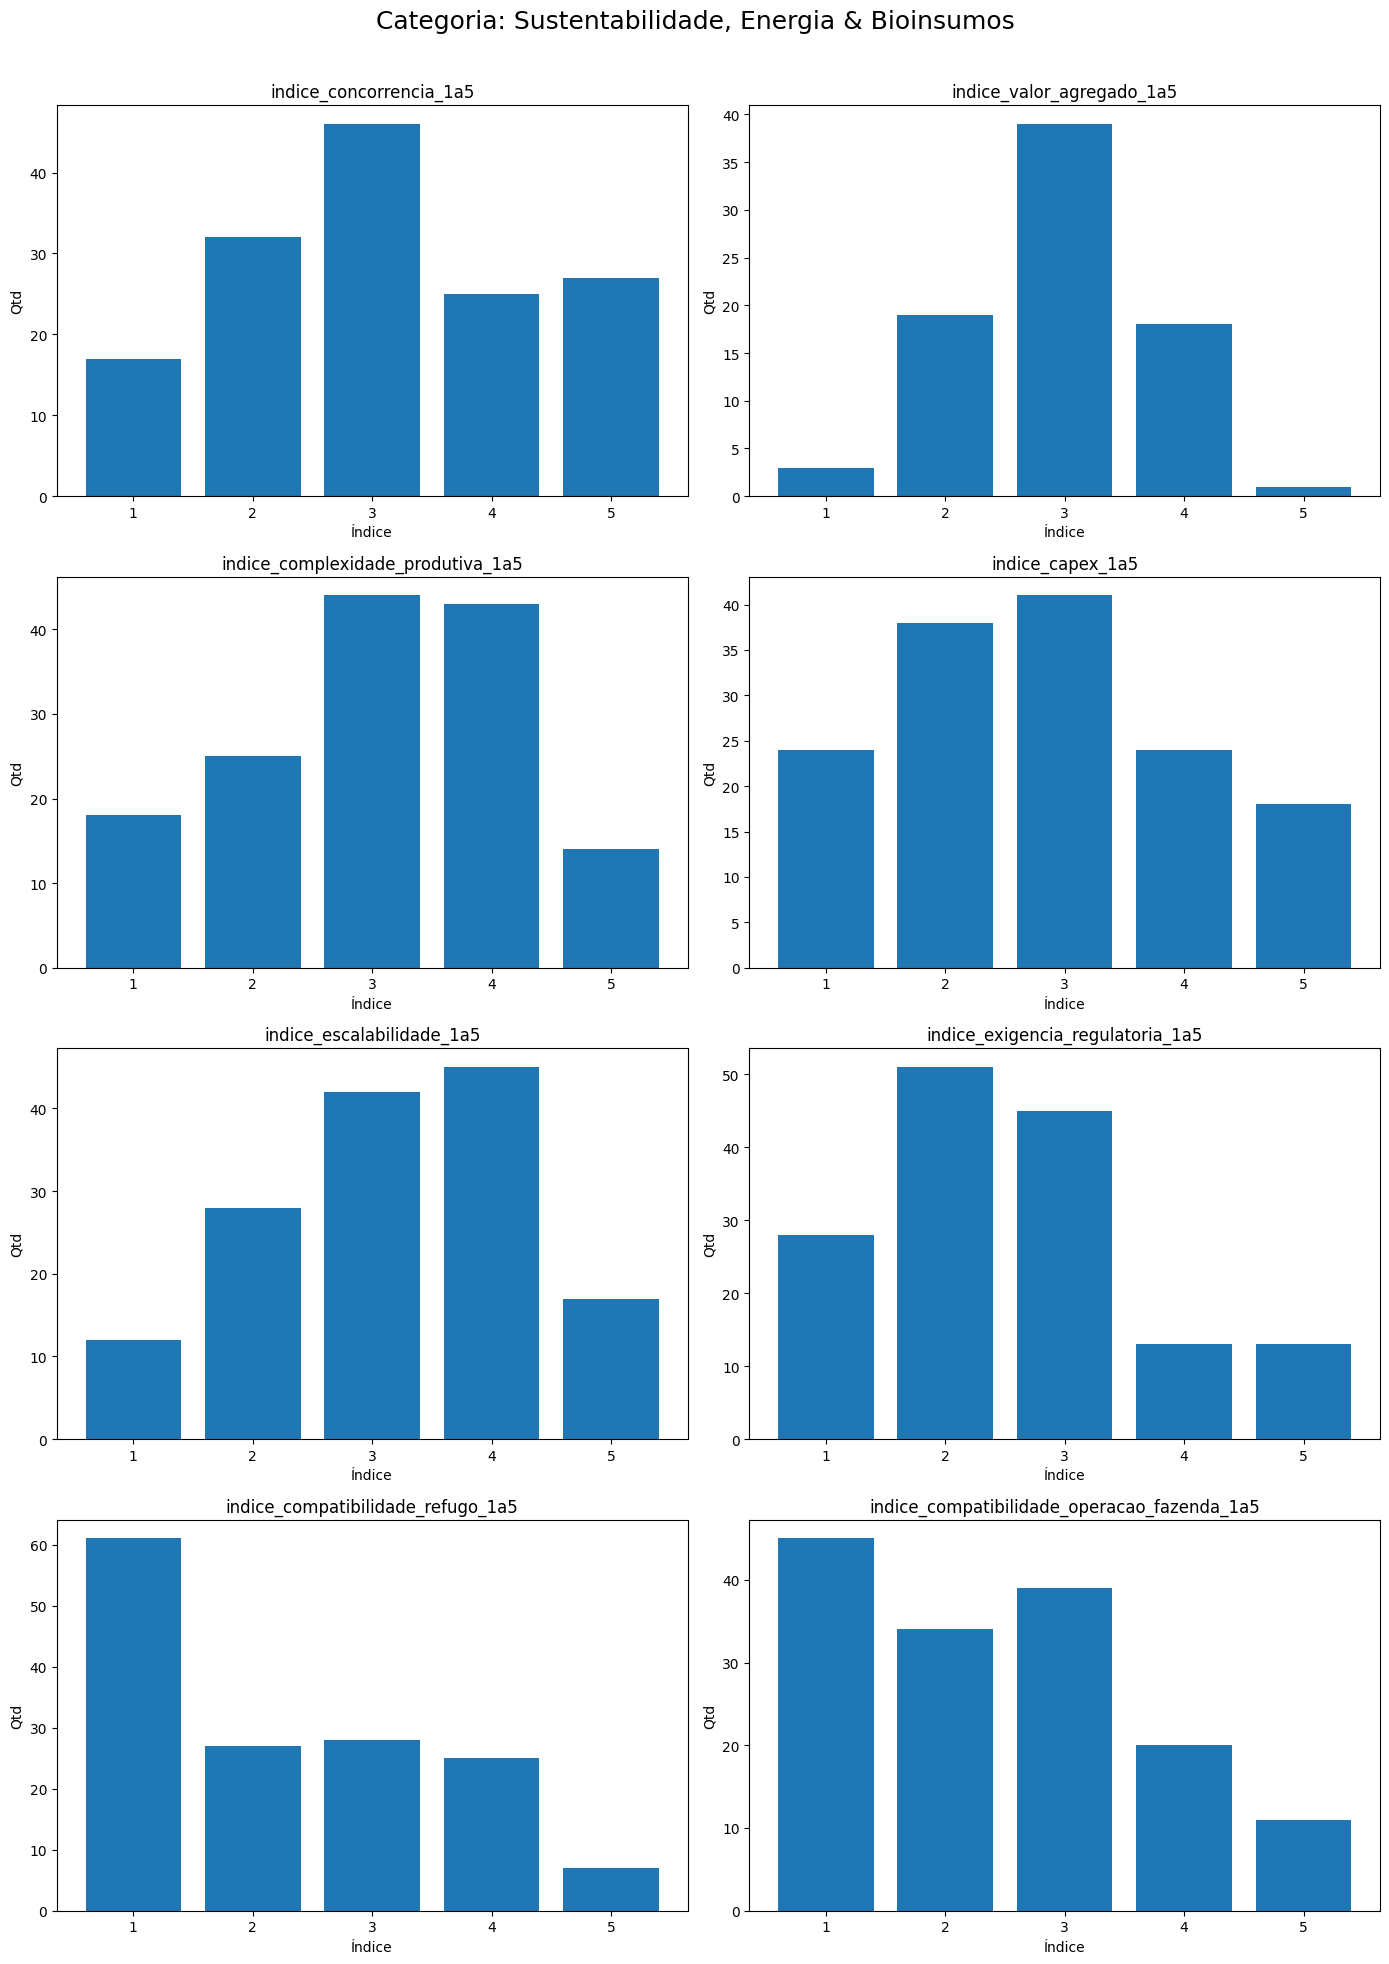

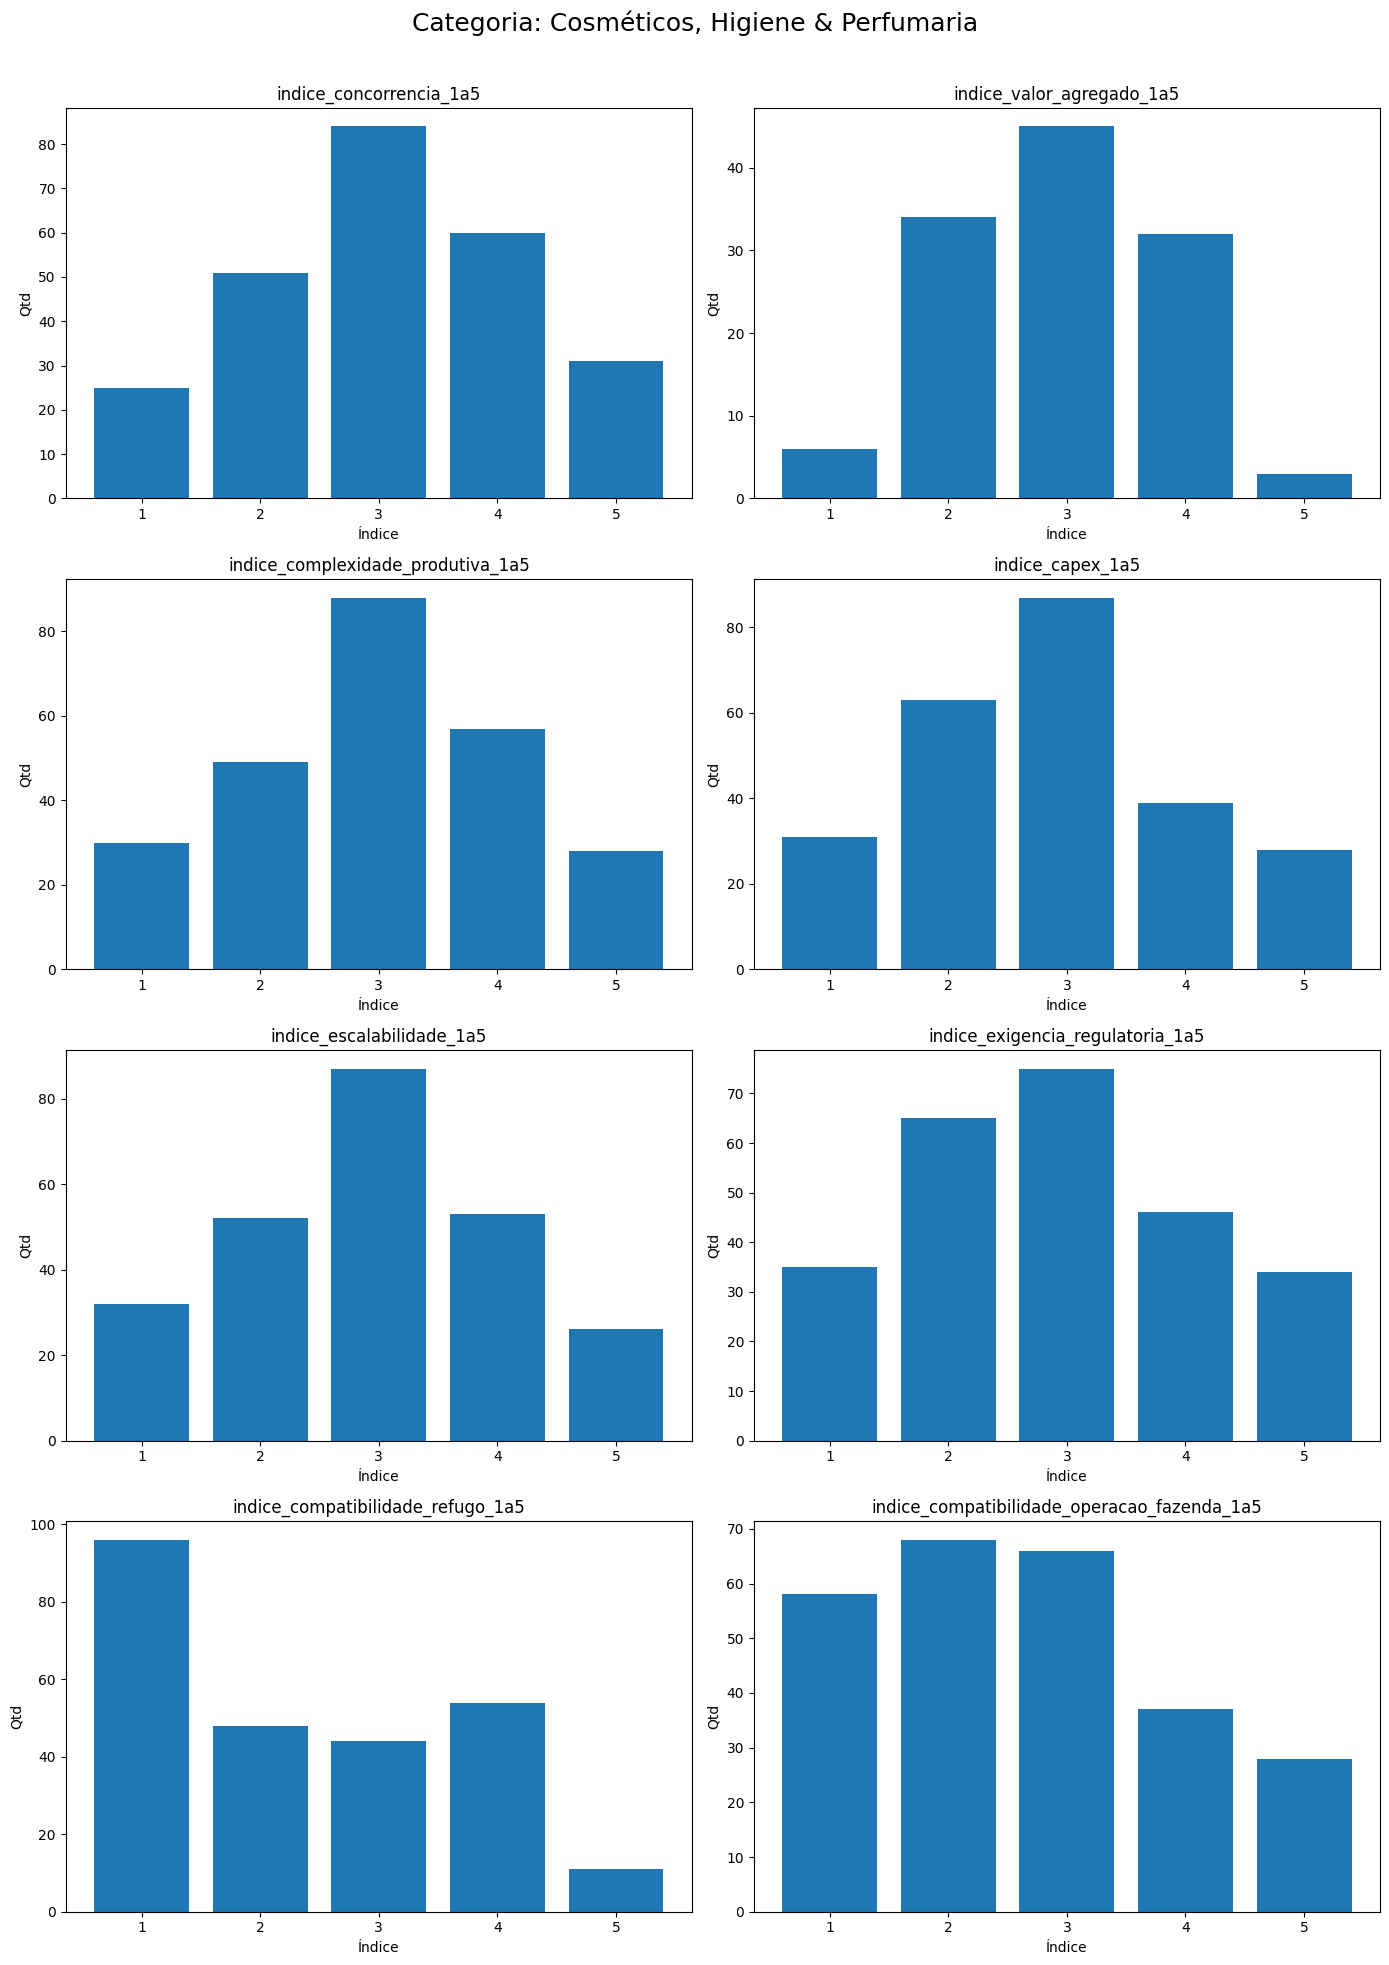

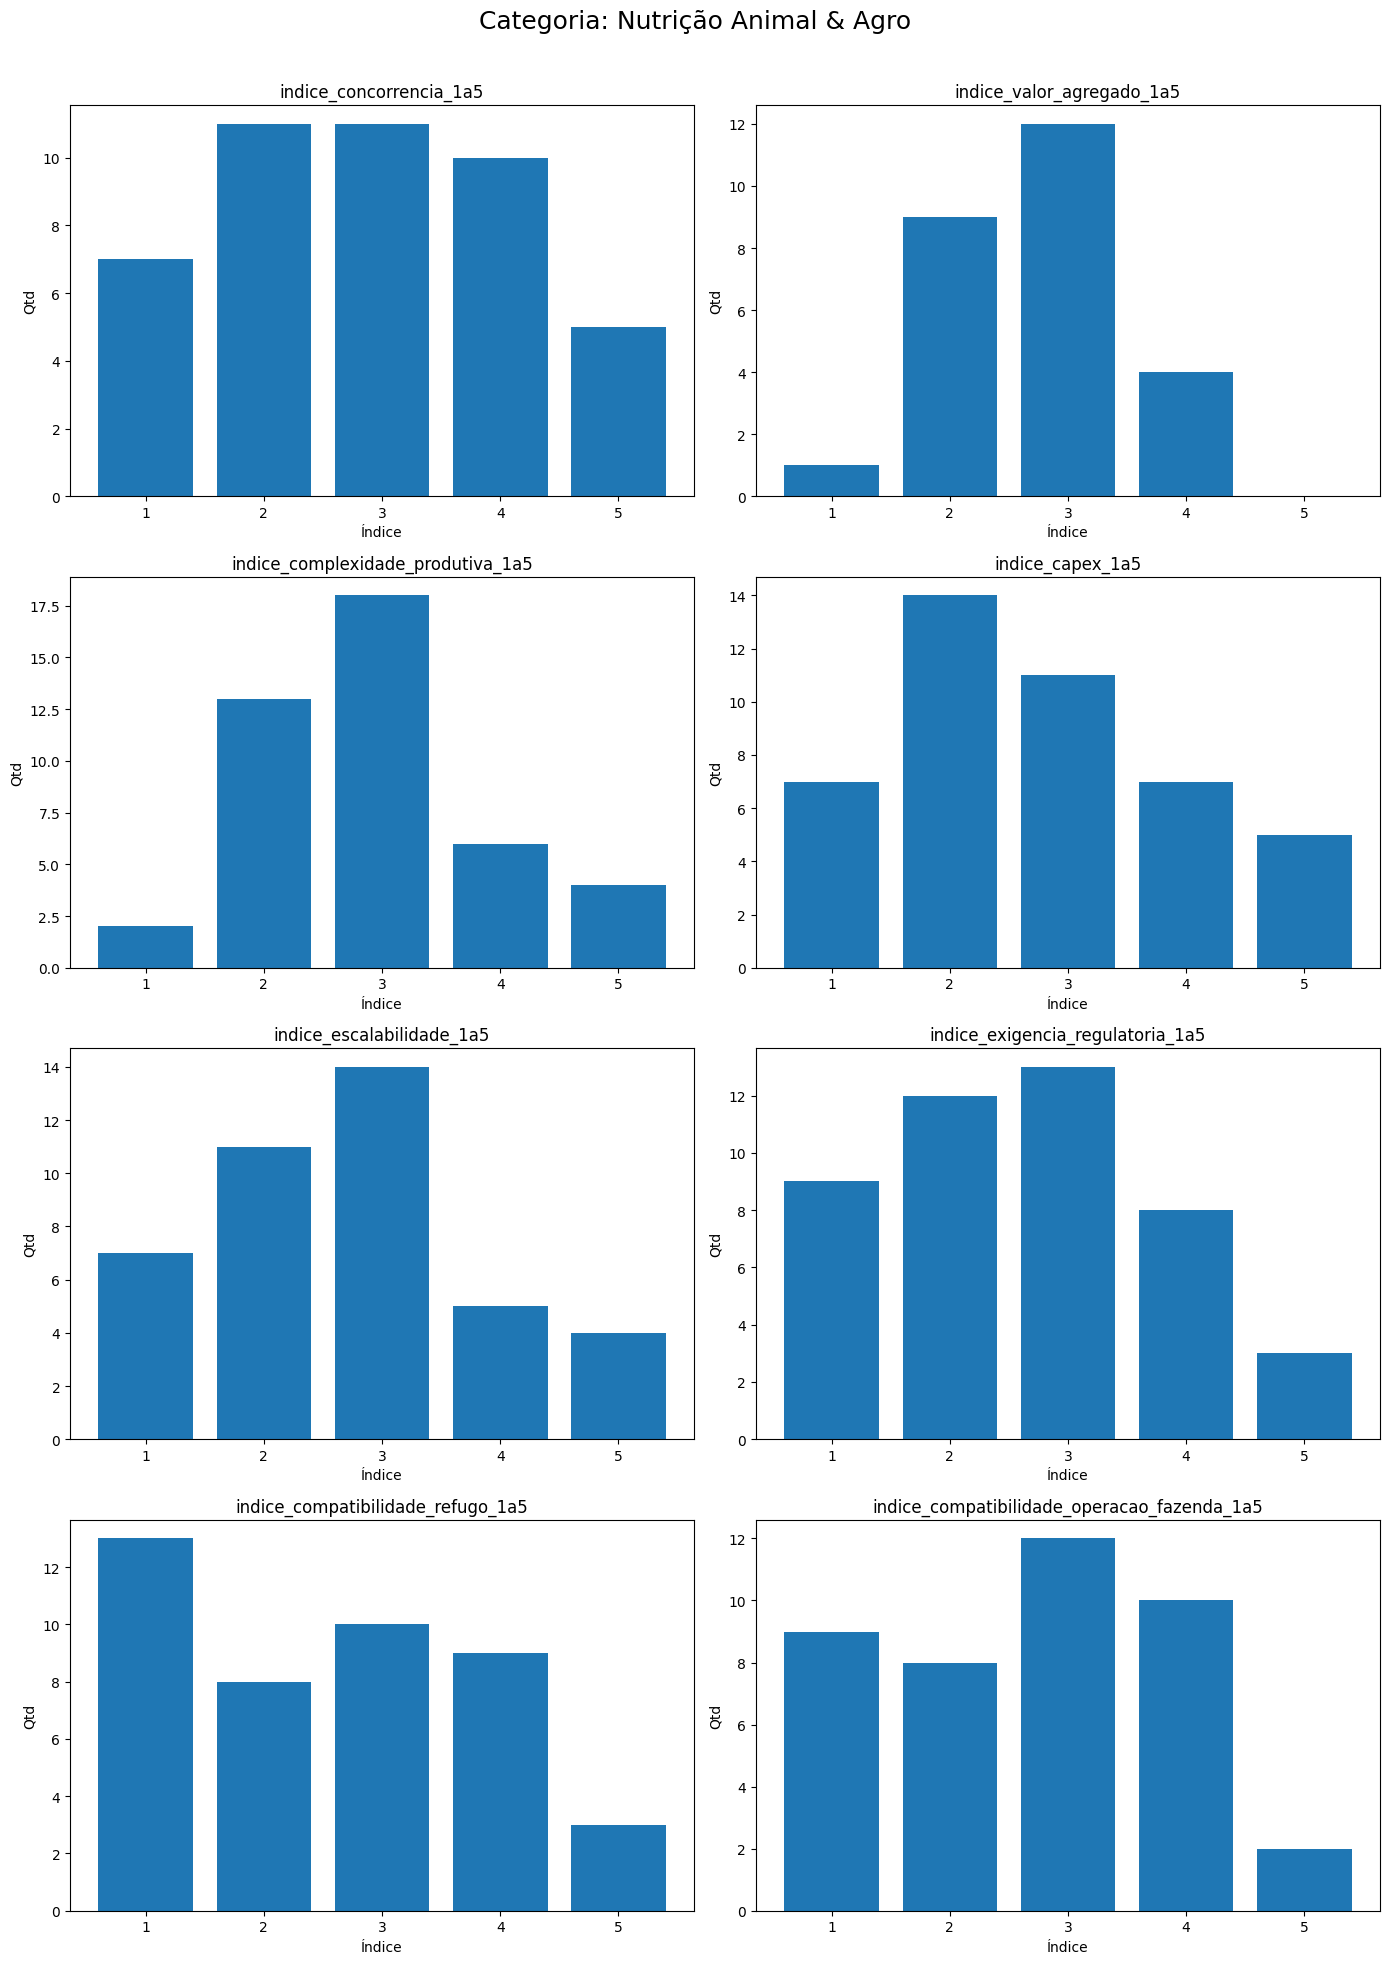

In [6]:
import matplotlib.pyplot as plt

# lista dos índices que você quer plotar
indices = [
    'indice_concorrencia_1a5',
    'indice_valor_agregado_1a5',
    'indice_complexidade_produtiva_1a5',
    'indice_capex_1a5',
    'indice_escalabilidade_1a5',
    'indice_exigencia_regulatoria_1a5',
    'indice_compatibilidade_refugo_1a5',
    'indice_compatibilidade_operacao_fazenda_1a5'
]

# valores possíveis do índice
bins = [1, 2, 3, 4, 5]

# loop por categoria
for categoria in df['categoria'].unique():

    df_cat = df[df['categoria'] == categoria]

    fig, axes = plt.subplots(4, 2, figsize=(14, 20))
    axes = axes.flatten()

    for i, indice in enumerate(indices):
        contagem = (
            df_cat[indice]
            .value_counts()
            .reindex(bins, fill_value=0)
            .sort_index()
        )

        axes[i].bar(contagem.index, contagem.values)
        axes[i].set_title(indice)
        axes[i].set_xlabel('Índice')
        axes[i].set_ylabel('Qtd')

    # remove eixos vazios (se sobrar)
    for j in range(len(indices), len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(f'Categoria: {categoria}', fontsize=18)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()


In [7]:
# ================================
# IMPUTAÇÃO DE DADOS FALTANTES
# MCAR vs MAR
# ================================

# ----------------
# 1) Colunas MCAR
# ----------------
colunas_indices = [
    'margem_media_percentual',
    'indice_concorrencia_1a5',
    'indice_valor_agregado_1a5',
    'indice_complexidade_produtiva_1a5',
    'indice_capex_1a5',
    'indice_escalabilidade_1a5',
    'indice_exigencia_regulatoria_1a5',
    'indice_compatibilidade_refugo_1a5',
    'indice_compatibilidade_operacao_fazenda_1a5'
]

print("Valores nulos ANTES (índices):")
print(df[colunas_indices].isna().sum())

# imputação MCAR → média por categoria
df[colunas_indices] = (
    df
    .groupby('categoria')[colunas_indices]
    .transform(lambda x: x.fillna(x.mean()))
)

# fallback: média global (caso categoria inteira seja NaN)
df[colunas_indices] = df[colunas_indices].fillna(df[colunas_indices].mean())

print("\nValores nulos DEPOIS (índices):")
print(df[colunas_indices].isna().sum())


# ----------------
# 2) Faturamento (MAR)
# ----------------
print("\nValores nulos ANTES (faturamento):")
print(df['faturamento_empresa_brl'].isna().sum())

# imputação MAR → média condicionada ao PRODUTO
df['faturamento_empresa_brl'] = (
    df
    .groupby('produto')['faturamento_empresa_brl']
    .transform(lambda x: x.fillna(x.mean()))
)

# fallback final: média global (caso produto inteiro seja NaN)
df['faturamento_empresa_brl'] = df['faturamento_empresa_brl'].fillna(
    df['faturamento_empresa_brl'].mean()
)

print("\nValores nulos DEPOIS (faturamento):")
print(df['faturamento_empresa_brl'].isna().sum())


Valores nulos ANTES (índices):
margem_media_percentual                        72
indice_concorrencia_1a5                        82
indice_valor_agregado_1a5                      92
indice_complexidade_produtiva_1a5              75
indice_capex_1a5                               85
indice_escalabilidade_1a5                      86
indice_exigencia_regulatoria_1a5               68
indice_compatibilidade_refugo_1a5              80
indice_compatibilidade_operacao_fazenda_1a5    65
dtype: int64

Valores nulos DEPOIS (índices):
margem_media_percentual                        0
indice_concorrencia_1a5                        0
indice_valor_agregado_1a5                      0
indice_complexidade_produtiva_1a5              0
indice_capex_1a5                               0
indice_escalabilidade_1a5                      0
indice_exigencia_regulatoria_1a5               0
indice_compatibilidade_refugo_1a5              0
indice_compatibilidade_operacao_fazenda_1a5    0
dtype: int64

Valores nulos ANTE

In [8]:
df.isnull().sum()

empresa                                        85
faturamento_empresa_brl                         0
produto                                         0
tipo_cliente                                   86
mercado_principal                              78
indice_concorrencia_1a5                         0
indice_valor_agregado_1a5                       0
margem_media_percentual                         0
indice_complexidade_produtiva_1a5               0
indice_capex_1a5                                0
indice_escalabilidade_1a5                       0
indice_exigencia_regulatoria_1a5                0
certificacoes_principais                       75
indice_compatibilidade_refugo_1a5               0
indice_compatibilidade_operacao_fazenda_1a5     0
categoria                                       0
dtype: int64

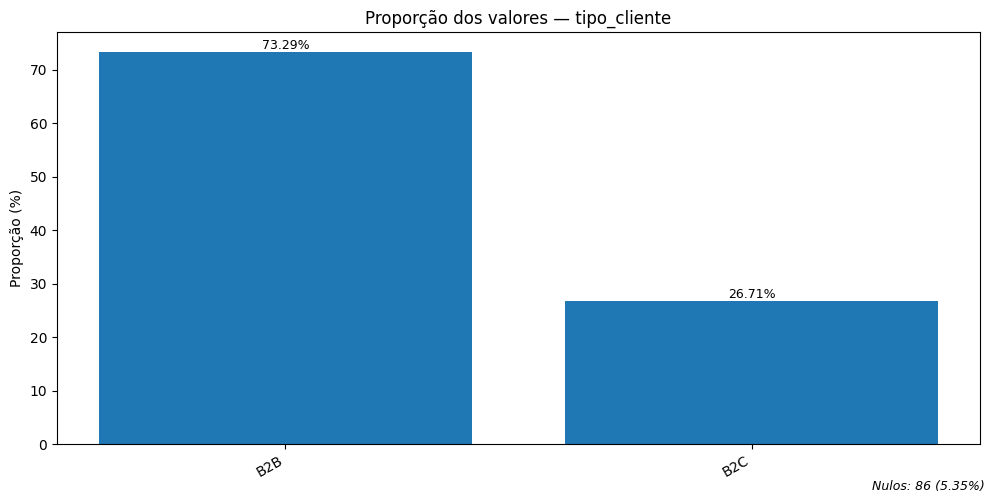

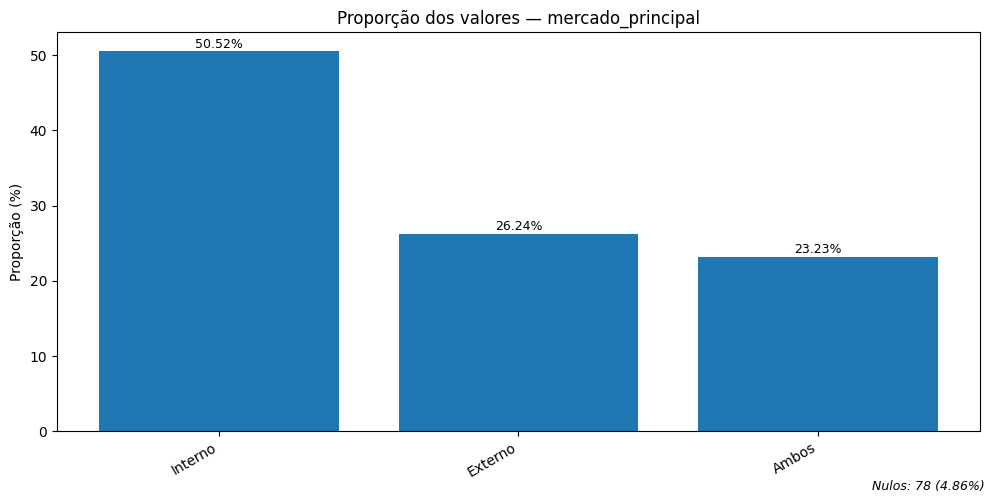

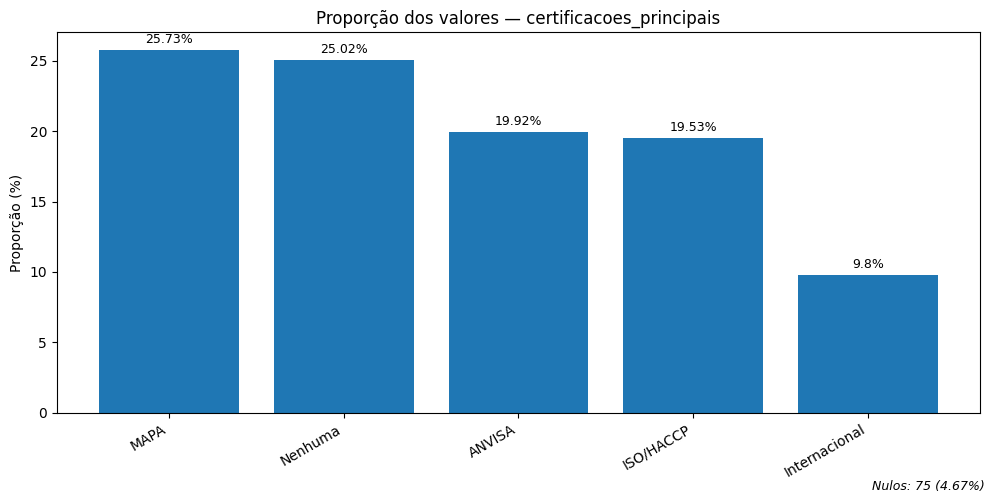

In [9]:
import matplotlib.pyplot as plt

# ================================
# GRÁFICOS DE PROPORÇÃO (%)
# VARIÁVEIS QUALITATIVAS
# ================================

colunas_qualitativas = [
    'tipo_cliente',
    'mercado_principal',
    'certificacoes_principais'
]

for col in colunas_qualitativas:

    # distribuição percentual (ignorando NaN)
    proporcao = (
        df[col]
        .value_counts(normalize=True, dropna=True)
        .mul(100)
        .round(2)
        .sort_values(ascending=False)
    )

    n_na = df[col].isna().sum()
    perc_na = (n_na / len(df)) * 100

    plt.figure(figsize=(10, 5))
    plt.bar(proporcao.index.astype(str), proporcao.values)
    plt.ylabel('Proporção (%)')
    plt.title(f'Proporção dos valores — {col}')

    # rótulos de porcentagem em cima das barras
    for i, v in enumerate(proporcao.values):
        plt.text(i, v + 0.5, f'{v}%', ha='center', fontsize=9)

    # informação de nulos no rodapé
    plt.figtext(
        0.99, 0.01,
        f'Nulos: {n_na} ({perc_na:.2f}%)',
        ha='right',
        fontsize=9,
        style='italic'
    )

    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()


In [10]:
# ================================
# IMPUTAÇÃO QUALITATIVA (SEM "NÃO INFORMADO")
# Estratégia:
# - tipo_cliente -> moda global
# - mercado_principal -> moda por categoria
# - certificacoes_principais -> moda por categoria
# ================================

import numpy as np

# --- (Opcional) conferir nulos antes
cols_check = ['tipo_cliente', 'mercado_principal', 'certificacoes_principais']
print("Nulos ANTES:")
print(df[cols_check].isna().sum())
print()

# -------------------------
# 1) tipo_cliente -> MODA GLOBAL (determinístico)
# -------------------------
col = 'tipo_cliente'
if df[col].isna().any():
    moda_global = df[col].mode(dropna=True)
    if not moda_global.empty:
        df[col] = df[col].fillna(moda_global.iloc[0])

# -------------------------
# 2) mercado_principal -> MODA POR CATEGORIA (determinístico)
# -------------------------
col = 'mercado_principal'
if df[col].isna().any():

    # moda por categoria; em empates, pega a primeira em ordem alfabética (determinístico)
    moda_por_cat = (
        df.dropna(subset=[col])
          .groupby('categoria')[col]
          .agg(lambda s: s.value_counts().index.sort_values()[0] 
               if s.value_counts().max() == s.value_counts().iloc[0] else s.value_counts().idxmax())
    )

    # preenche usando o mapeamento por categoria
    mask = df[col].isna()
    df.loc[mask, col] = df.loc[mask, 'categoria'].map(moda_por_cat)

    # fallback: se alguma categoria não tinha nenhum valor (ficou NaN), usa moda global
    if df[col].isna().any():
        moda_global = df[col].mode(dropna=True)
        if not moda_global.empty:
            df[col] = df[col].fillna(moda_global.iloc[0])

# -------------------------
# 3) certificacoes_principais -> MODA POR CATEGORIA (determinístico)
# -------------------------
col = 'certificacoes_principais'
if df[col].isna().any():

    moda_por_cat = (
        df.dropna(subset=[col])
          .groupby('categoria')[col]
          .agg(lambda s: s.value_counts().index.sort_values()[0] 
               if s.value_counts().max() == s.value_counts().iloc[0] else s.value_counts().idxmax())
    )

    mask = df[col].isna()
    df.loc[mask, col] = df.loc[mask, 'categoria'].map(moda_por_cat)

    # fallback: se alguma categoria não tinha nenhum valor, usa moda global
    if df[col].isna().any():
        moda_global = df[col].mode(dropna=True)
        if not moda_global.empty:
            df[col] = df[col].fillna(moda_global.iloc[0])

# --- conferir nulos depois
print("Nulos DEPOIS:")
print(df[cols_check].isna().sum())


Nulos ANTES:
tipo_cliente                86
mercado_principal           78
certificacoes_principais    75
dtype: int64

Nulos DEPOIS:
tipo_cliente                0
mercado_principal           0
certificacoes_principais    0
dtype: int64


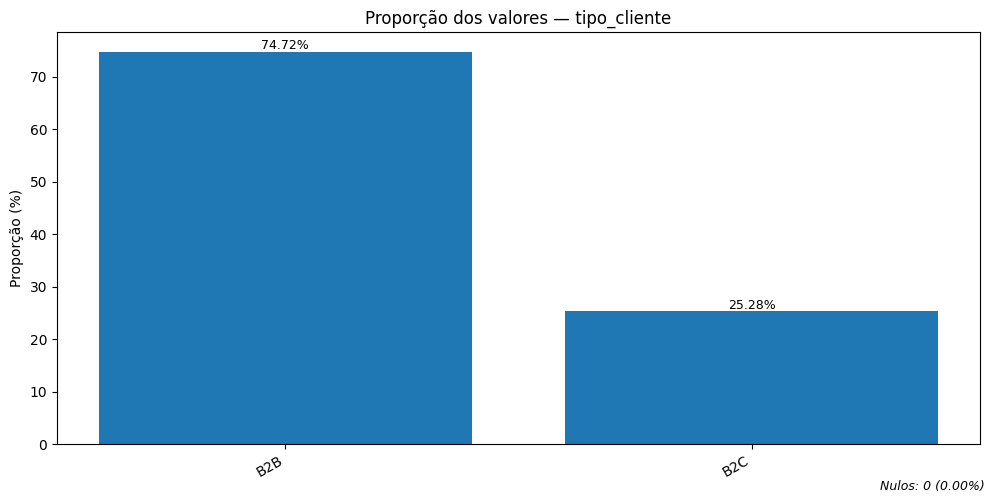

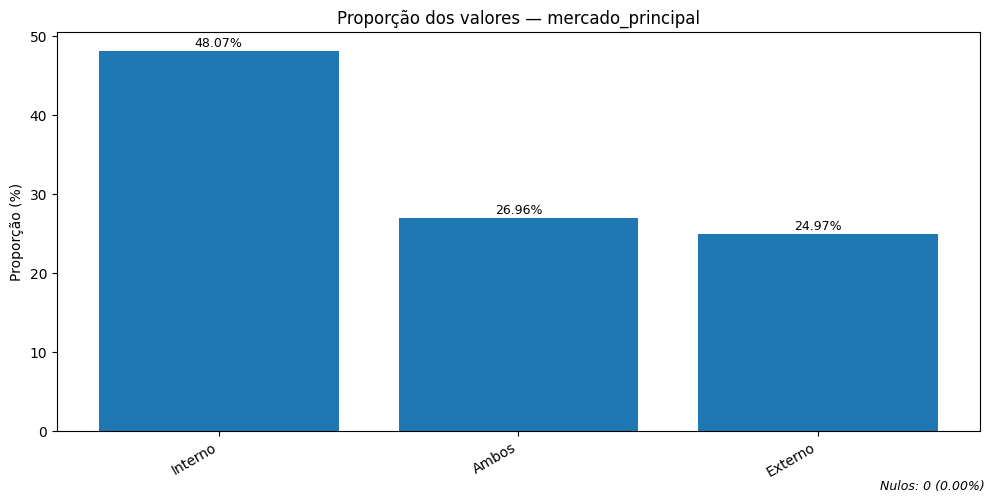

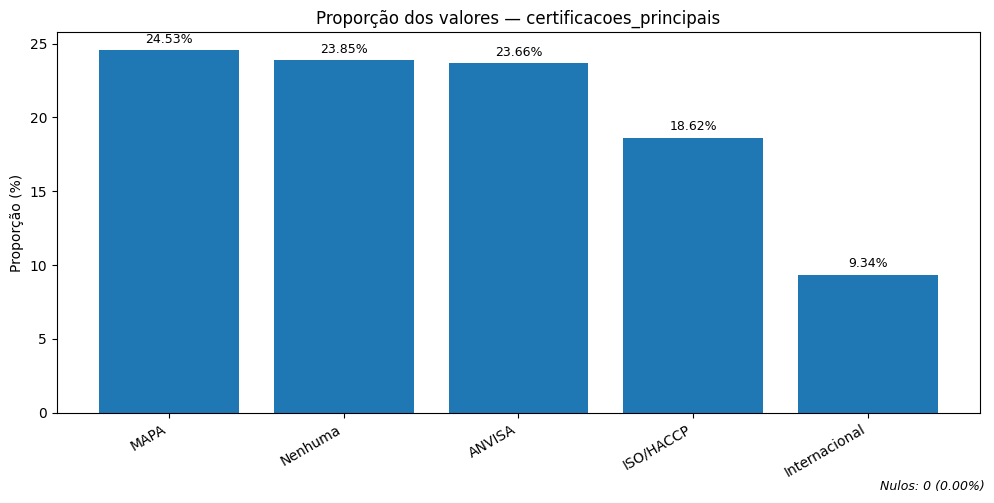

In [11]:
import matplotlib.pyplot as plt

# ================================
# GRÁFICOS DE PROPORÇÃO (%)
# VARIÁVEIS QUALITATIVAS
# ================================

colunas_qualitativas = [
    'tipo_cliente',
    'mercado_principal',
    'certificacoes_principais'
]

for col in colunas_qualitativas:

    # distribuição percentual (ignorando NaN)
    proporcao = (
        df[col]
        .value_counts(normalize=True, dropna=True)
        .mul(100)
        .round(2)
        .sort_values(ascending=False)
    )

    n_na = df[col].isna().sum()
    perc_na = (n_na / len(df)) * 100

    plt.figure(figsize=(10, 5))
    plt.bar(proporcao.index.astype(str), proporcao.values)
    plt.ylabel('Proporção (%)')
    plt.title(f'Proporção dos valores — {col}')

    # rótulos de porcentagem em cima das barras
    for i, v in enumerate(proporcao.values):
        plt.text(i, v + 0.5, f'{v}%', ha='center', fontsize=9)

    # informação de nulos no rodapé
    plt.figtext(
        0.99, 0.01,
        f'Nulos: {n_na} ({perc_na:.2f}%)',
        ha='right',
        fontsize=9,
        style='italic'
    )

    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()


In [12]:
df['empresa'] = df['empresa'].fillna('Desconhecido')
df.isnull().sum()

empresa                                        0
faturamento_empresa_brl                        0
produto                                        0
tipo_cliente                                   0
mercado_principal                              0
indice_concorrencia_1a5                        0
indice_valor_agregado_1a5                      0
margem_media_percentual                        0
indice_complexidade_produtiva_1a5              0
indice_capex_1a5                               0
indice_escalabilidade_1a5                      0
indice_exigencia_regulatoria_1a5               0
certificacoes_principais                       0
indice_compatibilidade_refugo_1a5              0
indice_compatibilidade_operacao_fazenda_1a5    0
categoria                                      0
dtype: int64


MÉDIAS POR CATEGORIA

                                              indice_concorrencia_1a5  \
categoria                                                               
Ingredientes Alimentícios & Funcionais (B2B)                     2.97   
Alimentos & Bebidas (Produto Final)                              2.94   
Cosméticos, Higiene & Perfumaria                                 3.08   
Sustentabilidade, Energia & Bioinsumos                           3.09   
Nutrição Animal & Agro                                           2.89   

                                              indice_valor_agregado_1a5  \
categoria                                                                 
Ingredientes Alimentícios & Funcionais (B2B)                       2.86   
Alimentos & Bebidas (Produto Final)                                2.94   
Cosméticos, Higiene & Perfumaria                                   2.94   
Sustentabilidade, Energia & Bioinsumos                             2.85   
Nutrição Animal

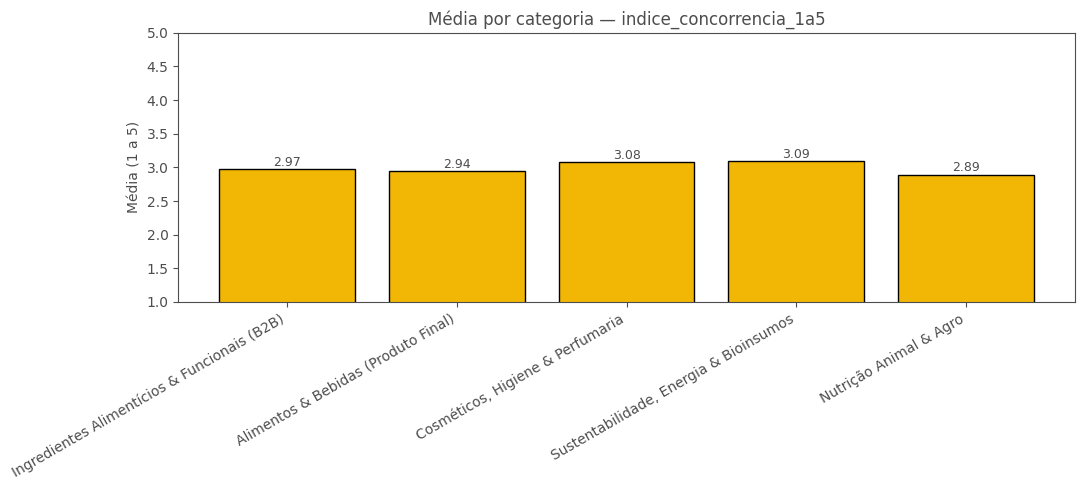

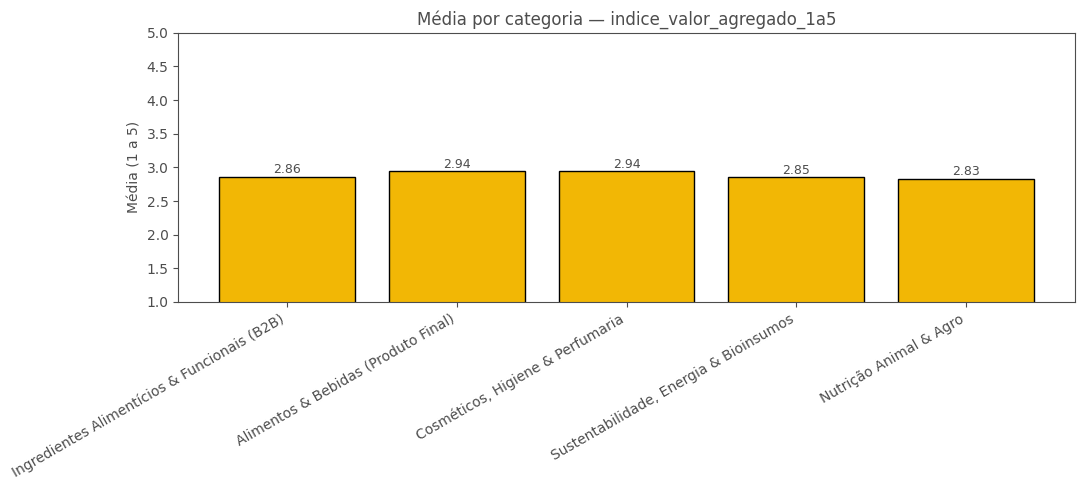

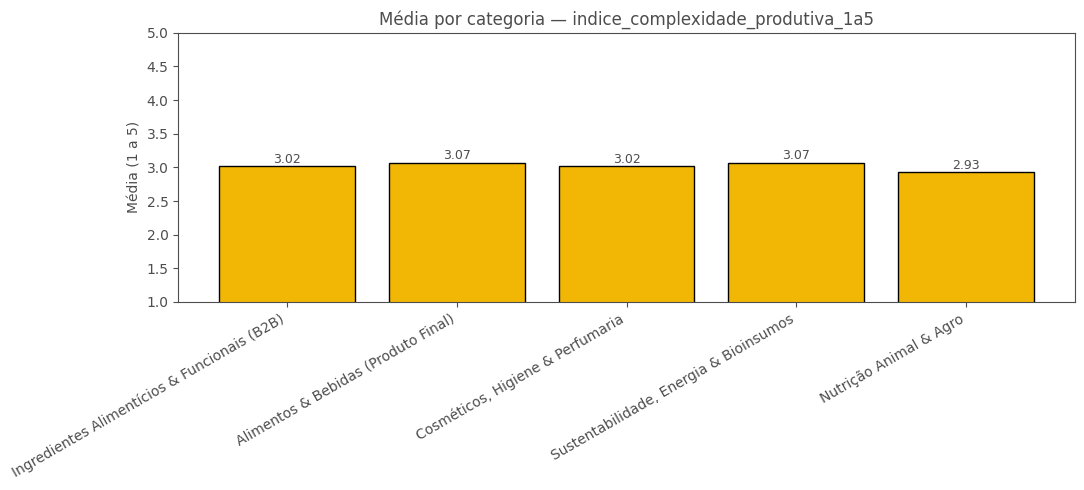

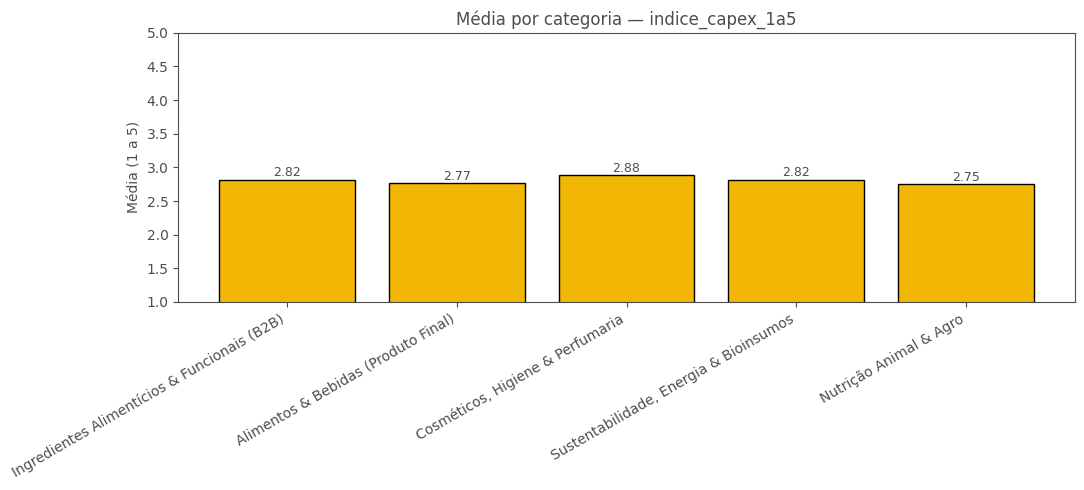

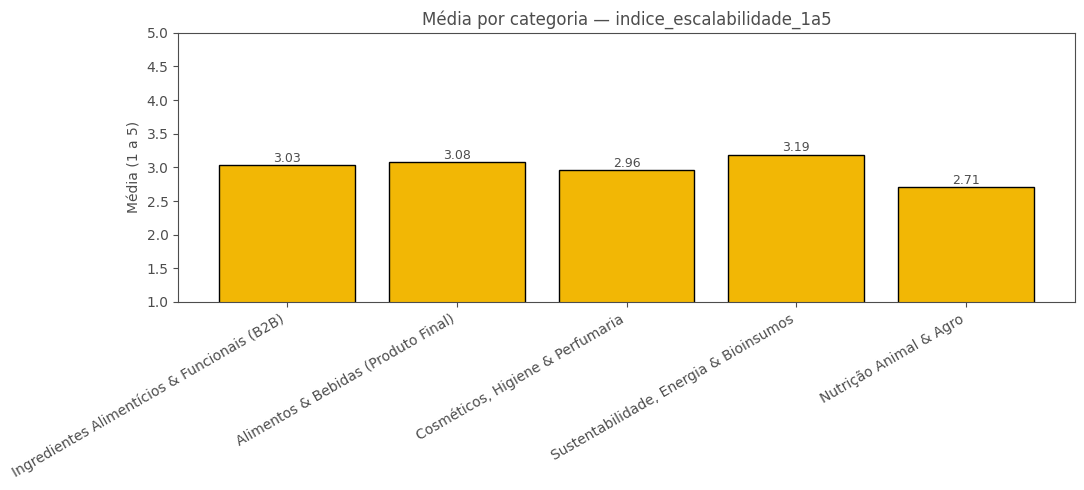

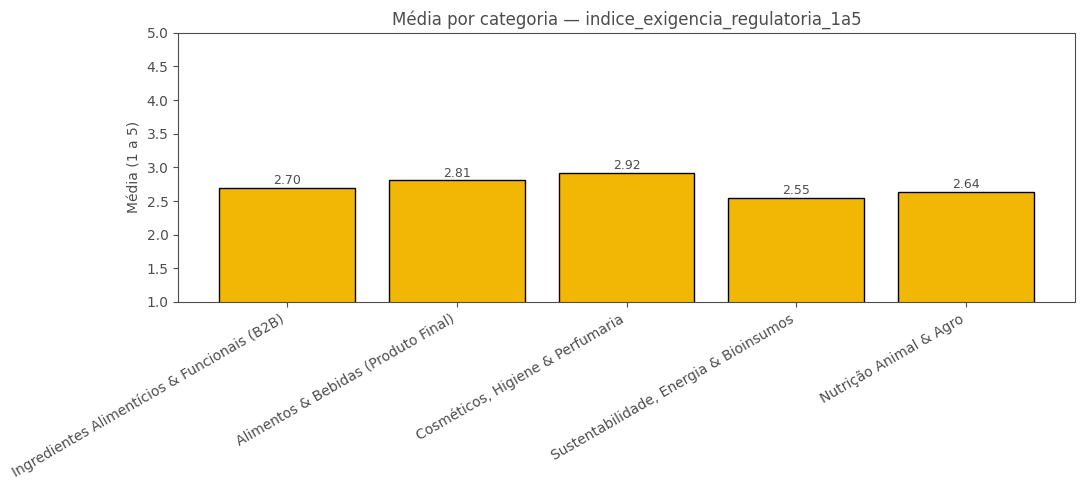

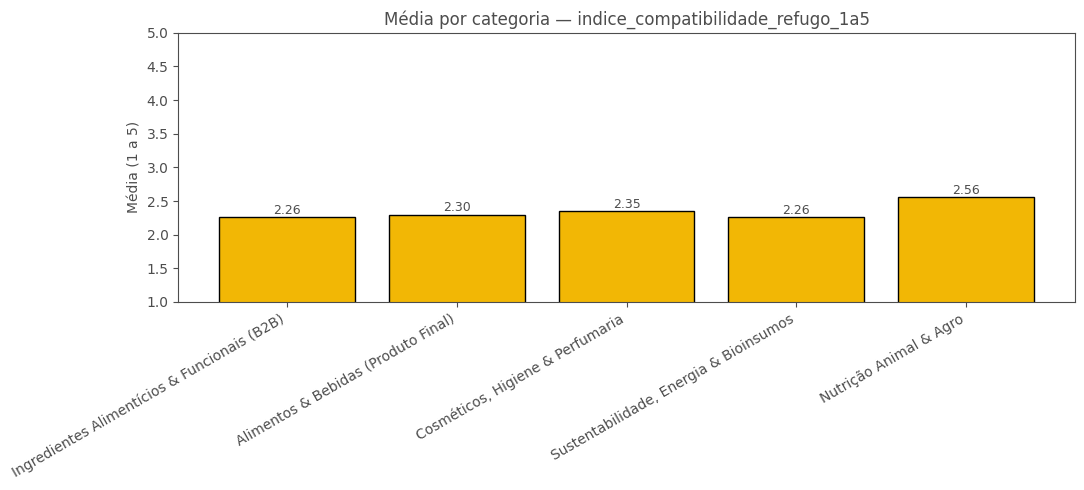

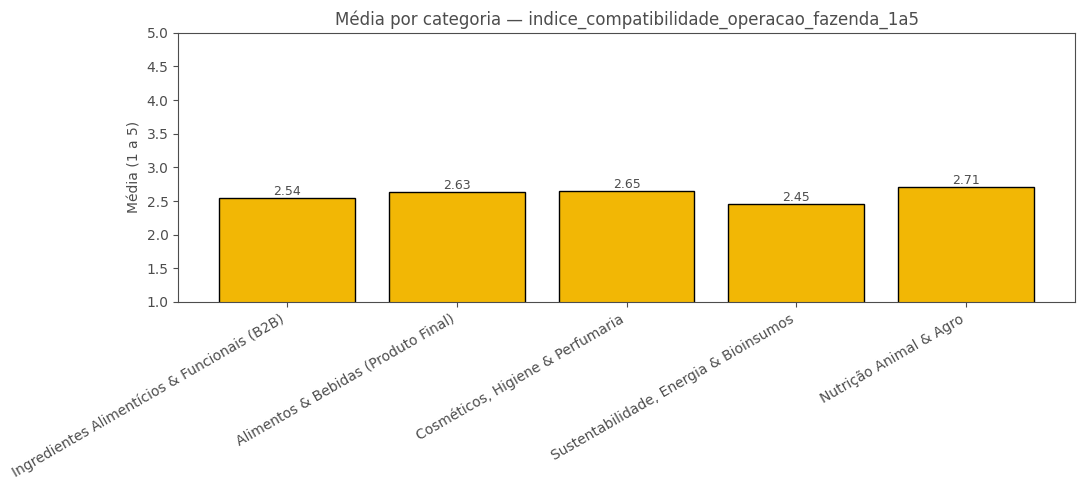

C:\Users\joaop\AppData\Local\Temp\ipykernel_40616\1595630532.py:93: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


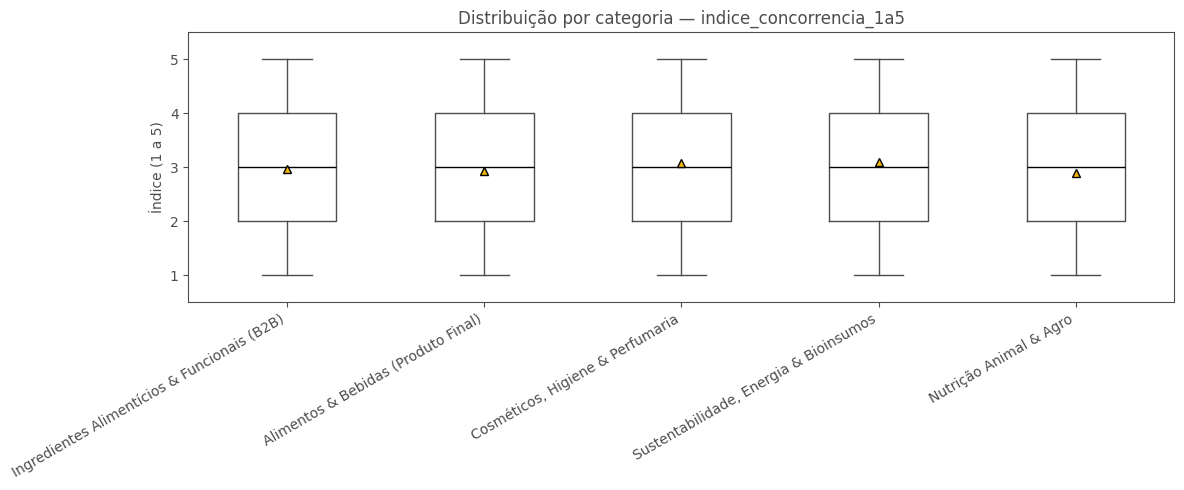

C:\Users\joaop\AppData\Local\Temp\ipykernel_40616\1595630532.py:93: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


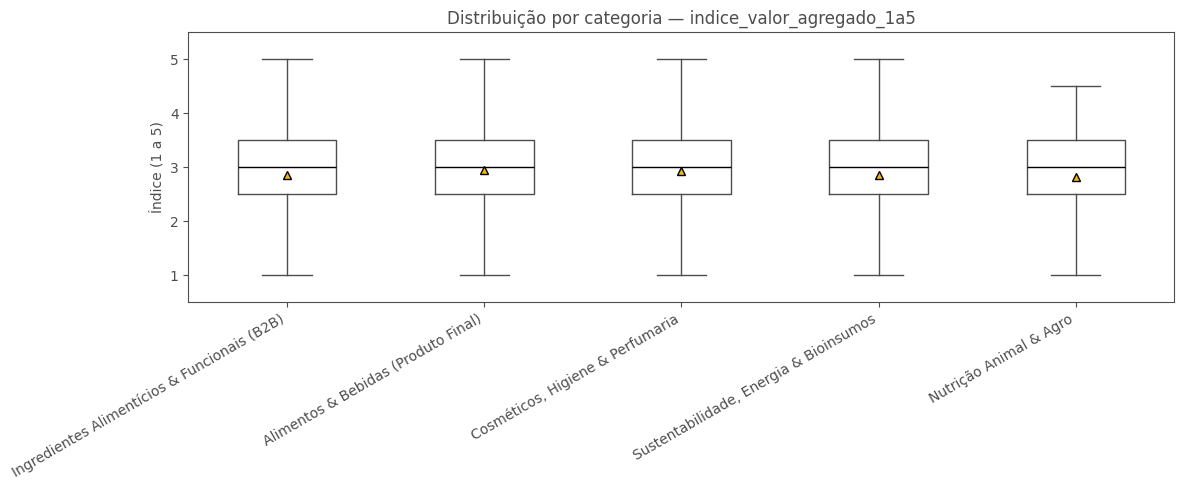

C:\Users\joaop\AppData\Local\Temp\ipykernel_40616\1595630532.py:93: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


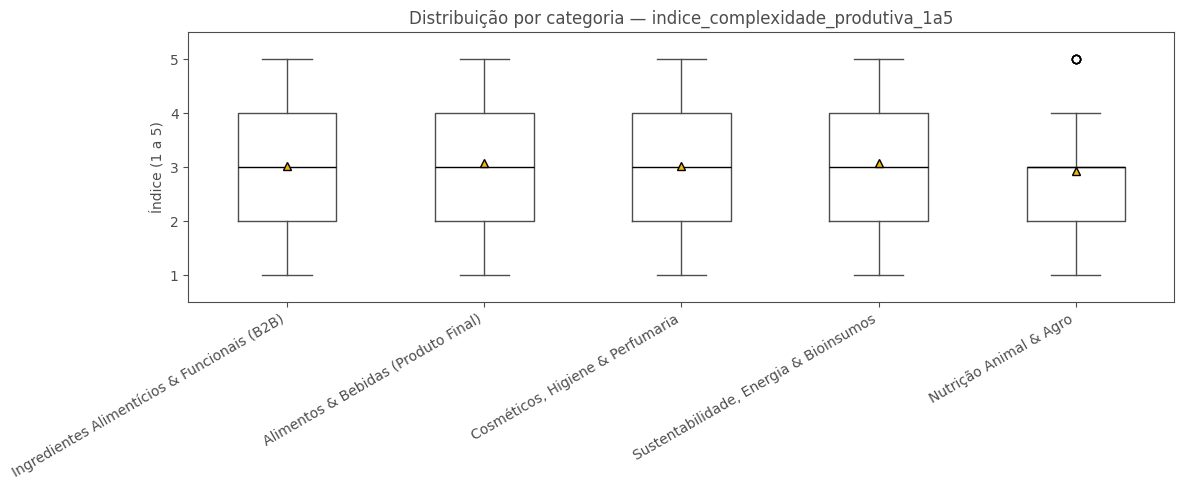

C:\Users\joaop\AppData\Local\Temp\ipykernel_40616\1595630532.py:93: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


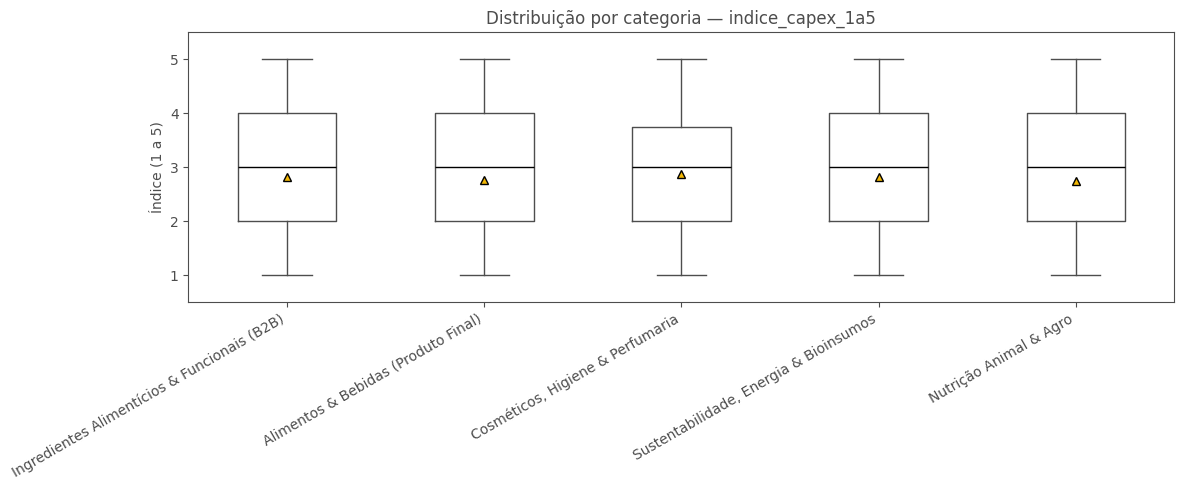

C:\Users\joaop\AppData\Local\Temp\ipykernel_40616\1595630532.py:93: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


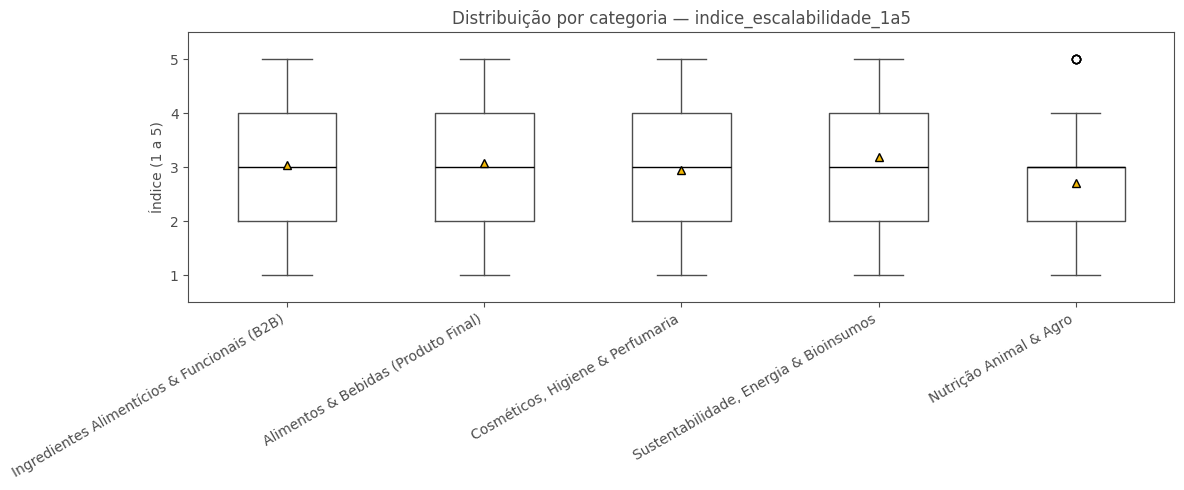

C:\Users\joaop\AppData\Local\Temp\ipykernel_40616\1595630532.py:93: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


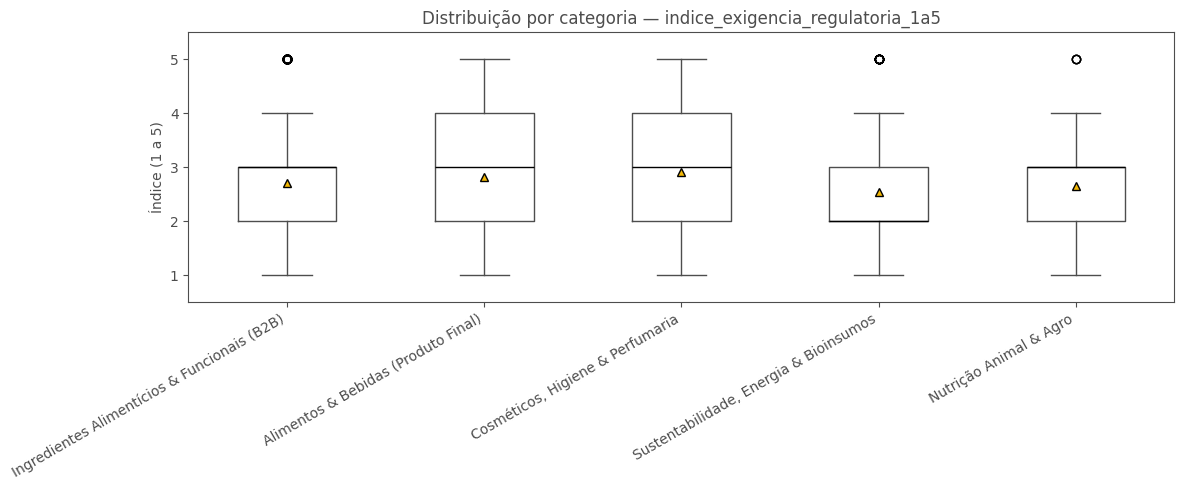

C:\Users\joaop\AppData\Local\Temp\ipykernel_40616\1595630532.py:93: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


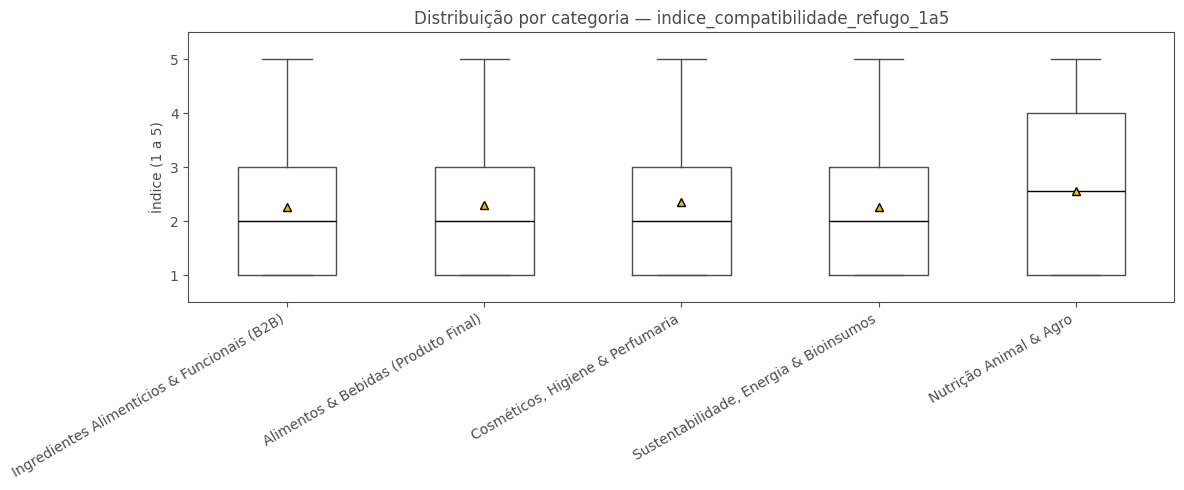

C:\Users\joaop\AppData\Local\Temp\ipykernel_40616\1595630532.py:93: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


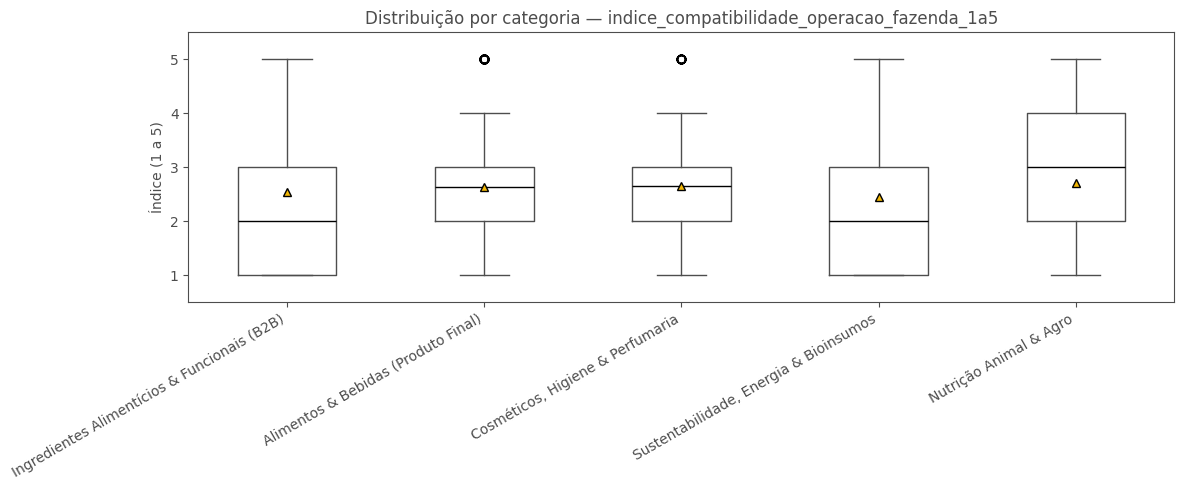


CORRELAÇÃO ENTRE ÍNDICES

                                             indice_concorrencia_1a5  \
indice_concorrencia_1a5                                         1.00   
indice_valor_agregado_1a5                                       0.00   
indice_complexidade_produtiva_1a5                              -0.00   
indice_capex_1a5                                               -0.02   
indice_escalabilidade_1a5                                       0.00   
indice_exigencia_regulatoria_1a5                                0.01   
indice_compatibilidade_refugo_1a5                              -0.01   
indice_compatibilidade_operacao_fazenda_1a5                     0.01   

                                             indice_valor_agregado_1a5  \
indice_concorrencia_1a5                                           0.00   
indice_valor_agregado_1a5                                         1.00   
indice_complexidade_produtiva_1a5                                 0.65   
indice_capex_1a5            

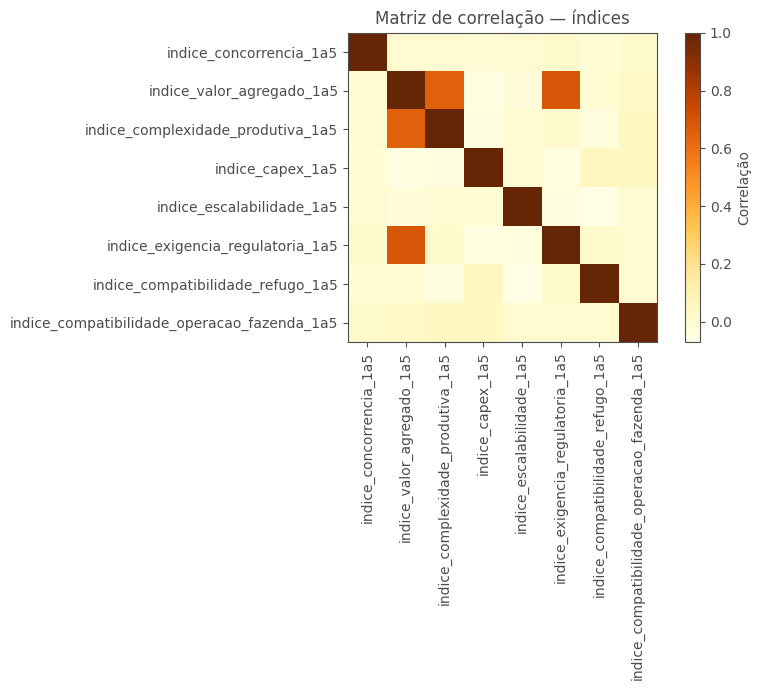

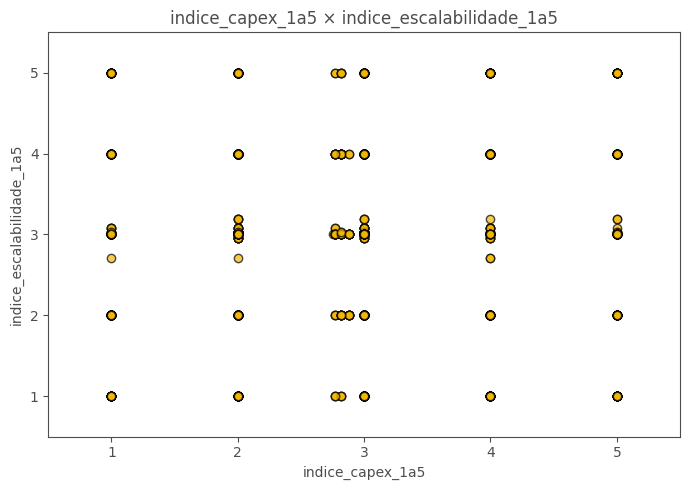

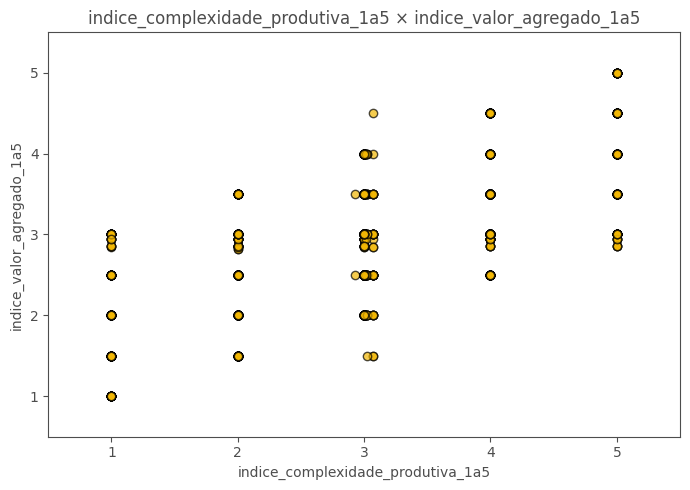

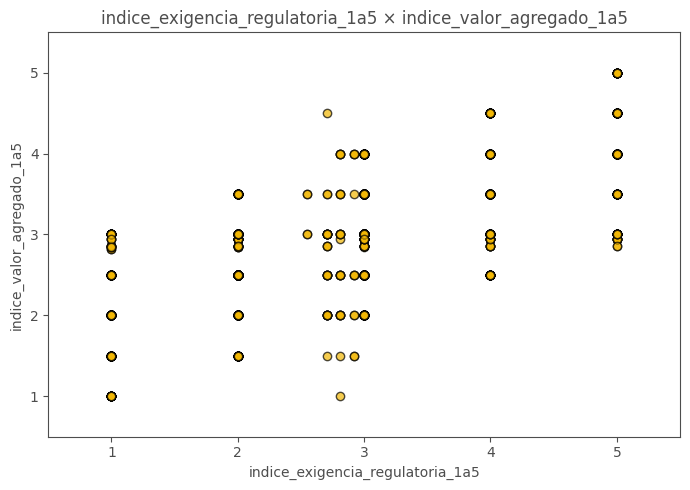


Distribuição (%) — tipo_cliente

tipo_cliente                                    B2B    B2C
categoria                                                 
Ingredientes Alimentícios & Funcionais (B2B)  74.03  25.97
Alimentos & Bebidas (Produto Final)           75.91  24.09
Cosméticos, Higiene & Perfumaria              75.19  24.81
Sustentabilidade, Energia & Bioinsumos        74.68  25.32
Nutrição Animal & Agro                        66.67  33.33


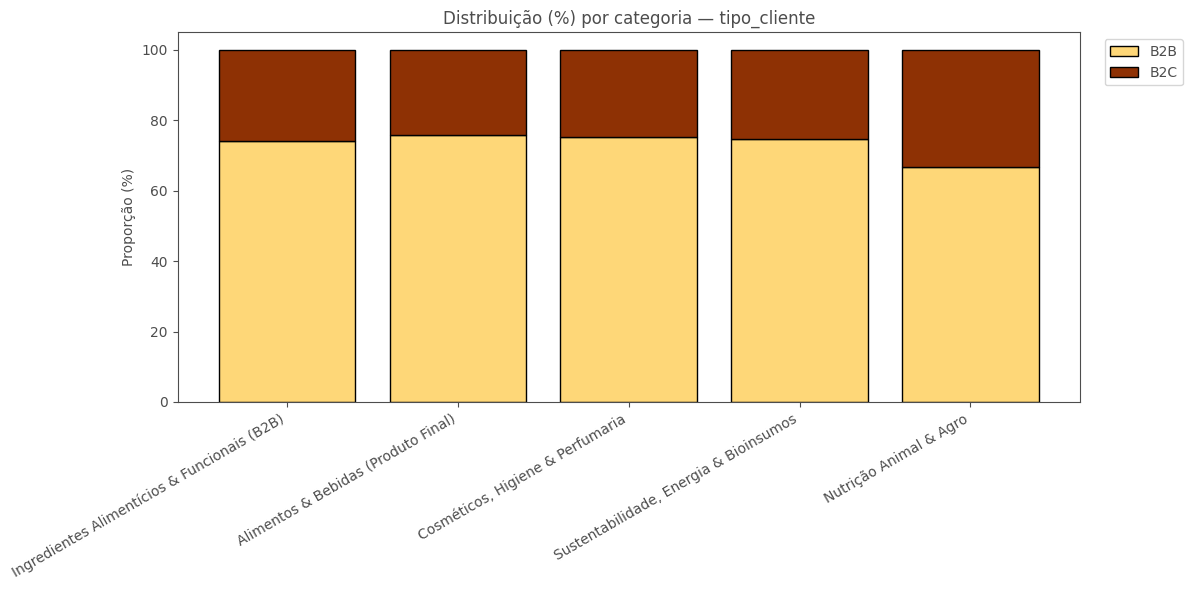


Distribuição (%) — mercado_principal

mercado_principal                             Ambos  Externo  Interno
categoria                                                            
Ingredientes Alimentícios & Funcionais (B2B)  26.81    22.77    50.42
Alimentos & Bebidas (Produto Final)           24.82    25.91    49.27
Cosméticos, Higiene & Perfumaria              32.33    25.56    42.11
Sustentabilidade, Energia & Bioinsumos        25.97    26.62    47.40
Nutrição Animal & Agro                        26.67    33.33    40.00


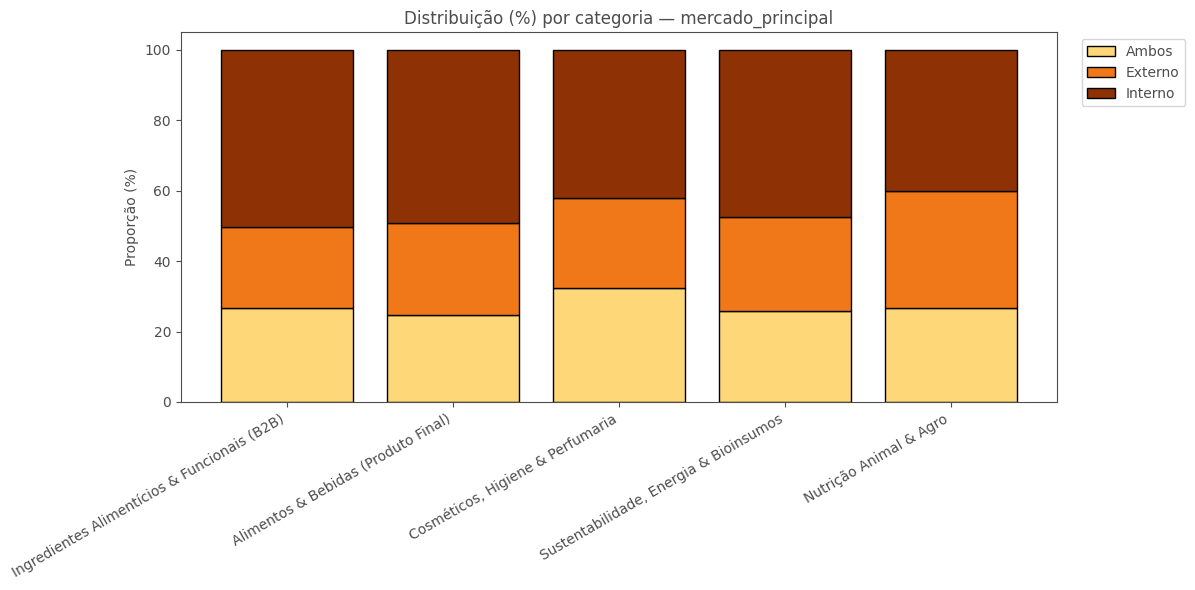


Distribuição (%) — certificacoes_principais

certificacoes_principais                      ANVISA  ISO/HACCP  \
categoria                                                         
Ingredientes Alimentícios & Funcionais (B2B)   23.61      16.53   
Alimentos & Bebidas (Produto Final)            23.18      18.80   
Cosméticos, Higiene & Perfumaria               22.56      23.31   
Sustentabilidade, Energia & Bioinsumos         26.62      17.53   
Nutrição Animal & Agro                         26.67      20.00   

certificacoes_principais                      Internacional   MAPA  Nenhuma  
categoria                                                                    
Ingredientes Alimentícios & Funcionais (B2B)          10.12  24.45    25.30  
Alimentos & Bebidas (Produto Final)                    8.94  24.27    24.82  
Cosméticos, Higiene & Perfumaria                       9.40  25.56    19.17  
Sustentabilidade, Energia & Bioinsumos                 7.14  25.97    22.73  
Nutrição Animal 

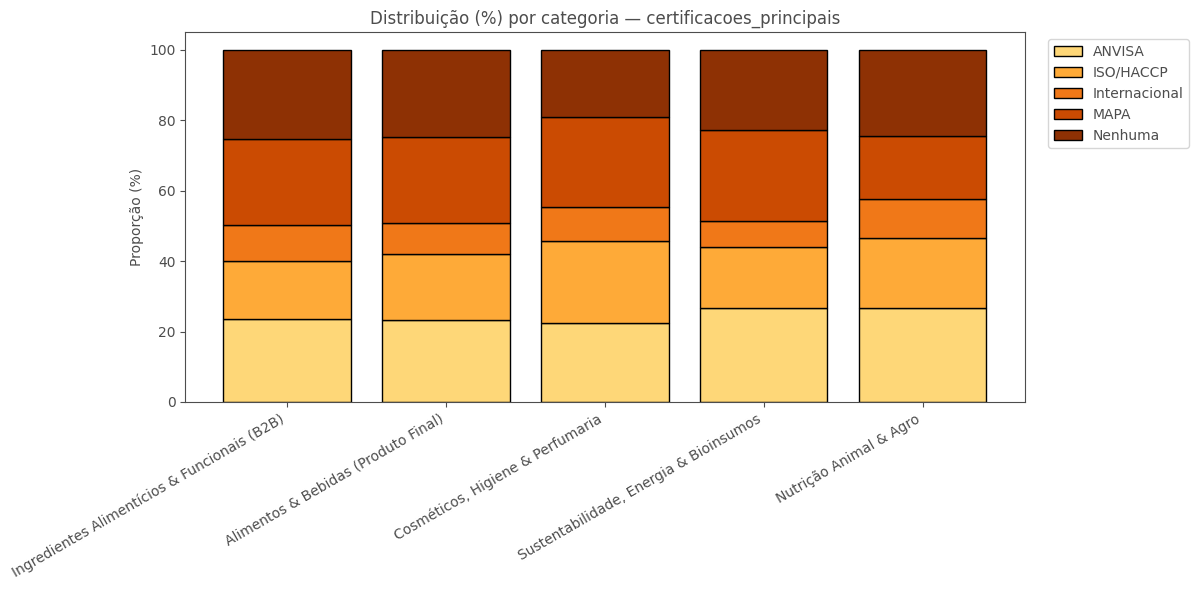

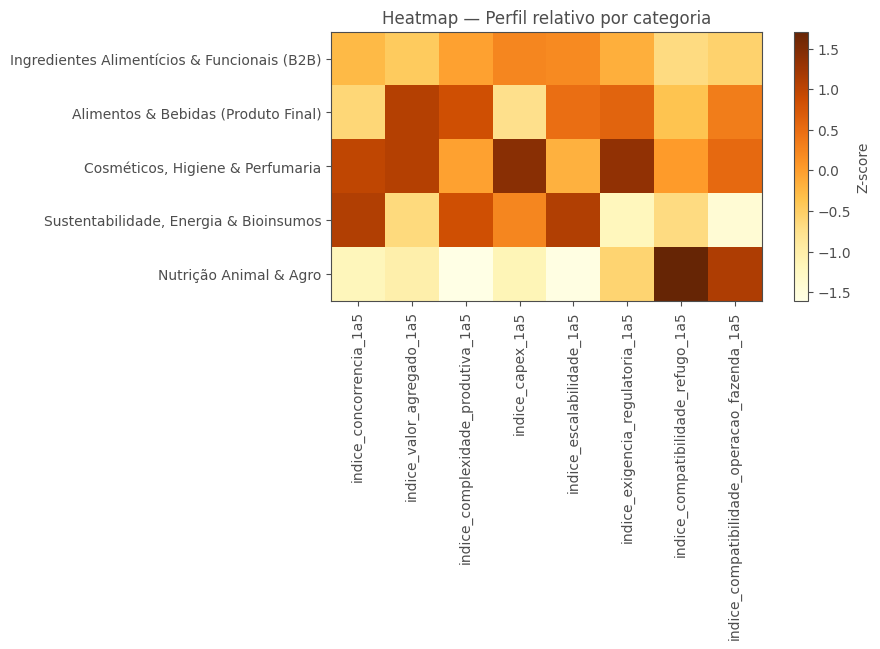

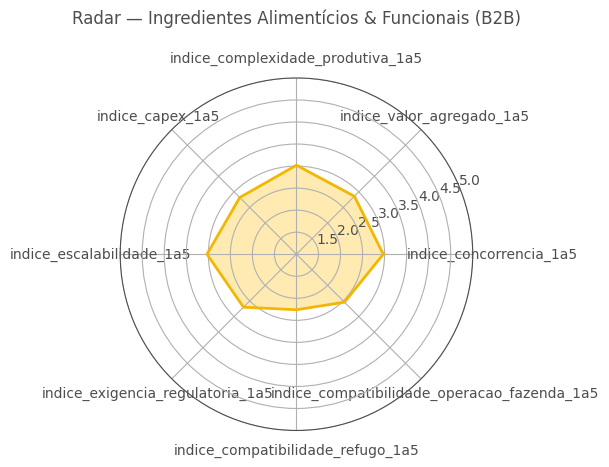

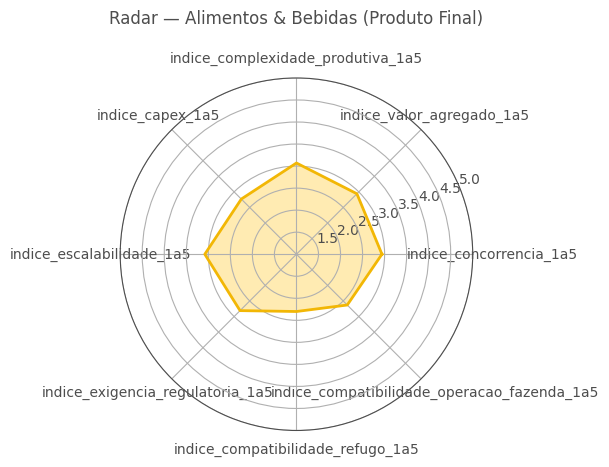

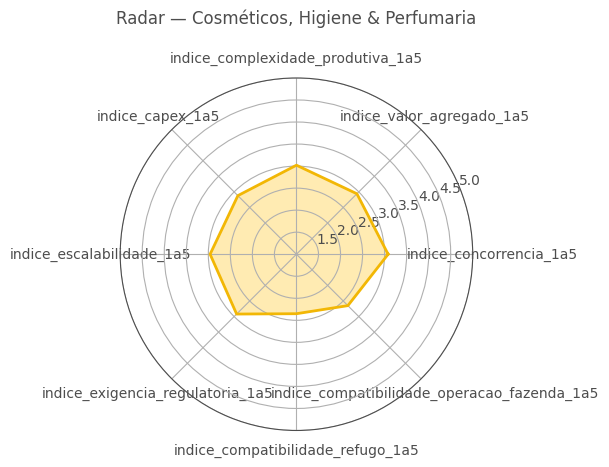

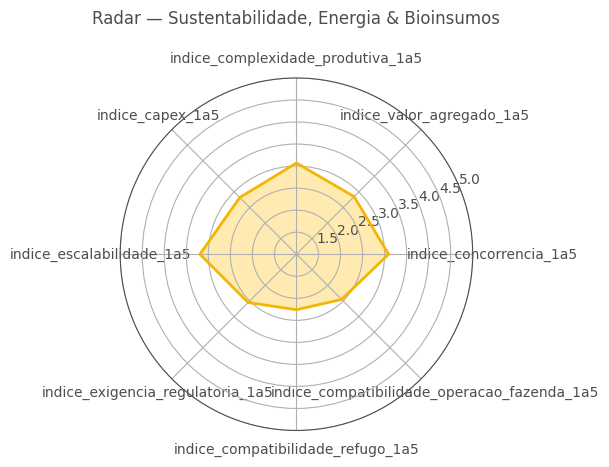

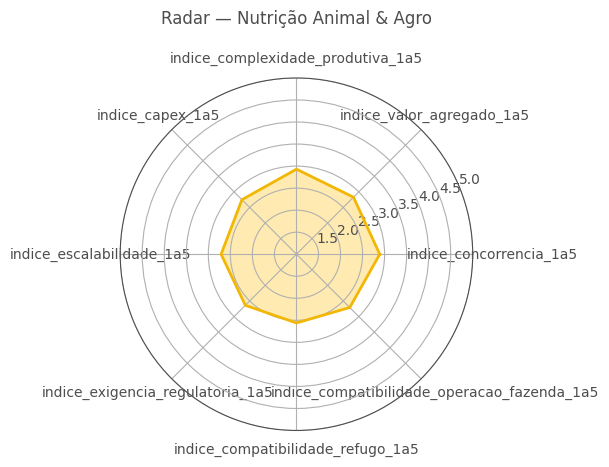

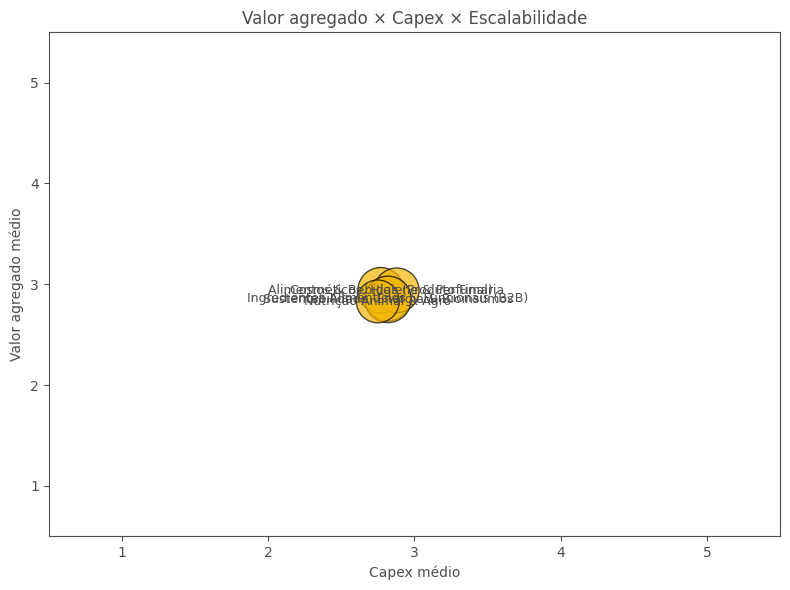


✅ Análise bivariada final pronta para slides.


In [13]:
# ============================================================
# ANÁLISE BIVARIADA — VERSÃO FINAL (PALETA DO SLIDE)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# PALETA (slide Citrosuco)
# =========================
COLOR_PRIMARY = '#F2B705'   # dourado
COLOR_LIGHT   = '#FFD966'   # amarelo claro
COLOR_DARK    = '#4D4D4D'   # cinza escuro
COLOR_GRAY    = '#BFBFBF'   # cinza claro
COLOR_BLACK   = '#000000'

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = COLOR_DARK
plt.rcParams['axes.labelcolor'] = COLOR_DARK
plt.rcParams['xtick.color'] = COLOR_DARK
plt.rcParams['ytick.color'] = COLOR_DARK
plt.rcParams['text.color'] = COLOR_DARK

# =========================
# CONFIG
# =========================
col_categoria = 'categoria'

indices = [
    'indice_concorrencia_1a5',
    'indice_valor_agregado_1a5',
    'indice_complexidade_produtiva_1a5',
    'indice_capex_1a5',
    'indice_escalabilidade_1a5',
    'indice_exigencia_regulatoria_1a5',
    'indice_compatibilidade_refugo_1a5',
    'indice_compatibilidade_operacao_fazenda_1a5'
]

qualitativas = [
    'tipo_cliente',
    'mercado_principal',
    'certificacoes_principais'
]

ordem_categorias = (
    df[col_categoria]
    .value_counts()
    .index
    .tolist()
)

# ============================================================
# 1) MÉDIAS POR CATEGORIA
# ============================================================
medias = (
    df.groupby(col_categoria)[indices]
      .mean()
      .reindex(ordem_categorias)
      .round(2)
)

print("\nMÉDIAS POR CATEGORIA\n")
print(medias)

# ============================================================
# 1A) BARRAS — MÉDIA POR CATEGORIA
# ============================================================
for col in indices:
    vals = medias[col]

    plt.figure(figsize=(11, 5))
    plt.bar(vals.index, vals.values, color=COLOR_PRIMARY, edgecolor=COLOR_BLACK)
    plt.title(f"Média por categoria — {col}")
    plt.ylabel("Média (1 a 5)")
    plt.xticks(rotation=30, ha='right')
    plt.ylim(1, 5)

    for i, v in enumerate(vals.values):
        plt.text(i, v + 0.05, f"{v:.2f}", ha='center', fontsize=9)

    plt.tight_layout()
    plt.show()

# ============================================================
# 1B) BOXPLOTS — DISTRIBUIÇÃO
# ============================================================
for col in indices:
    grupos = [df.loc[df[col_categoria] == cat, col].dropna() for cat in ordem_categorias]

    plt.figure(figsize=(12, 5))
    plt.boxplot(
        grupos,
        labels=ordem_categorias,
        showmeans=True,
        meanprops=dict(marker='^', markerfacecolor=COLOR_PRIMARY, markeredgecolor=COLOR_BLACK),
        boxprops=dict(color=COLOR_DARK),
        medianprops=dict(color=COLOR_BLACK),
        whiskerprops=dict(color=COLOR_DARK),
        capprops=dict(color=COLOR_DARK)
    )

    plt.title(f"Distribuição por categoria — {col}")
    plt.ylabel("Índice (1 a 5)")
    plt.xticks(rotation=30, ha='right')
    plt.ylim(0.5, 5.5)
    plt.tight_layout()
    plt.show()

# ============================================================
# 2) MATRIZ DE CORRELAÇÃO
# ============================================================
corr = df[indices].corr().round(2)
print("\nCORRELAÇÃO ENTRE ÍNDICES\n")
print(corr)

plt.figure(figsize=(9, 7))
plt.imshow(corr.values, cmap='YlOrBr')
plt.colorbar(label='Correlação')
plt.xticks(range(len(indices)), indices, rotation=90)
plt.yticks(range(len(indices)), indices)
plt.title("Matriz de correlação — índices")
plt.tight_layout()
plt.show()

# ============================================================
# 2A) SCATTERS (TRADE-OFFS)
# ============================================================
pares = [
    ('indice_capex_1a5', 'indice_escalabilidade_1a5'),
    ('indice_complexidade_produtiva_1a5', 'indice_valor_agregado_1a5'),
    ('indice_exigencia_regulatoria_1a5', 'indice_valor_agregado_1a5')
]

for x, y in pares:
    plt.figure(figsize=(7, 5))
    plt.scatter(df[x], df[y], color=COLOR_PRIMARY, edgecolor=COLOR_BLACK, alpha=0.7)
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(f"{x} × {y}")
    plt.xlim(0.5, 5.5)
    plt.ylim(0.5, 5.5)
    plt.tight_layout()
    plt.show()

# ============================================================
# 3) QUALITATIVAS — BARRAS EMPILHADAS (%)
# ============================================================
for col in qualitativas:
    tab = (
        pd.crosstab(df[col_categoria], df[col])
          .reindex(ordem_categorias)
    )

    tab_pct = (tab.div(tab.sum(axis=1), axis=0) * 100).round(2)
    print(f"\nDistribuição (%) — {col}\n")
    print(tab_pct)

    plt.figure(figsize=(12, 6))
    bottom = np.zeros(len(tab_pct))

    colors = plt.cm.YlOrBr(np.linspace(0.3, 0.9, len(tab_pct.columns)))

    for i, v in enumerate(tab_pct.columns):
        plt.bar(
            tab_pct.index,
            tab_pct[v],
            bottom=bottom,
            label=v,
            color=colors[i],
            edgecolor=COLOR_BLACK
        )
        bottom += tab_pct[v].values

    plt.title(f"Distribuição (%) por categoria — {col}")
    plt.ylabel("Proporção (%)")
    plt.xticks(rotation=30, ha='right')
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# ============================================================
# 4) HEATMAP DE PERFIL (Z-SCORE)
# ============================================================
zscore = (medias - medias.mean()) / medias.std()

plt.figure(figsize=(10, 6))
plt.imshow(zscore.values, cmap='YlOrBr')
plt.colorbar(label='Z-score')
plt.xticks(range(len(indices)), indices, rotation=90)
plt.yticks(range(len(zscore.index)), zscore.index)
plt.title("Heatmap — Perfil relativo por categoria")
plt.tight_layout()
plt.show()

# ============================================================
# 5) RADAR CHART (1 POR CATEGORIA)
# ============================================================
labels = indices
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

for categoria in medias.index:
    values = medias.loc[categoria].tolist()
    values += values[:1]

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
    ax.plot(angles, values, color=COLOR_PRIMARY, linewidth=2)
    ax.fill(angles, values, color=COLOR_LIGHT, alpha=0.5)
    ax.set_thetagrids(np.degrees(angles[:-1]), labels)
    ax.set_ylim(1, 5)
    ax.set_title(f"Radar — {categoria}", pad=20)
    plt.tight_layout()
    plt.show()

# ============================================================
# 6) BUBBLE CHART — VALOR × CAPEX × ESCALABILIDADE
# ============================================================
bubble = medias.reset_index()

plt.figure(figsize=(8, 6))
plt.scatter(
    bubble['indice_capex_1a5'],
    bubble['indice_valor_agregado_1a5'],
    s=bubble['indice_escalabilidade_1a5'] * 350,
    color=COLOR_PRIMARY,
    edgecolor=COLOR_BLACK,
    alpha=0.7
)

for i, cat in enumerate(bubble[col_categoria]):
    plt.text(
        bubble['indice_capex_1a5'][i],
        bubble['indice_valor_agregado_1a5'][i],
        cat,
        fontsize=9,
        ha='center',
        va='center'
    )

plt.xlabel("Capex médio")
plt.ylabel("Valor agregado médio")
plt.title("Valor agregado × Capex × Escalabilidade")
plt.xlim(0.5, 5.5)
plt.ylim(0.5, 5.5)
plt.tight_layout()
plt.show()

print("\n✅ Análise bivariada final pronta para slides.")



ANÁLISE INDIVIDUAL — Polpa congelada
Registros encontrados: 60 (3.74% do dataset)

--- Nulos no recorte (top 12 colunas) ---
produto                                        0
categoria                                      0
indice_concorrencia_1a5                        0
indice_valor_agregado_1a5                      0
indice_complexidade_produtiva_1a5              0
indice_capex_1a5                               0
indice_escalabilidade_1a5                      0
indice_exigencia_regulatoria_1a5               0
indice_compatibilidade_refugo_1a5              0
indice_compatibilidade_operacao_fazenda_1a5    0
tipo_cliente                                   0
mercado_principal                              0
dtype: int64

--- Estatísticas dos índices (recorte) ---
                                             count  mean  median   std  min  \
indice_concorrencia_1a5                       60.0  2.63    2.50  1.04  1.0   
indice_valor_agregado_1a5                     60.0  2.73    2.50  0.71 

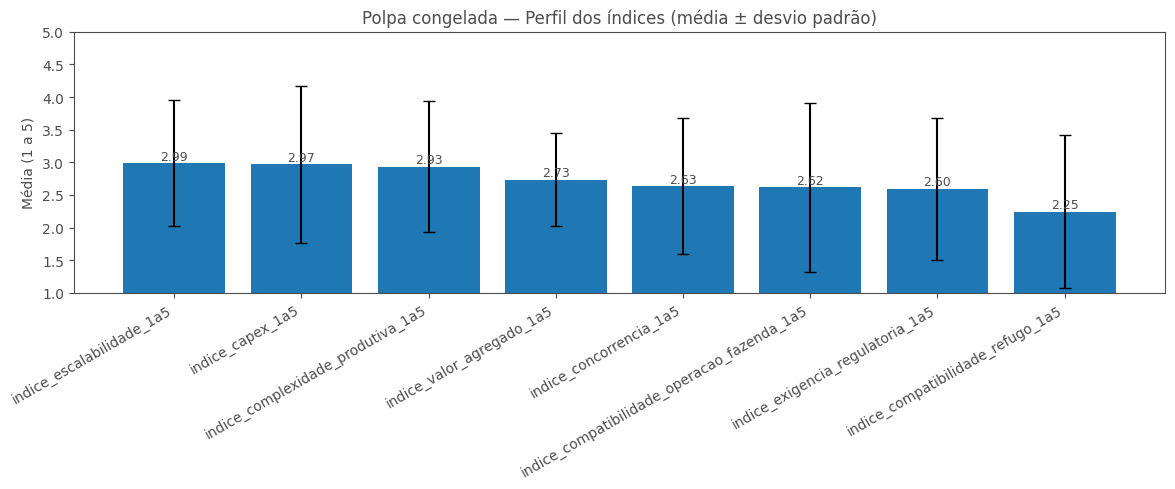

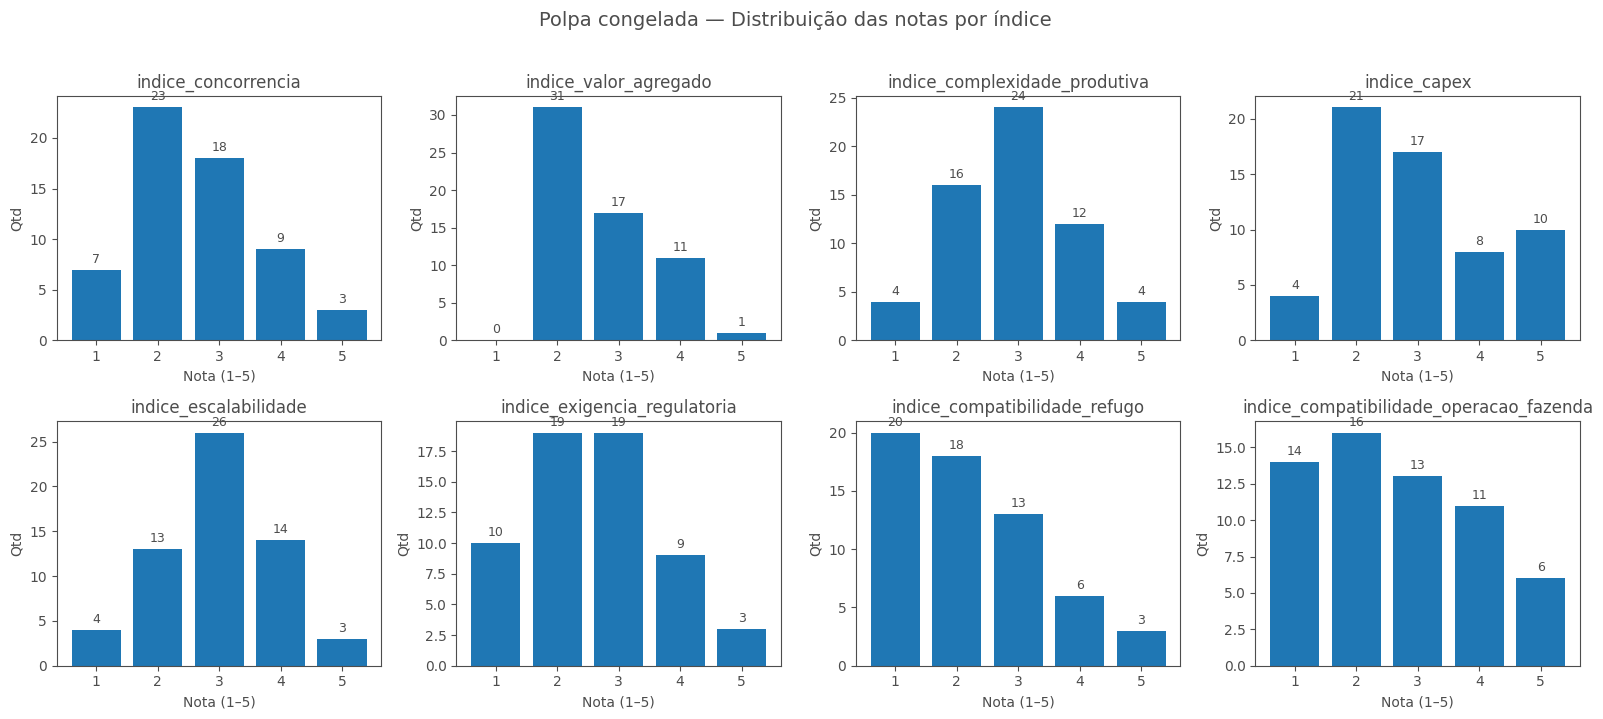

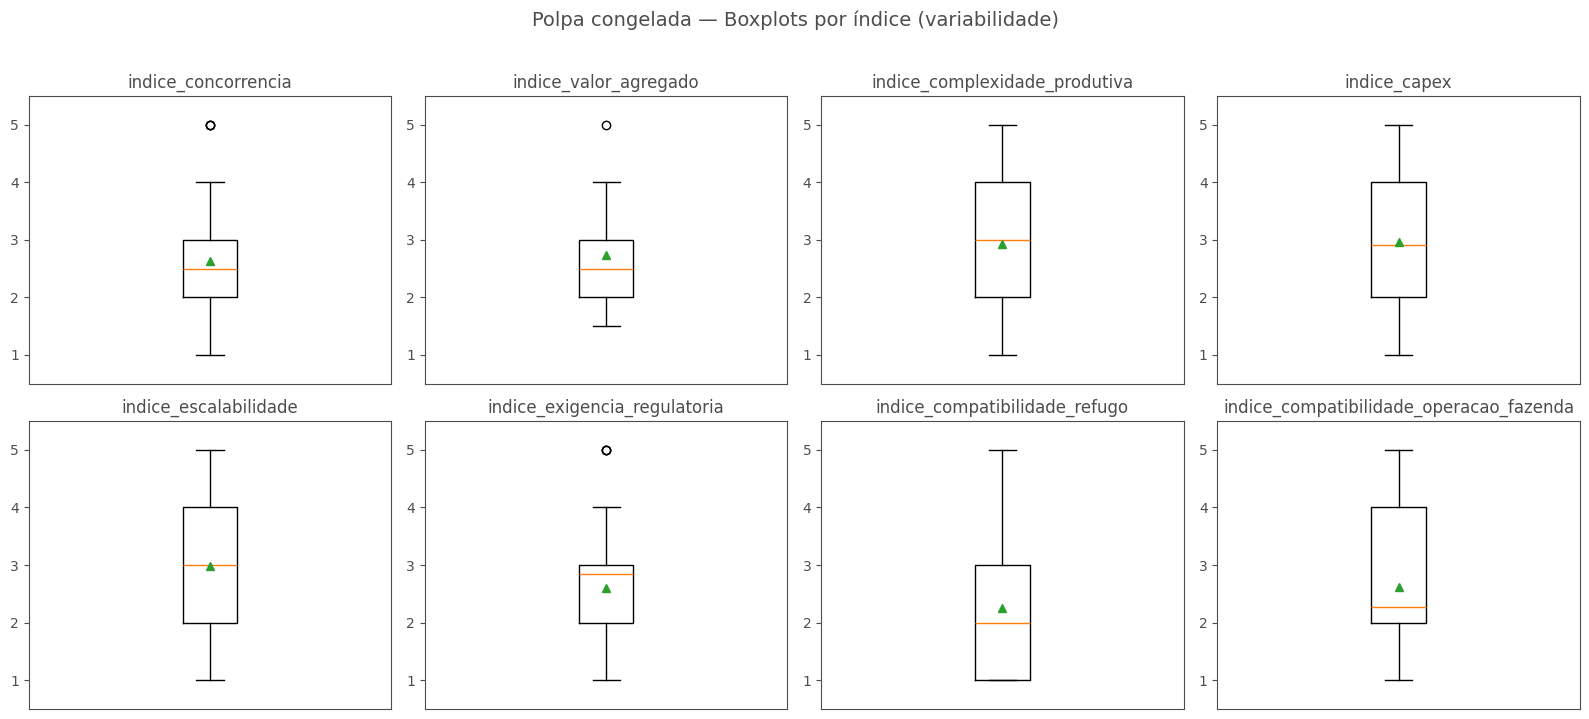


--- Estatísticas econômicas (recorte) ---
                         count          mean        median           std  \
faturamento_empresa_brl   60.0  4.228759e+10  1.350000e+10  7.320485e+10   
margem_media_percentual   60.0  2.781000e+01  2.891000e+01  1.106000e+01   

                                  min           25%           50%  \
faturamento_empresa_brl  1.200000e+08  6.225000e+08  1.350000e+10   
margem_media_percentual  9.410000e+00  1.784000e+01  2.891000e+01   

                                  75%           max  
faturamento_empresa_brl  7.200000e+10  3.750000e+11  
margem_media_percentual  3.586000e+01  5.470000e+01  


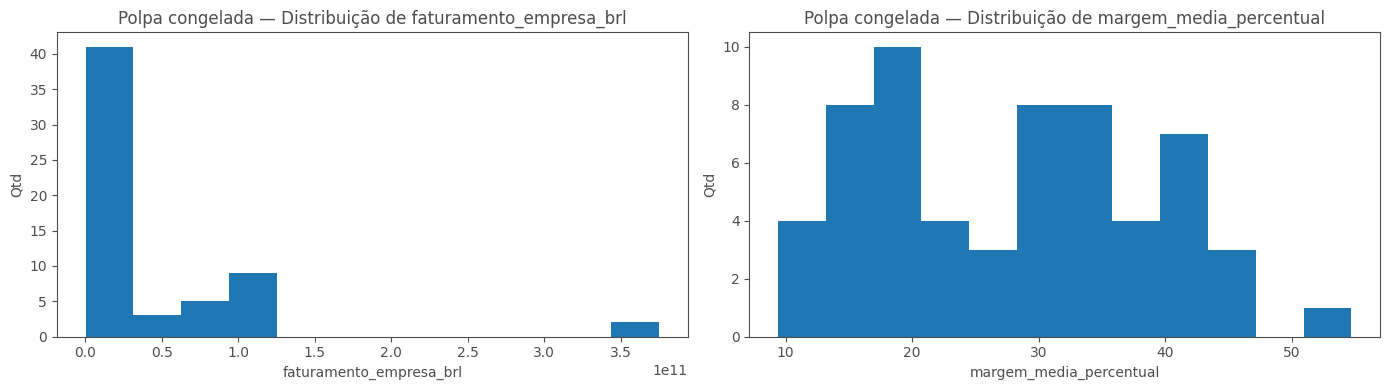

C:\Users\joaop\AppData\Local\Temp\ipykernel_40616\3962835849.py:215: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


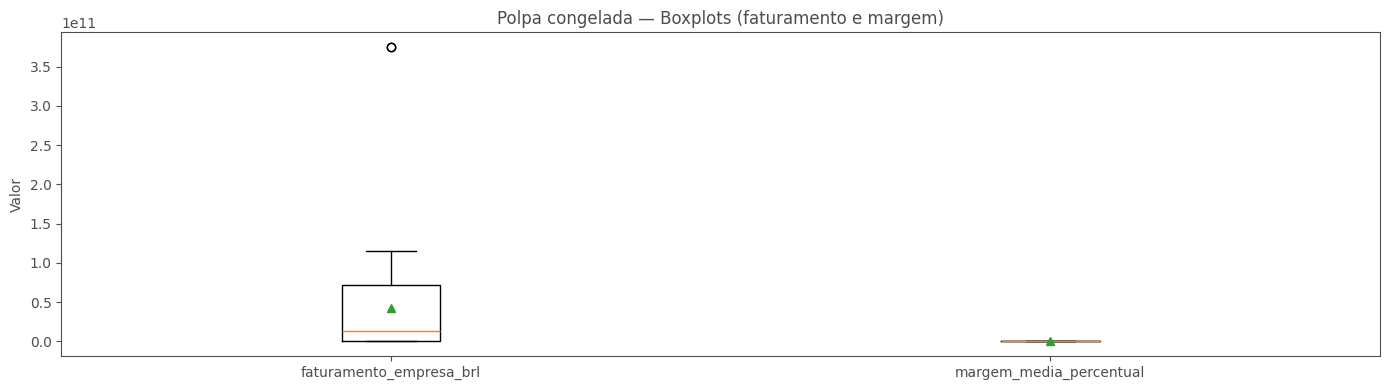

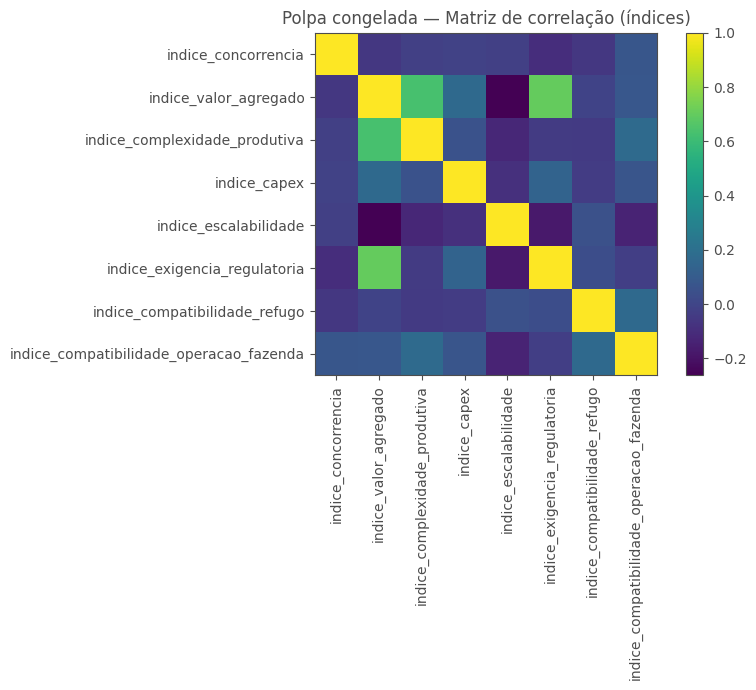

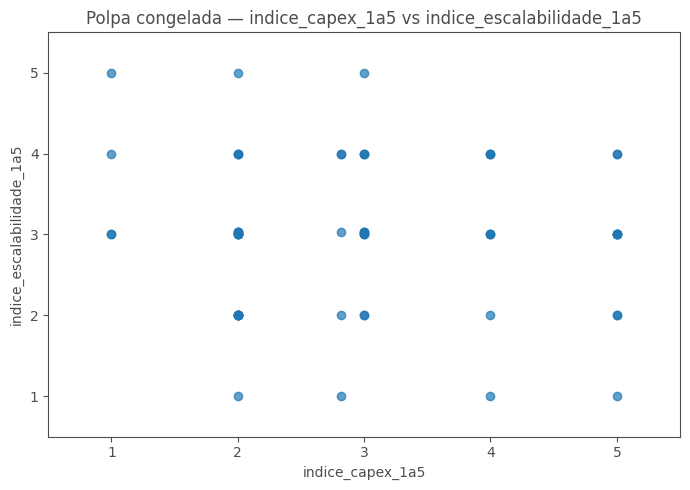

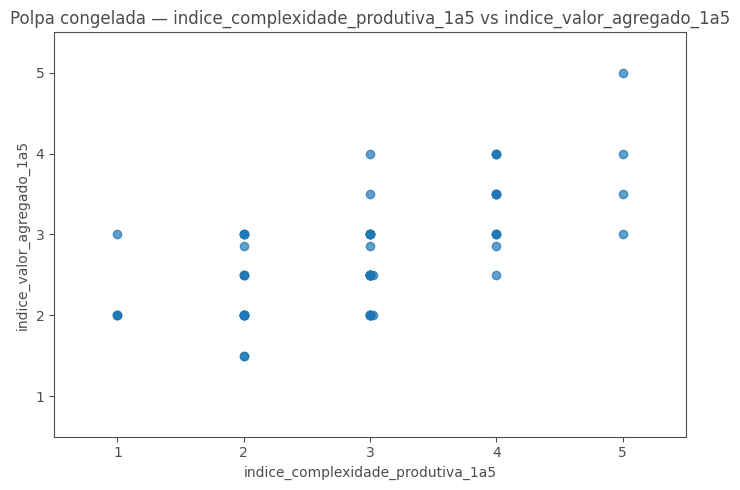

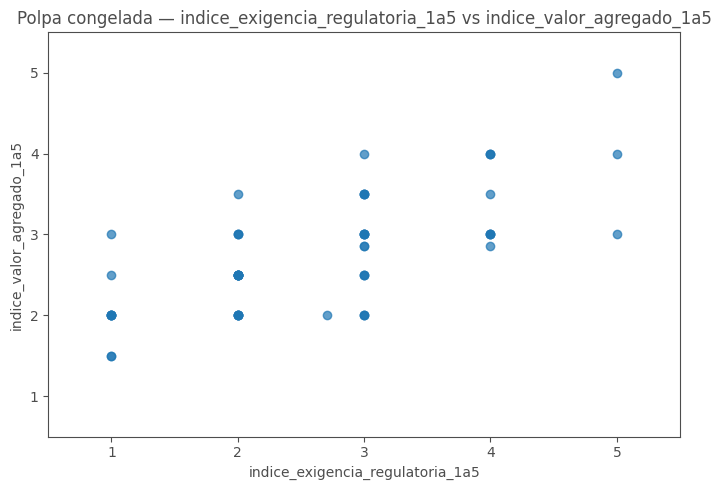

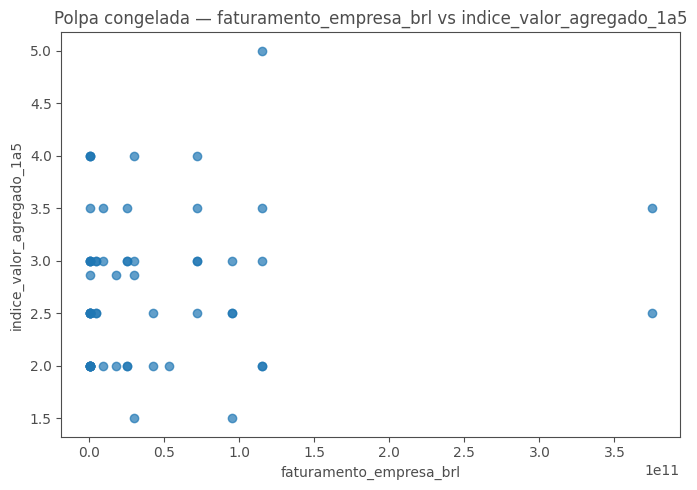

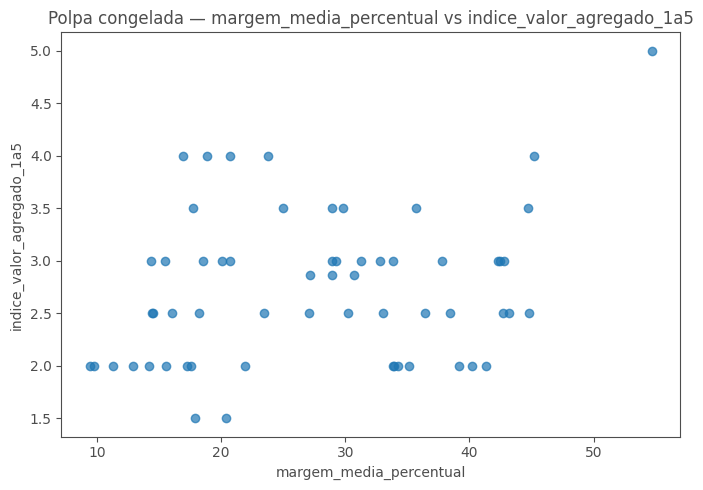

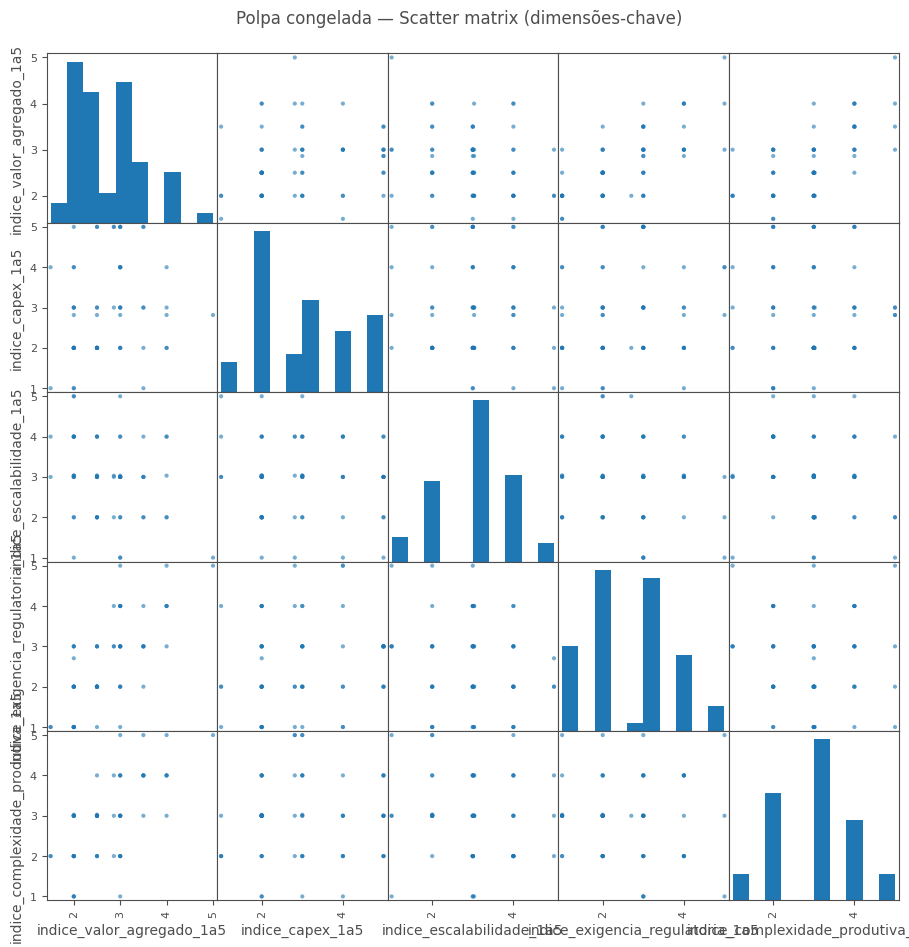

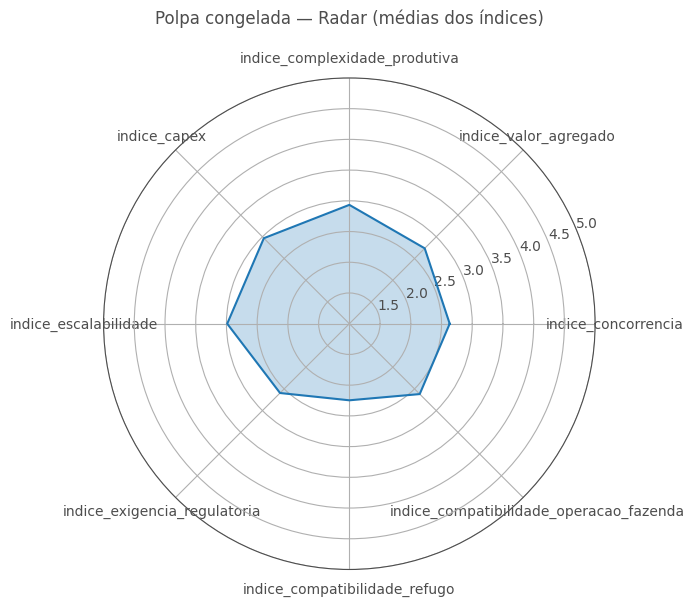

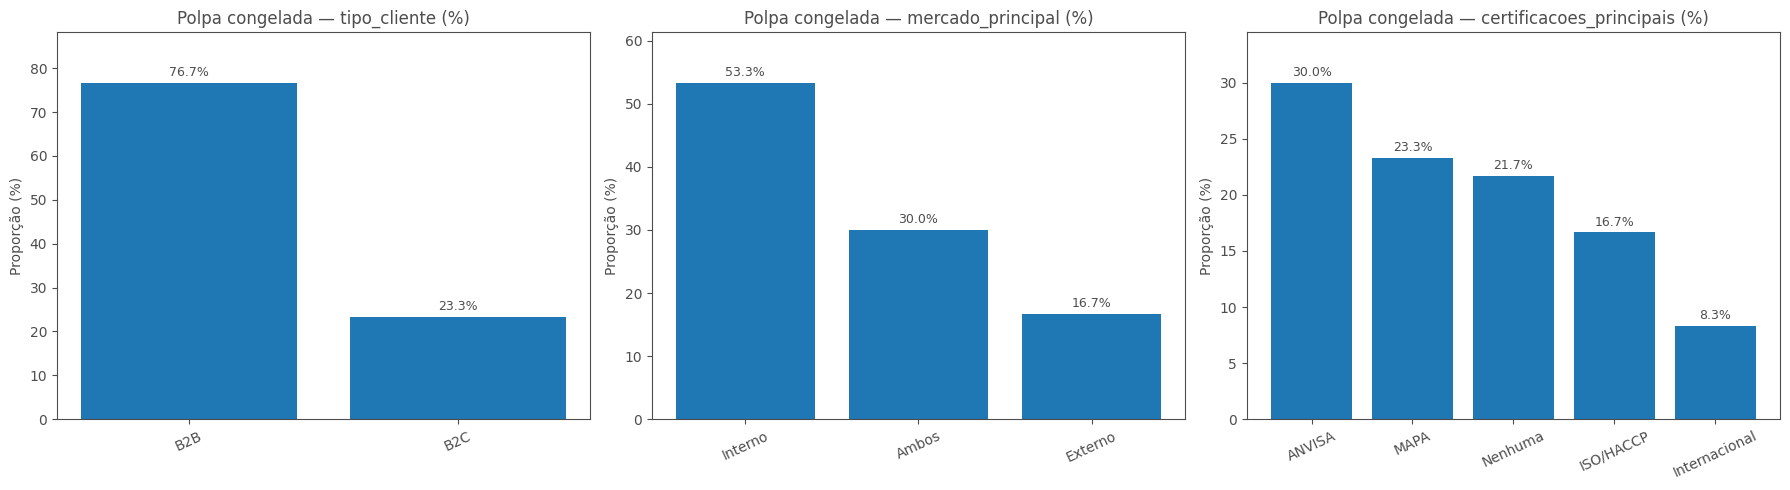


--- Insights automáticos (baseados no recorte) ---
Forças (top 3 médias):
  • indice_escalabilidade_1a5: 2.99
  • indice_capex_1a5: 2.97
  • indice_complexidade_produtiva_1a5: 2.93
Pontos de atenção (bottom 3 médias):
  • indice_compatibilidade_operacao_fazenda_1a5: 2.62
  • indice_exigencia_regulatoria_1a5: 2.6
  • indice_compatibilidade_refugo_1a5: 2.25
Maior variabilidade (std alta) — menos previsível:
  • indice_compatibilidade_operacao_fazenda_1a5: 1.3
  • indice_capex_1a5: 1.2
  • indice_compatibilidade_refugo_1a5: 1.17

Categorias mais comuns dentro do produto:
  • Ingredientes Alimentícios & Funcionais (B2B): 60 (100.0%)

Insights econômicos:
  • faturamento_empresa_brl:
     média = 42,287,586,206.90
     mediana = 13,500,000,000.00
     desvio padrão = 73,204,852,328.53
  • margem_media_percentual:
     média = 27.81
     mediana = 28.91
     desvio padrão = 11.06

✅ Fim da análise individual.


ANÁLISE INDIVIDUAL — Óleo / manteiga de semente de manga
Registros encontrados: 

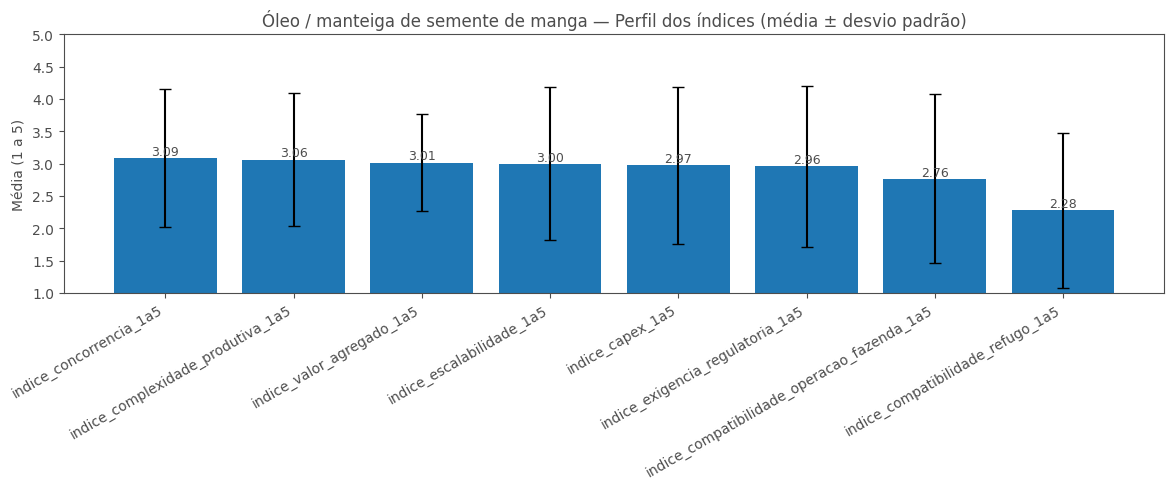

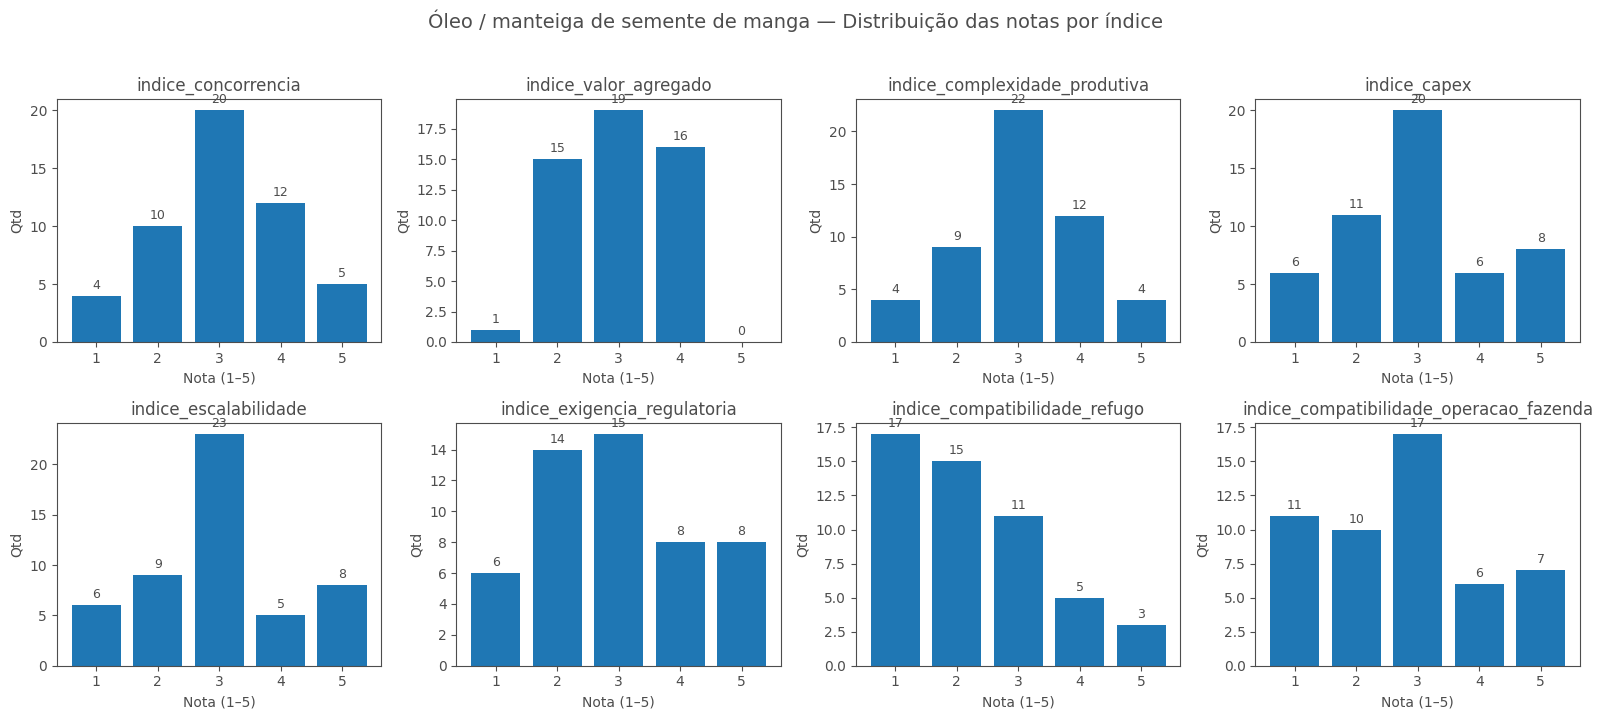

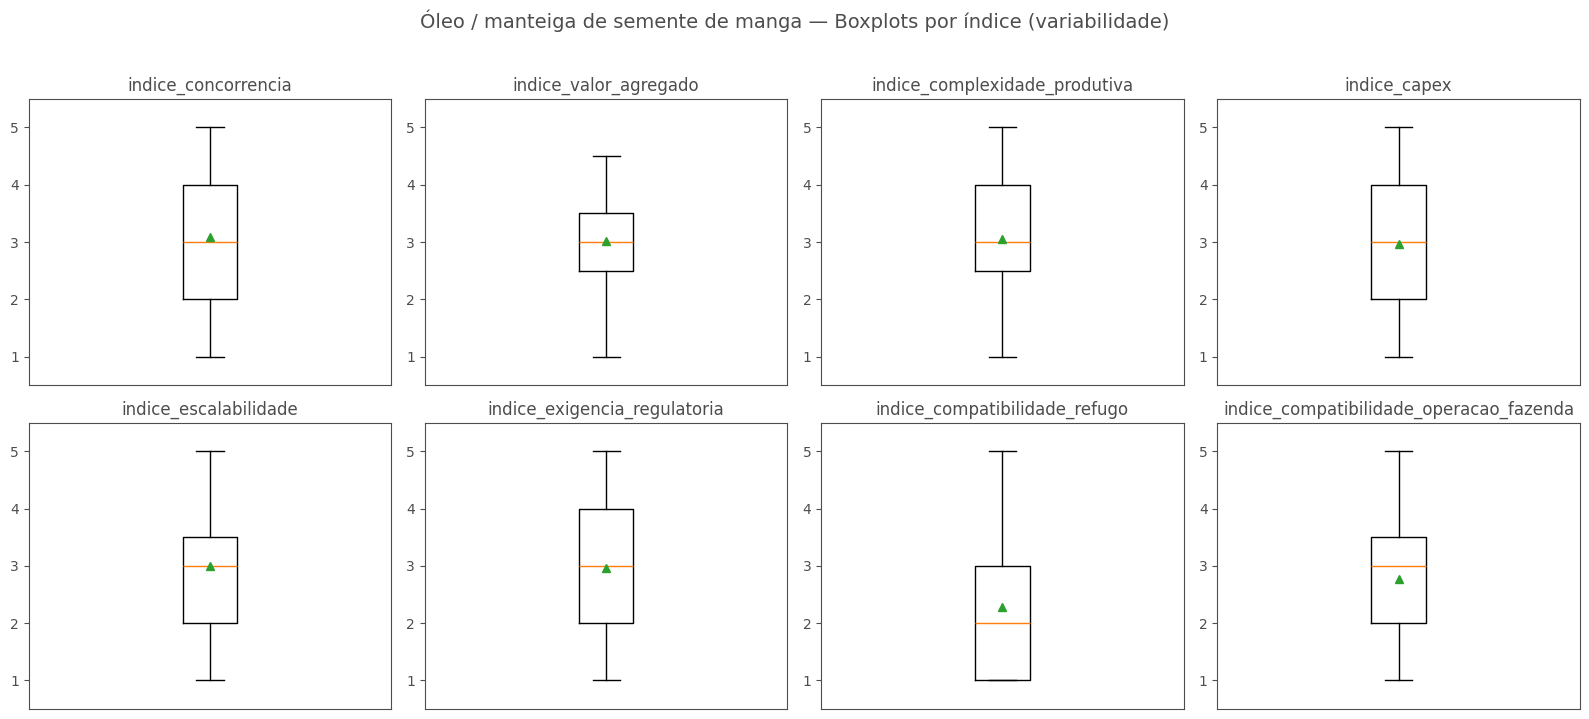


--- Estatísticas econômicas (recorte) ---
                         count          mean        median           std  \
faturamento_empresa_brl   51.0  5.323060e+10  1.800000e+10  8.910043e+10   
margem_media_percentual   51.0  2.990000e+01  2.780000e+01  1.075000e+01   

                                  min           25%           50%  \
faturamento_empresa_brl  1.200000e+08  7.600000e+08  1.800000e+10   
margem_media_percentual  1.128000e+01  2.416000e+01  2.780000e+01   

                                  75%           max  
faturamento_empresa_brl  7.200000e+10  3.750000e+11  
margem_media_percentual  3.641000e+01  5.299000e+01  


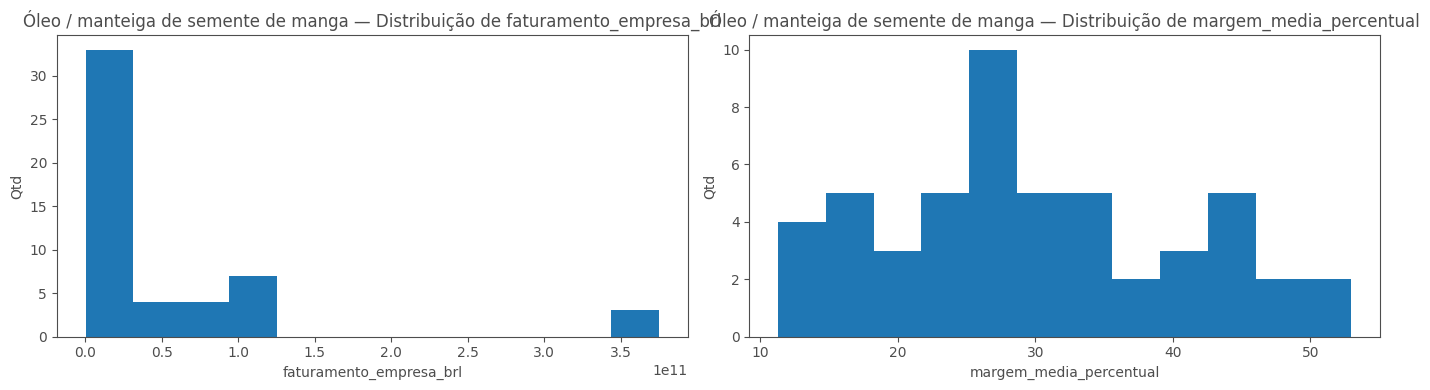

C:\Users\joaop\AppData\Local\Temp\ipykernel_40616\3962835849.py:215: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


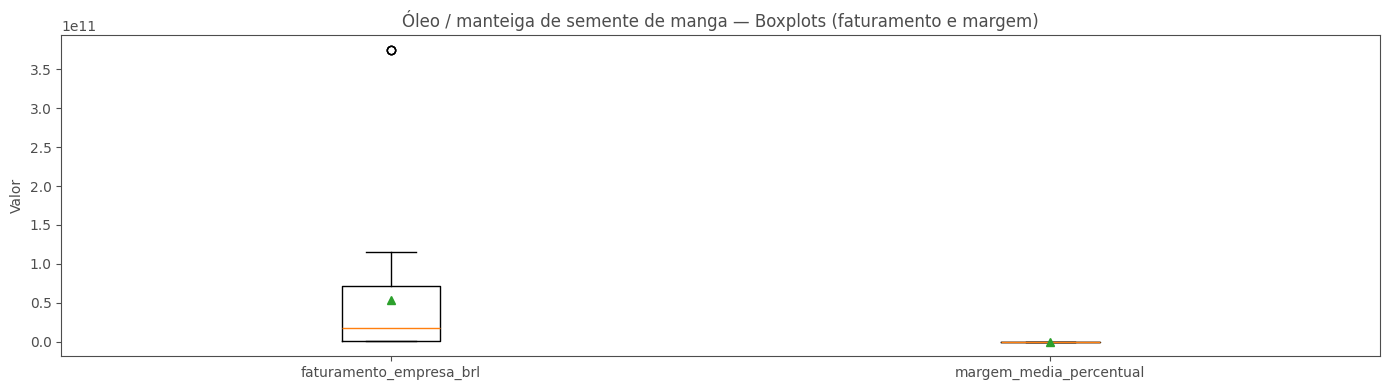

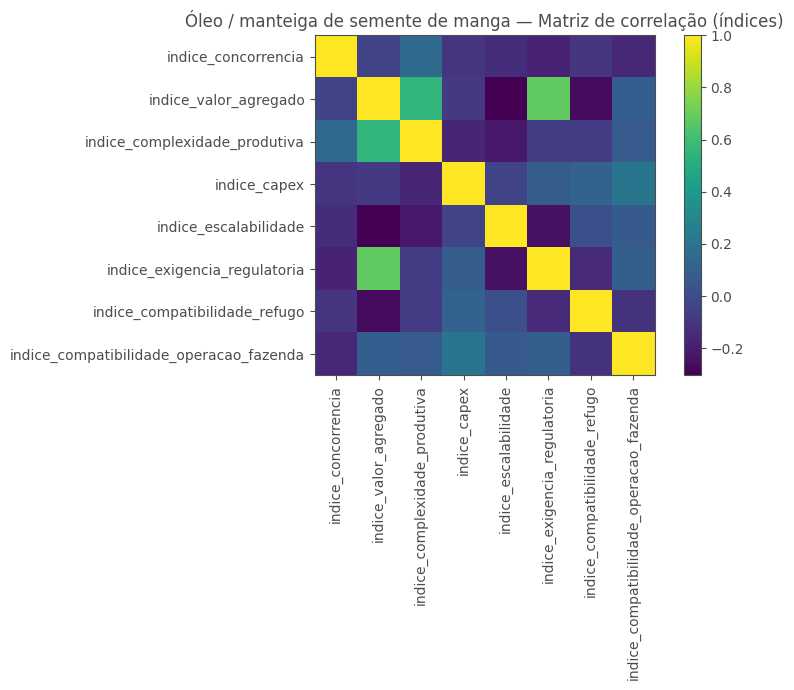

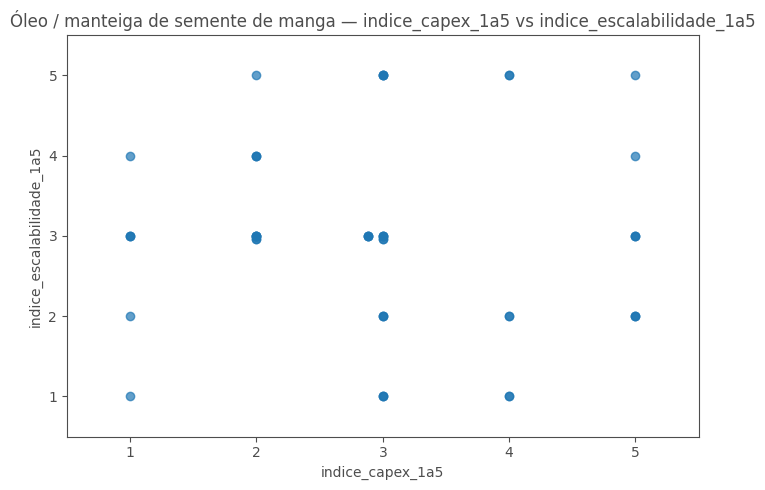

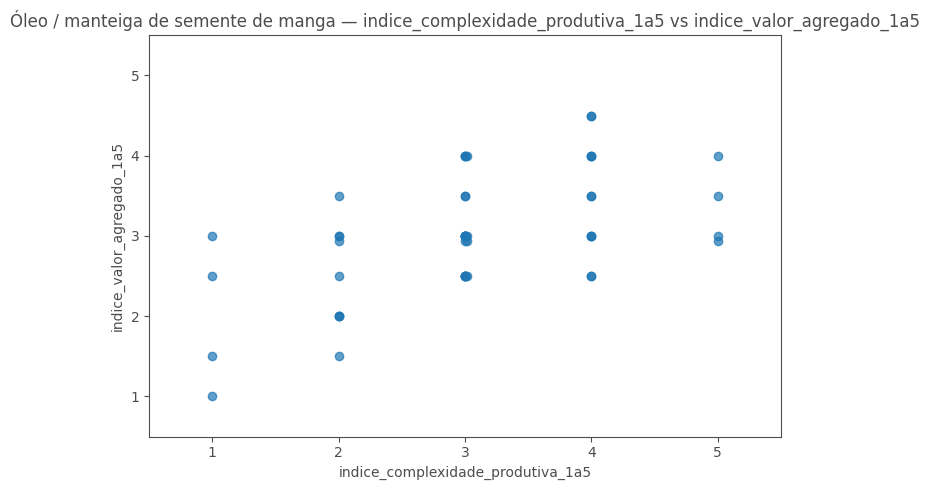

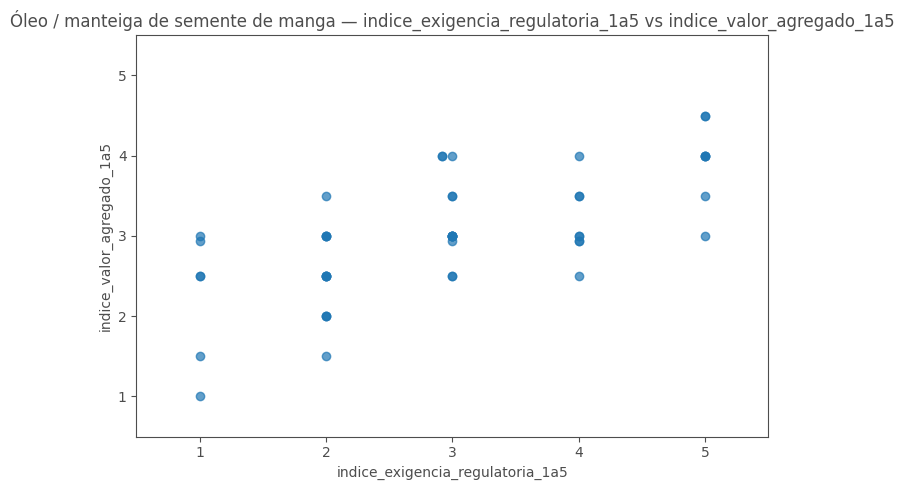

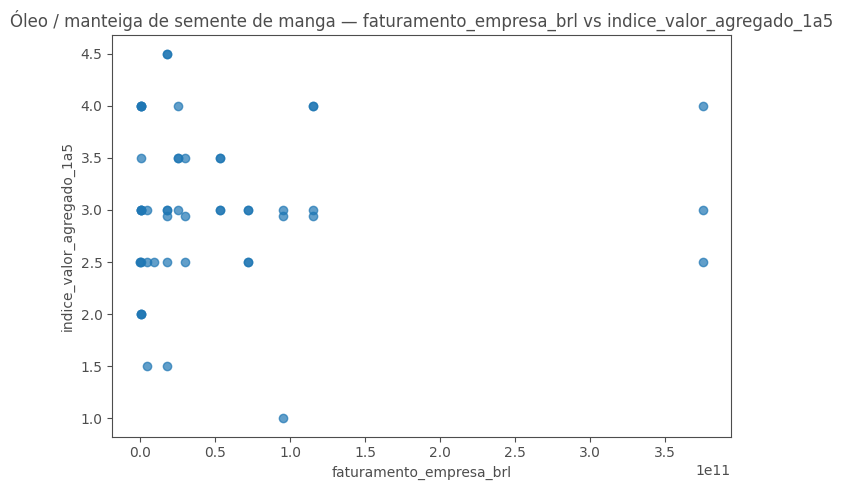

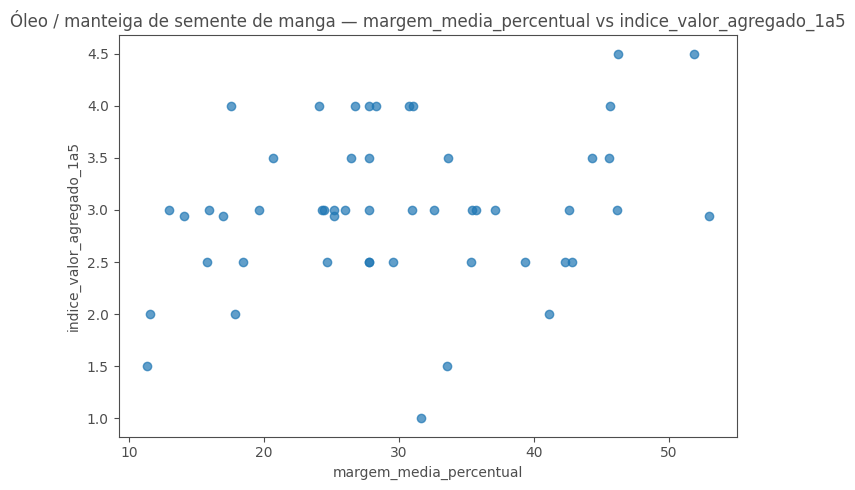

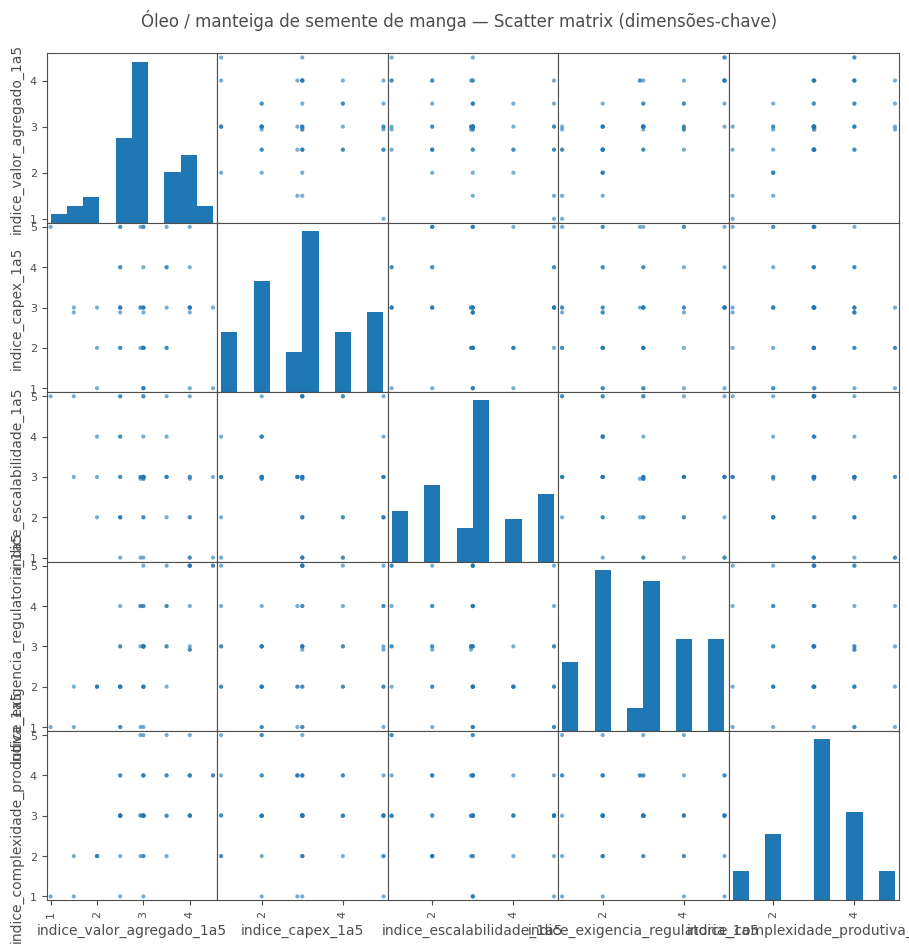

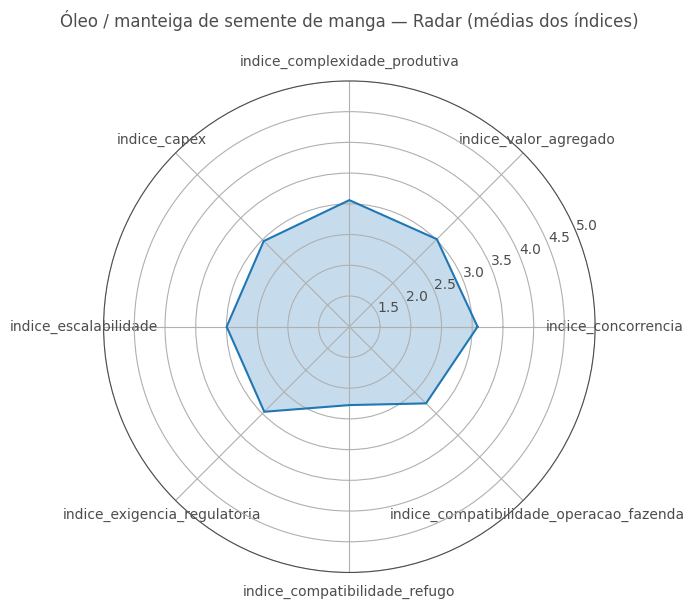

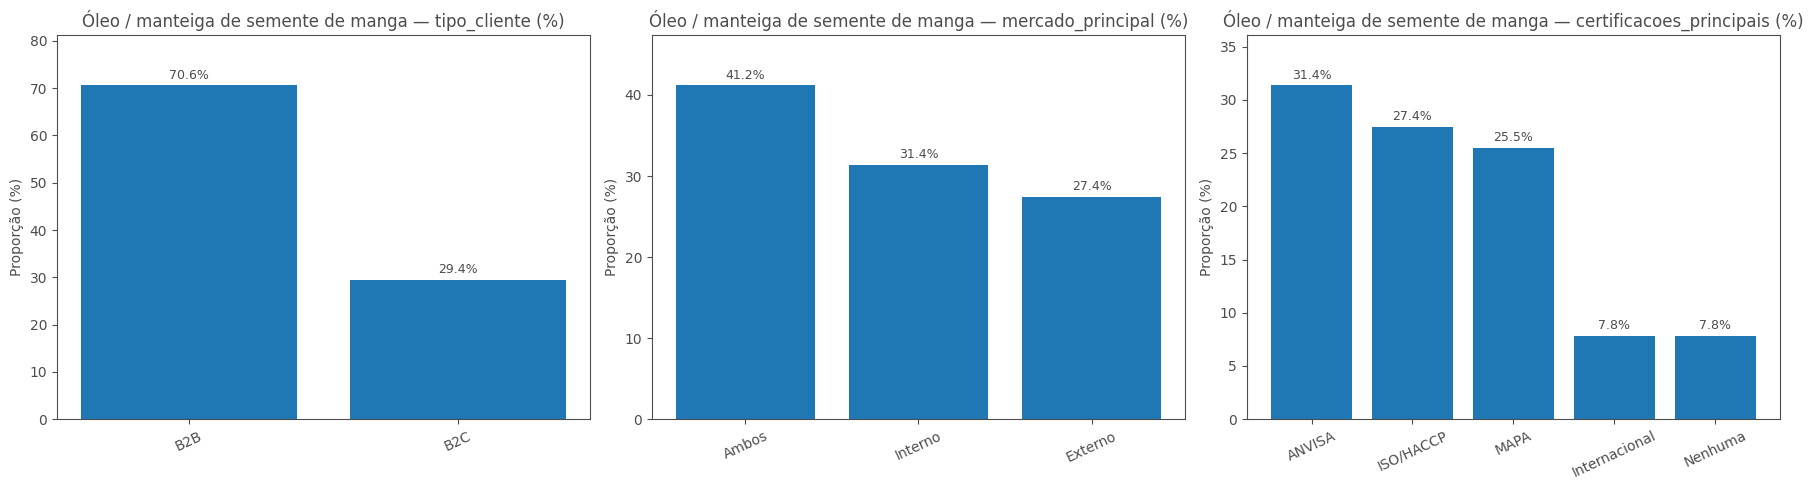


--- Insights automáticos (baseados no recorte) ---
Forças (top 3 médias):
  • indice_concorrencia_1a5: 3.09
  • indice_complexidade_produtiva_1a5: 3.06
  • indice_valor_agregado_1a5: 3.01
Pontos de atenção (bottom 3 médias):
  • indice_exigencia_regulatoria_1a5: 2.96
  • indice_compatibilidade_operacao_fazenda_1a5: 2.76
  • indice_compatibilidade_refugo_1a5: 2.28
Maior variabilidade (std alta) — menos previsível:
  • indice_compatibilidade_operacao_fazenda_1a5: 1.31
  • indice_exigencia_regulatoria_1a5: 1.25
  • indice_capex_1a5: 1.21

Categorias mais comuns dentro do produto:
  • Cosméticos, Higiene & Perfumaria: 51 (100.0%)

Insights econômicos:
  • faturamento_empresa_brl:
     média = 53,230,600,000.00
     mediana = 18,000,000,000.00
     desvio padrão = 89,100,429,974.50
  • margem_media_percentual:
     média = 29.90
     mediana = 27.80
     desvio padrão = 10.75

✅ Fim da análise individual.



In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import unicodedata
from pandas.plotting import scatter_matrix

# ============================================================
# CONFIG
# ============================================================
col_produto = "produto"
col_categoria = "categoria"

indices = [
    "indice_concorrencia_1a5",
    "indice_valor_agregado_1a5",
    "indice_complexidade_produtiva_1a5",
    "indice_capex_1a5",
    "indice_escalabilidade_1a5",
    "indice_exigencia_regulatoria_1a5",
    "indice_compatibilidade_refugo_1a5",
    "indice_compatibilidade_operacao_fazenda_1a5",
]

qualitativas = [
    "tipo_cliente",
    "mercado_principal",
    "certificacoes_principais",
]

# Features econômicas (NOVO)
features_economicas = [
    "faturamento_empresa_brl",
    "margem_media_percentual",
]

# NOMES EXATOS (da sua imagem)
produtos_escolhidos = [
    "Polpa congelada",
    "Óleo / manteiga de semente de manga",
]

# ============================================================
# HELPERS
# ============================================================
def normalizar_texto(s: str) -> str:
    """
    Normaliza texto para comparação robusta:
    - converte para string
    - strip + lower
    - remove acentuação
    - remove espaços duplicados
    """
    if s is None:
        return ""
    s = str(s).strip().lower()
    s = unicodedata.normalize("NFKD", s)
    s = "".join(ch for ch in s if not unicodedata.combining(ch))
    s = " ".join(s.split())
    return s


def filtrar_produto_exato(df: pd.DataFrame, nome_produto: str) -> pd.DataFrame:
    if col_produto not in df.columns:
        raise KeyError(f"Coluna '{col_produto}' não existe no df.")
    alvo = normalizar_texto(nome_produto)
    serie_norm = df[col_produto].astype(str).map(normalizar_texto)
    return df.loc[serie_norm == alvo].copy()


def discrete_counts_1a5(series: pd.Series) -> pd.Series:
    s = pd.to_numeric(series, errors="coerce").dropna().round(0).astype(int)
    return s.value_counts().reindex([1, 2, 3, 4, 5]).fillna(0).astype(int)


def radar_plot(means: pd.Series, title: str):
    labels = [c.replace("_1a5", "") for c in means.index.tolist()]
    values = means.values.tolist()

    angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
    angles += angles[:1]
    values += values[:1]

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
    ax.plot(angles, values)
    ax.fill(angles, values, alpha=0.25)
    ax.set_thetagrids(np.degrees(angles[:-1]), labels)
    ax.set_ylim(1, 5)
    ax.set_title(title, pad=20)
    plt.tight_layout()
    plt.show()


def analisar_produto(df: pd.DataFrame, nome_produto: str):
    sub = filtrar_produto_exato(df, nome_produto)
    n = len(sub)

    print("\n" + "=" * 90)
    print(f"ANÁLISE INDIVIDUAL — {nome_produto}")
    print("=" * 90)
    print(f"Registros encontrados: {n} ({(n / len(df) * 100):.2f}% do dataset)")

    if n == 0:
        print("\n⚠️ Não achei nenhuma linha com esse nome exato.")
        print("Sugestão: confira os valores únicos mais próximos na coluna 'produto':")
        print(df[col_produto].dropna().astype(str).value_counts().head(15))
        return

    # ------------------------------------------------------------
    # 0) CHECK NULOS
    # ------------------------------------------------------------
    cols_check = [col_produto, col_categoria] + indices + qualitativas + features_economicas
    cols_check = [c for c in cols_check if c in sub.columns]

    print("\n--- Nulos no recorte (top 12 colunas) ---")
    print(sub[cols_check].isna().sum().sort_values(ascending=False).head(12))

    # ------------------------------------------------------------
    # 1) ESTATÍSTICAS + PERFIL (média ± std)
    # ------------------------------------------------------------
    stats = sub[indices].describe().T
    stats["median"] = sub[indices].median()
    stats = stats[["count", "mean", "median", "std", "min", "25%", "50%", "75%", "max"]].round(2)

    print("\n--- Estatísticas dos índices (recorte) ---")
    print(stats)

    means = sub[indices].mean().sort_values(ascending=False)
    stds = sub[indices].std().reindex(means.index)

    plt.figure(figsize=(12, 5))
    plt.bar(means.index.astype(str), means.values, yerr=stds.values, capsize=4)
    plt.title(f"{nome_produto} — Perfil dos índices (média ± desvio padrão)")
    plt.ylabel("Média (1 a 5)")
    plt.xticks(rotation=30, ha="right")
    plt.ylim(1, 5)
    for i, v in enumerate(means.values):
        plt.text(i, min(4.95, v + 0.05), f"{v:.2f}", ha="center", fontsize=9)
    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------------
    # 2) DISTRIBUIÇÃO 1–5 (grid)
    # ------------------------------------------------------------
    fig, axes = plt.subplots(2, 4, figsize=(16, 7))
    axes = axes.ravel()

    for ax, col in zip(axes, indices):
        counts = discrete_counts_1a5(sub[col])
        ax.bar(counts.index, counts.values)
        ax.set_title(col.replace("_1a5", ""))
        ax.set_xlabel("Nota (1–5)")
        ax.set_ylabel("Qtd")
        ax.set_xticks([1, 2, 3, 4, 5])
        for x, y in zip(counts.index, counts.values):
            ax.text(
                x,
                y + (counts.max() * 0.03 if counts.max() else 0.2),
                str(y),
                ha="center",
                fontsize=9,
            )

    plt.suptitle(f"{nome_produto} — Distribuição das notas por índice", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------------
    # 3) BOXPLOTS (grid)
    # ------------------------------------------------------------
    fig, axes = plt.subplots(2, 4, figsize=(16, 7))
    axes = axes.ravel()

    for ax, col in zip(axes, indices):
        data = pd.to_numeric(sub[col], errors="coerce").dropna()
        ax.boxplot(data, vert=True, showmeans=True)
        ax.set_title(col.replace("_1a5", ""))
        ax.set_ylim(0.5, 5.5)
        ax.set_xticks([])

    plt.suptitle(f"{nome_produto} — Boxplots por índice (variabilidade)", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------------
    # 3.5) (NOVO) ANÁLISE ECONÔMICA — faturamento e margem
    # ------------------------------------------------------------
    econ_cols = [c for c in features_economicas if c in sub.columns]

    if econ_cols:
        econ_num = sub[econ_cols].apply(pd.to_numeric, errors="coerce")

        print("\n--- Estatísticas econômicas (recorte) ---")
        econ_stats = econ_num.describe().T
        econ_stats["median"] = econ_num.median()
        econ_stats = econ_stats[["count", "mean", "median", "std", "min", "25%", "50%", "75%", "max"]].round(2)
        print(econ_stats)

        # Histogramas
        fig, axes = plt.subplots(1, len(econ_cols), figsize=(7 * len(econ_cols), 4))
        if len(econ_cols) == 1:
            axes = [axes]

        for ax, col in zip(axes, econ_cols):
            data = econ_num[col].dropna()
            ax.hist(data, bins=12)
            ax.set_title(f"{nome_produto} — Distribuição de {col}")
            ax.set_xlabel(col)
            ax.set_ylabel("Qtd")

        plt.tight_layout()
        plt.show()

        # Boxplots econômicos
        plt.figure(figsize=(6 + 4 * len(econ_cols), 4))
        plt.boxplot(
            [econ_num[c].dropna() for c in econ_cols],
            labels=econ_cols,
            showmeans=True,
        )
        plt.title(f"{nome_produto} — Boxplots (faturamento e margem)")
        plt.ylabel("Valor")
        plt.tight_layout()
        plt.show()
    else:
        print("\n(Análise econômica pulada: colunas econômicas não encontradas no df.)")

    # ------------------------------------------------------------
    # 4) CORRELAÇÃO + SCATTERS CHAVE (trade-offs)
    # ------------------------------------------------------------
    corr = sub[indices].corr()

    plt.figure(figsize=(9, 7))
    plt.imshow(corr.values)
    plt.title(f"{nome_produto} — Matriz de correlação (índices)")
    plt.xticks(range(len(indices)), [c.replace("_1a5", "") for c in indices], rotation=90)
    plt.yticks(range(len(indices)), [c.replace("_1a5", "") for c in indices])
    plt.colorbar()
    plt.tight_layout()
    plt.show()

    pares_scatter = [
        ("indice_capex_1a5", "indice_escalabilidade_1a5"),
        ("indice_complexidade_produtiva_1a5", "indice_valor_agregado_1a5"),
        ("indice_exigencia_regulatoria_1a5", "indice_valor_agregado_1a5"),
    ]

    for x_col, y_col in pares_scatter:
        plt.figure(figsize=(7, 5))
        plt.scatter(sub[x_col], sub[y_col], alpha=0.7)
        plt.title(f"{nome_produto} — {x_col} vs {y_col}")
        plt.xlabel(x_col)
        plt.ylabel(y_col)
        plt.xlim(0.5, 5.5)
        plt.ylim(0.5, 5.5)
        plt.tight_layout()
        plt.show()

    # ------------------------------------------------------------
    # 4.5) (NOVO) ECONOMIA × VALOR AGREGADO
    # ------------------------------------------------------------
    if econ_cols and "indice_valor_agregado_1a5" in sub.columns:
        econ_num = sub[econ_cols].apply(pd.to_numeric, errors="coerce")
        for col in econ_cols:
            tmp = pd.DataFrame(
                {
                    col: econ_num[col],
                    "indice_valor_agregado_1a5": pd.to_numeric(sub["indice_valor_agregado_1a5"], errors="coerce"),
                }
            ).dropna()

            if tmp.empty:
                continue

            plt.figure(figsize=(7, 5))
            plt.scatter(tmp[col], tmp["indice_valor_agregado_1a5"], alpha=0.7)
            plt.title(f"{nome_produto} — {col} vs indice_valor_agregado_1a5")
            plt.xlabel(col)
            plt.ylabel("indice_valor_agregado_1a5")
            plt.tight_layout()
            plt.show()

    # ------------------------------------------------------------
    # Scatter matrix (visão multivariada) — usa 5 dimensões mais "narrativas"
    # ------------------------------------------------------------
    principais = [
        "indice_valor_agregado_1a5",
        "indice_capex_1a5",
        "indice_escalabilidade_1a5",
        "indice_exigencia_regulatoria_1a5",
        "indice_complexidade_produtiva_1a5",
    ]
    principais = [c for c in principais if c in sub.columns]

    if sub[principais].dropna().shape[0] >= 5:
        _ = scatter_matrix(sub[principais].dropna(), figsize=(11, 11), diagonal="hist", alpha=0.6)
        plt.suptitle(f"{nome_produto} — Scatter matrix (dimensões-chave)", y=0.92)
        plt.show()
    else:
        print("\n(Scatter matrix pulada: poucas linhas completas nas dimensões-chave.)")

    # ------------------------------------------------------------
    # 5) RADAR (ótimo para slide)
    # ------------------------------------------------------------
    radar_plot(sub[indices].mean(), f"{nome_produto} — Radar (médias dos índices)")

    # ------------------------------------------------------------
    # 6) QUALITATIVAS (3 gráficos de proporção)
    # ------------------------------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, col in zip(axes, qualitativas):
        if col not in sub.columns:
            ax.axis("off")
            continue

        vc = sub[col].value_counts(dropna=False)
        pct = (vc / vc.sum() * 100).round(2)

        ax.bar(pct.index.astype(str), pct.values)
        ax.set_title(f"{nome_produto} — {col} (%)")
        ax.set_ylabel("Proporção (%)")
        ax.tick_params(axis="x", rotation=25)
        ax.set_ylim(0, max(5, pct.max() * 1.15))
        for i, v in enumerate(pct.values):
            ax.text(i, v + (pct.max() * 0.02 if pct.max() else 0.2), f"{v:.1f}%", ha="center", fontsize=9)

    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------------
    # 7) INSIGHTS AUTOMÁTICOS (texto)
    # ------------------------------------------------------------
    m = sub[indices].mean().sort_values(ascending=False).round(2)
    s = sub[indices].std().sort_values(ascending=False).round(2)

    print("\n--- Insights automáticos (baseados no recorte) ---")
    print("Forças (top 3 médias):")
    for k, v in m.head(3).items():
        print(f"  • {k}: {v}")

    print("Pontos de atenção (bottom 3 médias):")
    for k, v in m.tail(3).items():
        print(f"  • {k}: {v}")

    print("Maior variabilidade (std alta) — menos previsível:")
    for k, v in s.head(3).items():
        print(f"  • {k}: {v}")

    # categoria(s) mais frequente(s) do produto
    if col_categoria in sub.columns:
        top_cat = sub[col_categoria].value_counts().head(3)
        print("\nCategorias mais comuns dentro do produto:")
        for c, q in top_cat.items():
            print(f"  • {c}: {q} ({(q / n * 100):.1f}%)")

    # ------------------------------------------------------------
    # 7.5) (NOVO) INSIGHTS ECONÔMICOS AUTOMÁTICOS
    # ------------------------------------------------------------
    if econ_cols:
        econ_num = sub[econ_cols].apply(pd.to_numeric, errors="coerce")
        print("\nInsights econômicos:")
        for col in econ_cols:
            serie = econ_num[col].dropna()
            if serie.empty:
                continue
            print(f"  • {col}:")
            print(f"     média = {serie.mean():,.2f}")
            print(f"     mediana = {serie.median():,.2f}")
            print(f"     desvio padrão = {serie.std():,.2f}")

    print("\n✅ Fim da análise individual.\n")


# ============================================================
# EXECUÇÃO (um “capítulo” por produto)
# ============================================================
for nome in produtos_escolhidos:
    analisar_produto(df, nome)


# ANÁLISE DE CADA PRODUTO CONCORRENTE


ANÁLISE INDIVIDUAL — Snack de manga desidratada
Registros encontrados: 52 (3.24% do dataset)

--- Estatísticas descritivas ---
                                   count   mean    std   min    25%    50%  \
indice_concorrencia_1a5             52.0   2.84   1.13  1.00   2.00   3.00   
indice_capex_1a5                    52.0   2.70   1.30  1.00   2.00   2.88   
indice_exigencia_regulatoria_1a5    52.0   2.87   1.04  1.00   2.00   3.00   
indice_compatibilidade_refugo_1a5   52.0   2.39   1.22  1.00   1.00   2.00   
margem_media_percentual             52.0  26.64  10.18  9.95  17.12  26.06   

                                     75%    max  
indice_concorrencia_1a5             4.00   5.00  
indice_capex_1a5                    4.00   5.00  
indice_exigencia_regulatoria_1a5    3.00   5.00  
indice_compatibilidade_refugo_1a5   3.00   5.00  
margem_media_percentual            34.73  46.07  


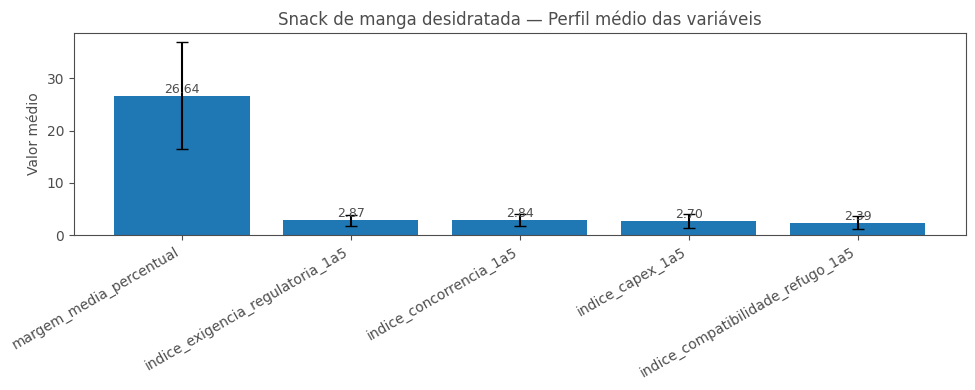

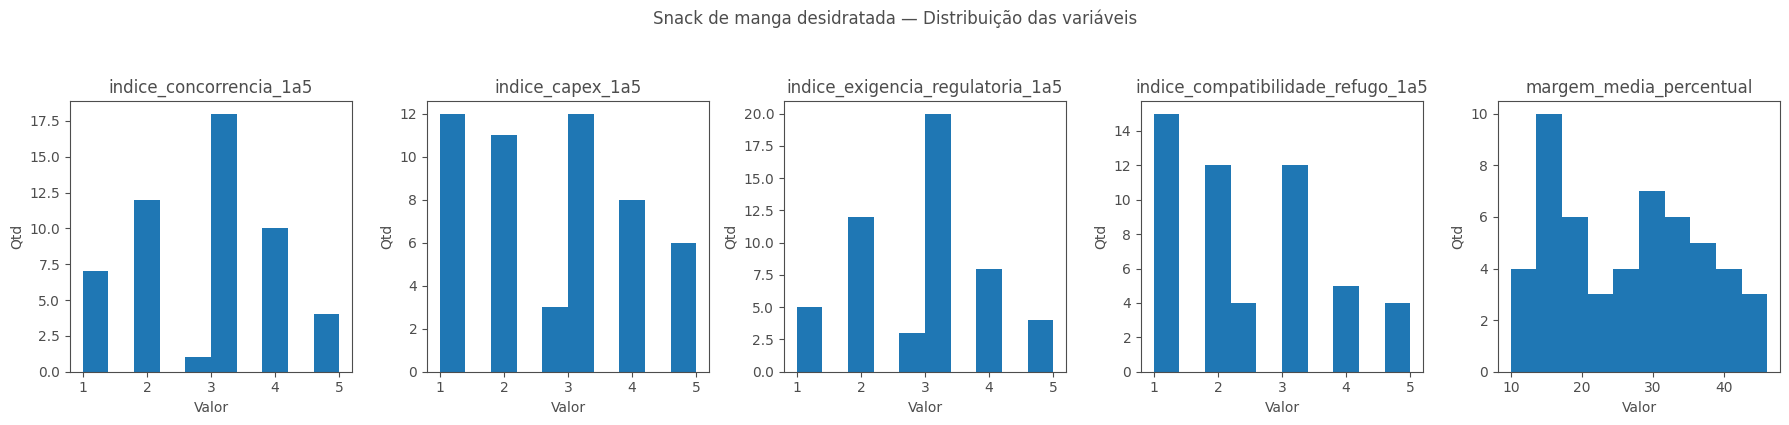

C:\Users\joaop\AppData\Local\Temp\ipykernel_40616\2704652.py:100: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


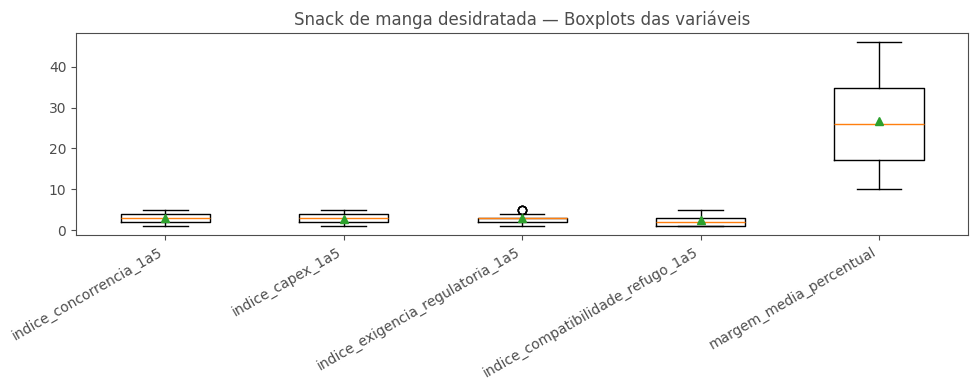


--- Insights automáticos ---
Maiores médias:
 • margem_media_percentual: 26.64
 • indice_exigencia_regulatoria_1a5: 2.87
 • indice_concorrencia_1a5: 2.84
Menores médias:
 • indice_concorrencia_1a5: 2.84
 • indice_capex_1a5: 2.70
 • indice_compatibilidade_refugo_1a5: 2.39

Maior variabilidade (desvio padrão):
 • margem_media_percentual: 10.18
 • indice_capex_1a5: 1.30
 • indice_compatibilidade_refugo_1a5: 1.22

✅ Fim da análise.


ANÁLISE INDIVIDUAL — Suco pronto (NFC)
Registros encontrados: 52 (3.24% do dataset)

--- Estatísticas descritivas ---
                                   count   mean   std   min   25%    50%  \
indice_concorrencia_1a5             52.0   2.78  1.09  1.00   2.0   2.97   
indice_capex_1a5                    52.0   2.84  1.23  1.00   2.0   3.00   
indice_exigencia_regulatoria_1a5    52.0   2.60  1.08  1.00   2.0   2.00   
indice_compatibilidade_refugo_1a5   52.0   2.16  0.96  1.00   1.0   2.00   
margem_media_percentual             52.0  27.32  9.62  9.52  19.9  

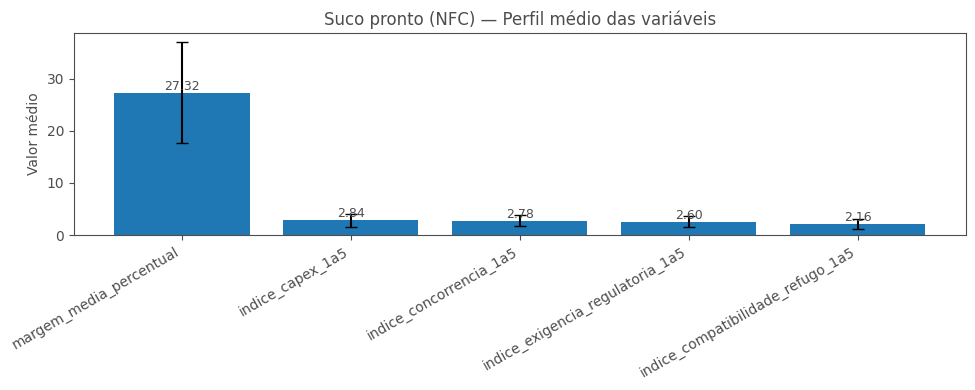

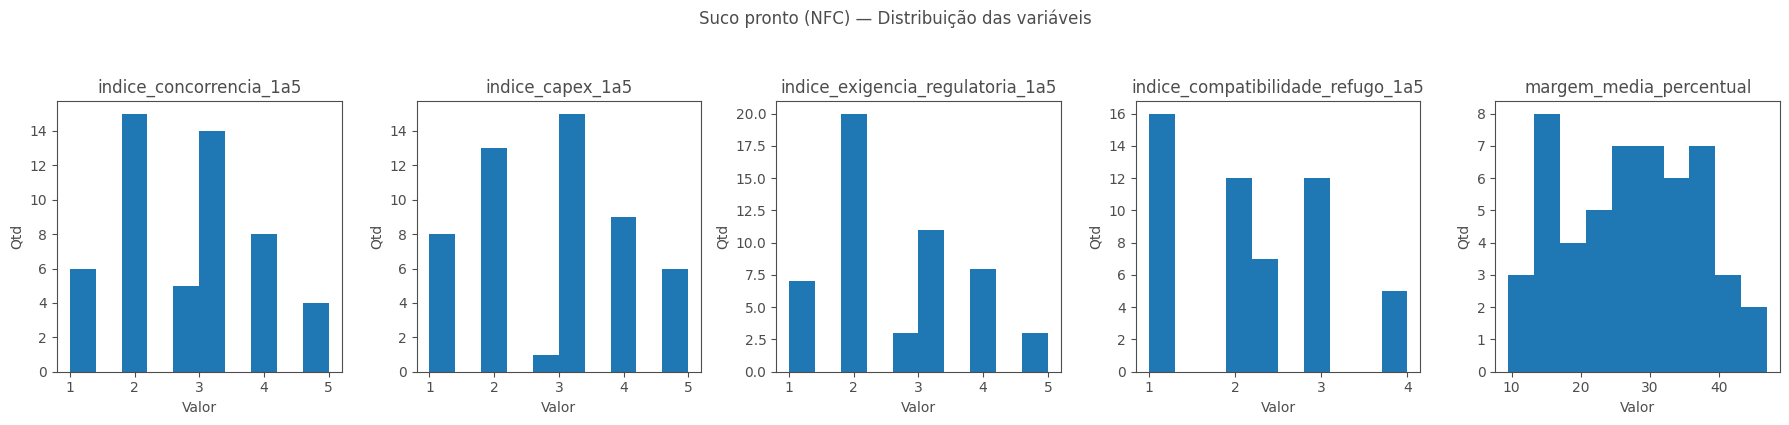

C:\Users\joaop\AppData\Local\Temp\ipykernel_40616\2704652.py:100: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


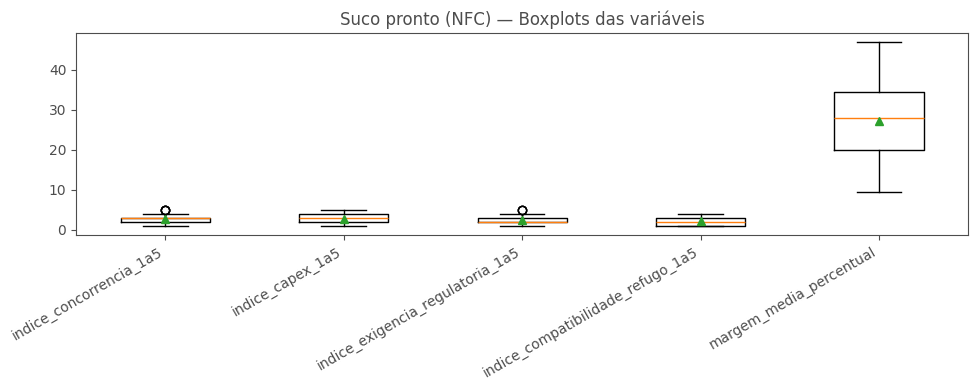


--- Insights automáticos ---
Maiores médias:
 • margem_media_percentual: 27.32
 • indice_capex_1a5: 2.84
 • indice_concorrencia_1a5: 2.78
Menores médias:
 • indice_concorrencia_1a5: 2.78
 • indice_exigencia_regulatoria_1a5: 2.60
 • indice_compatibilidade_refugo_1a5: 2.16

Maior variabilidade (desvio padrão):
 • margem_media_percentual: 9.62
 • indice_capex_1a5: 1.23
 • indice_concorrencia_1a5: 1.09

✅ Fim da análise.


ANÁLISE INDIVIDUAL — Sorbet / picolé
Registros encontrados: 70 (4.36% do dataset)

--- Estatísticas descritivas ---
                                   count   mean    std   min    25%    50%  \
indice_concorrencia_1a5             70.0   2.78   1.19  1.00   2.00   3.00   
indice_capex_1a5                    70.0   2.65   1.24  1.00   2.00   3.00   
indice_exigencia_regulatoria_1a5    70.0   2.98   1.16  1.00   2.00   3.00   
indice_compatibilidade_refugo_1a5   70.0   2.54   1.26  1.00   1.00   2.30   
margem_media_percentual             70.0  28.00  11.92  8.68  16.73  2

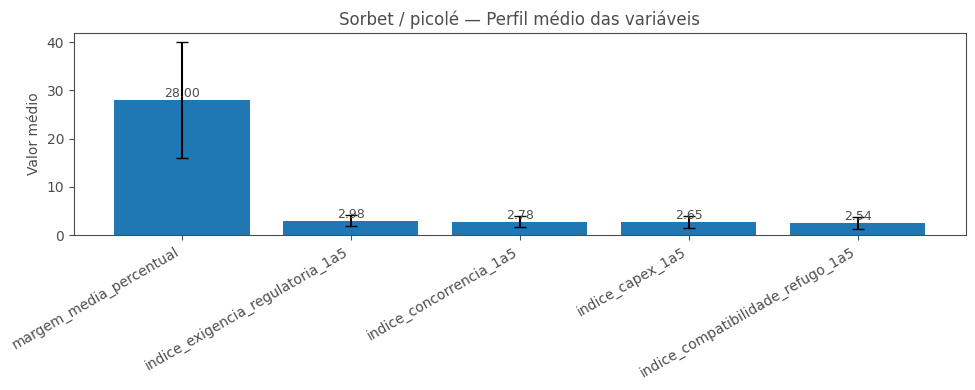

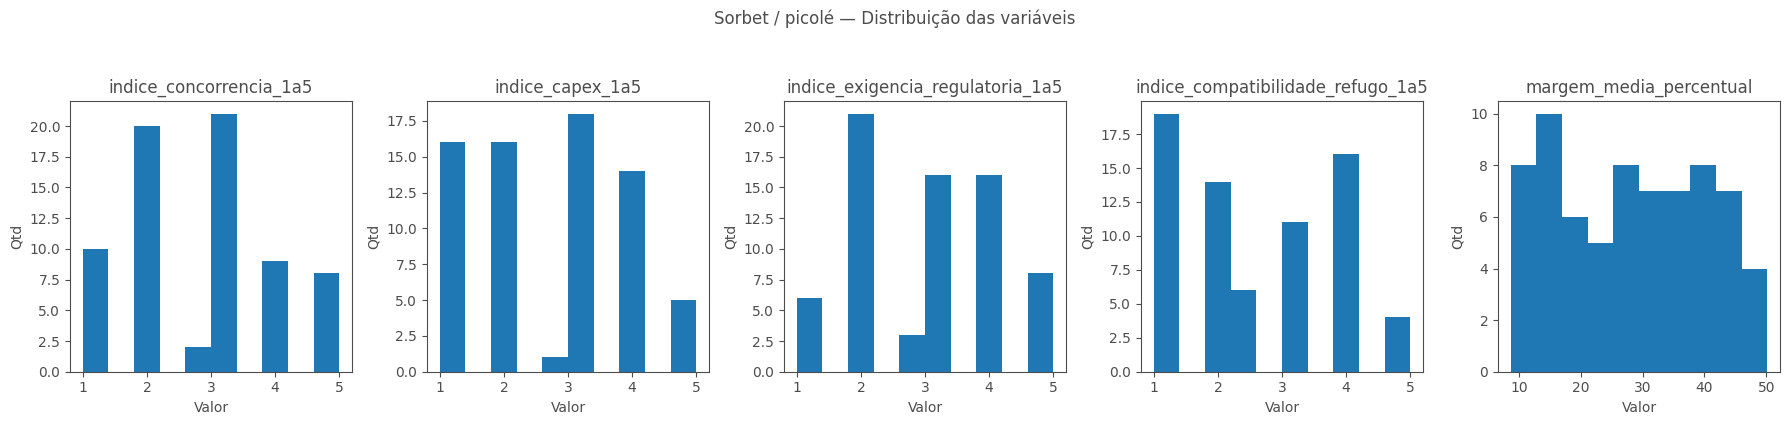

C:\Users\joaop\AppData\Local\Temp\ipykernel_40616\2704652.py:100: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


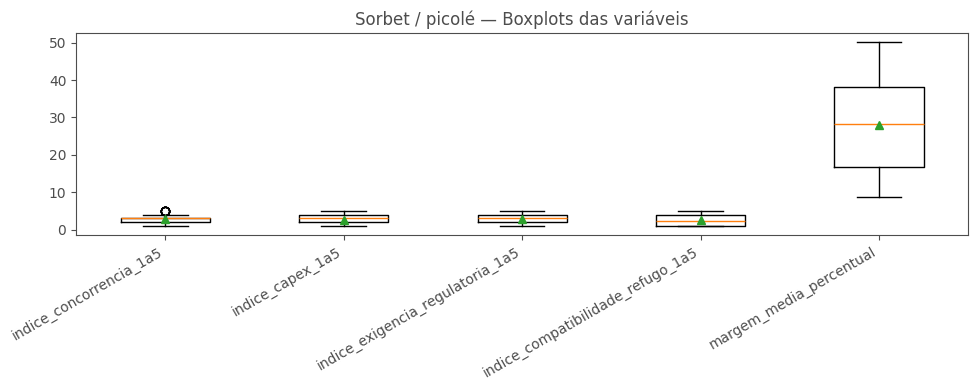


--- Insights automáticos ---
Maiores médias:
 • margem_media_percentual: 28.00
 • indice_exigencia_regulatoria_1a5: 2.98
 • indice_concorrencia_1a5: 2.78
Menores médias:
 • indice_concorrencia_1a5: 2.78
 • indice_capex_1a5: 2.65
 • indice_compatibilidade_refugo_1a5: 2.54

Maior variabilidade (desvio padrão):
 • margem_media_percentual: 11.92
 • indice_compatibilidade_refugo_1a5: 1.26
 • indice_capex_1a5: 1.24

✅ Fim da análise.


ANÁLISE INDIVIDUAL — Biogás / energia
Registros encontrados: 54 (3.36% do dataset)

--- Estatísticas descritivas ---
                                   count   mean    std  min    25%    50%  \
indice_concorrencia_1a5             54.0   3.00   1.33  1.0   2.00   3.00   
indice_capex_1a5                    54.0   2.52   1.14  1.0   2.00   2.41   
indice_exigencia_regulatoria_1a5    54.0   2.41   1.03  1.0   2.00   2.00   
indice_compatibilidade_refugo_1a5   54.0   2.23   1.21  1.0   1.00   2.00   
margem_media_percentual             54.0  26.93  11.20  7.7  16

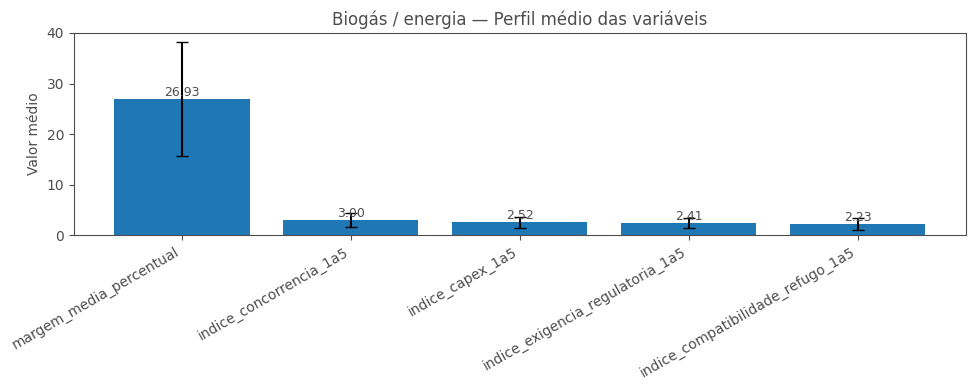

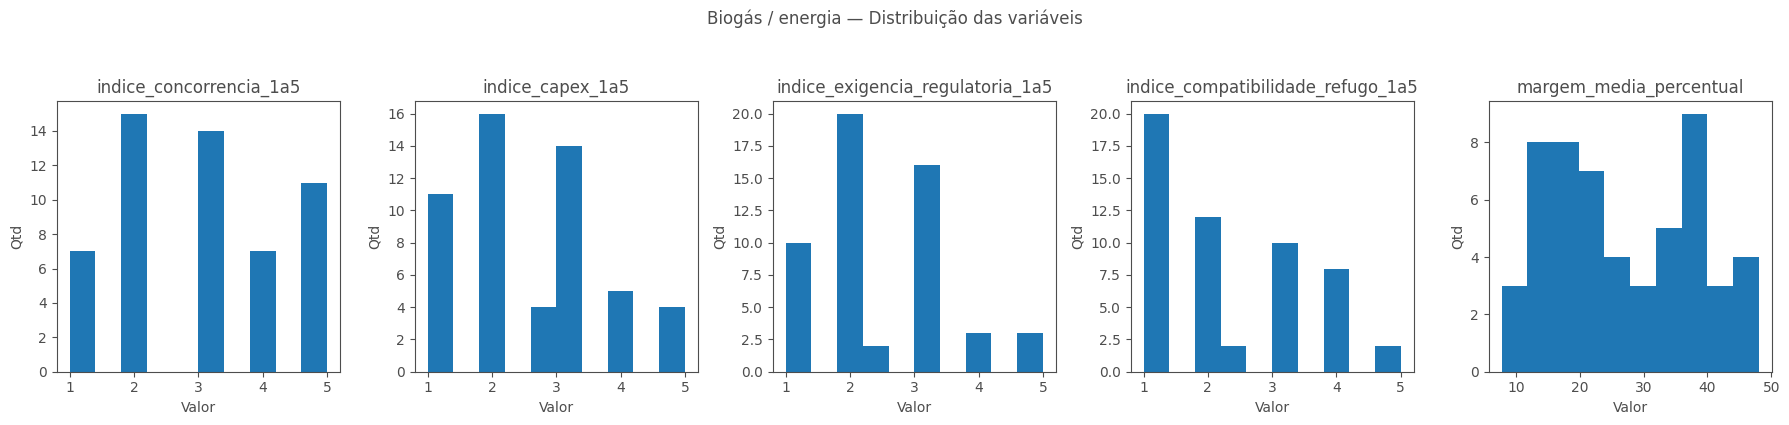

C:\Users\joaop\AppData\Local\Temp\ipykernel_40616\2704652.py:100: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


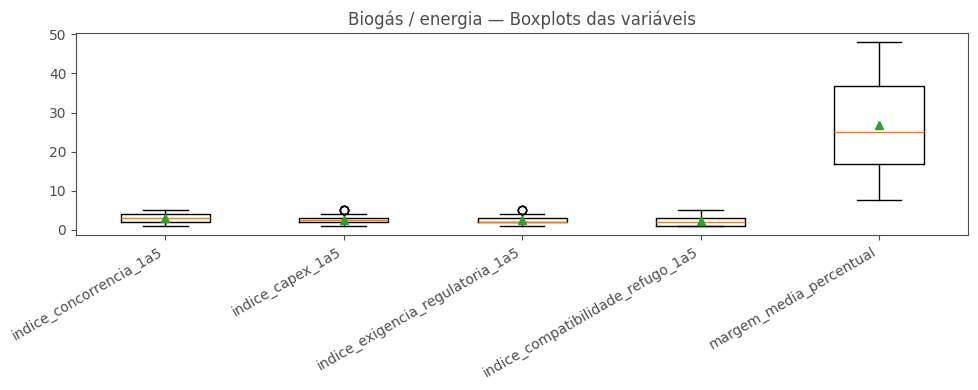


--- Insights automáticos ---
Maiores médias:
 • margem_media_percentual: 26.93
 • indice_concorrencia_1a5: 3.00
 • indice_capex_1a5: 2.52
Menores médias:
 • indice_capex_1a5: 2.52
 • indice_exigencia_regulatoria_1a5: 2.41
 • indice_compatibilidade_refugo_1a5: 2.23

Maior variabilidade (desvio padrão):
 • margem_media_percentual: 11.20
 • indice_concorrencia_1a5: 1.33
 • indice_compatibilidade_refugo_1a5: 1.21

✅ Fim da análise.


ANÁLISE INDIVIDUAL — Fragrância para perfumaria
Registros encontrados: 47 (2.93% do dataset)

--- Estatísticas descritivas ---
                                   count   mean   std   min    25%    50%  \
indice_concorrencia_1a5             47.0   2.83  1.13  1.00   2.00   3.00   
indice_capex_1a5                    47.0   2.78  1.20  1.00   2.00   3.00   
indice_exigencia_regulatoria_1a5    47.0   2.93  1.24  1.00   2.00   3.00   
indice_compatibilidade_refugo_1a5   47.0   2.14  1.31  1.00   1.00   1.00   
margem_media_percentual             47.0  26.92  9.13

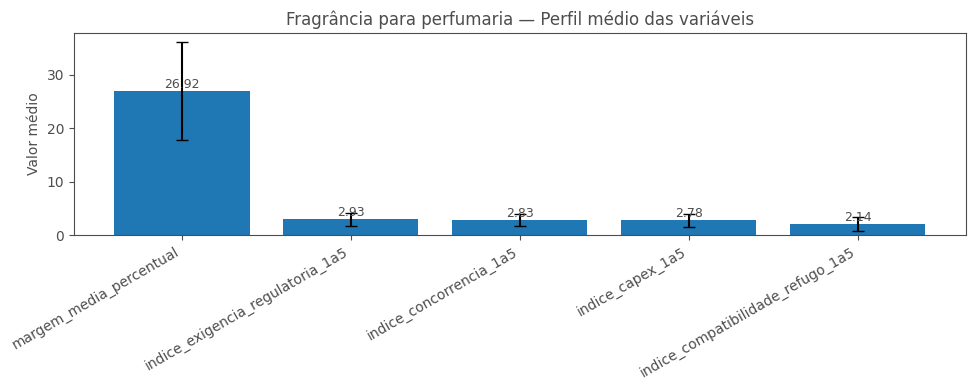

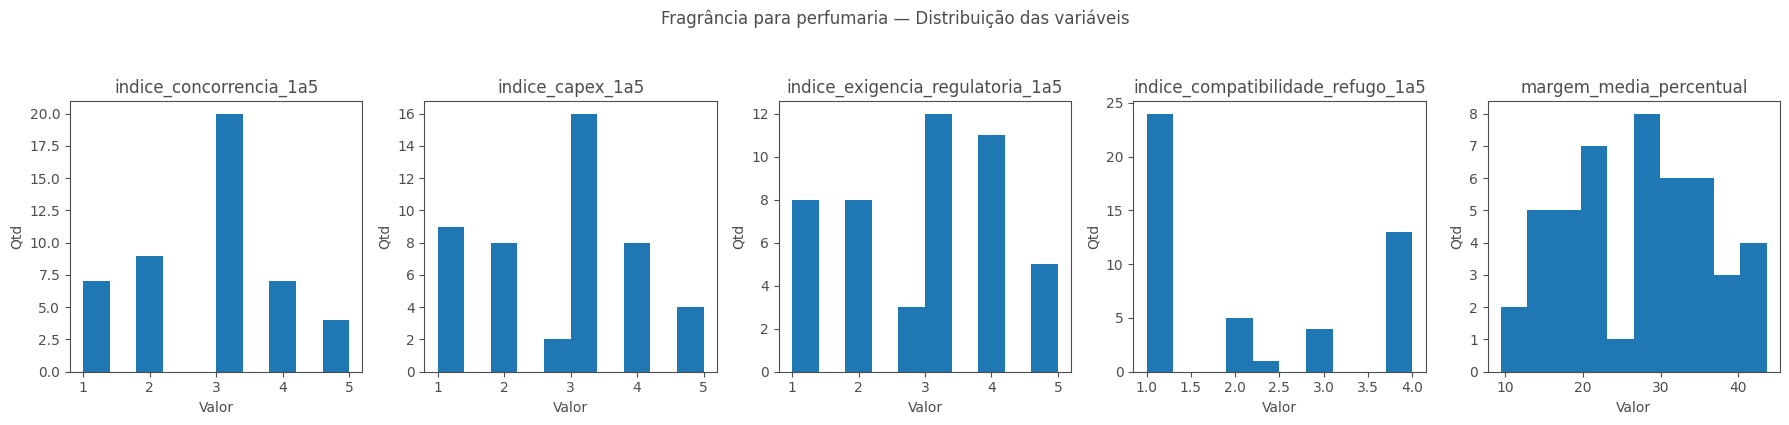

C:\Users\joaop\AppData\Local\Temp\ipykernel_40616\2704652.py:100: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


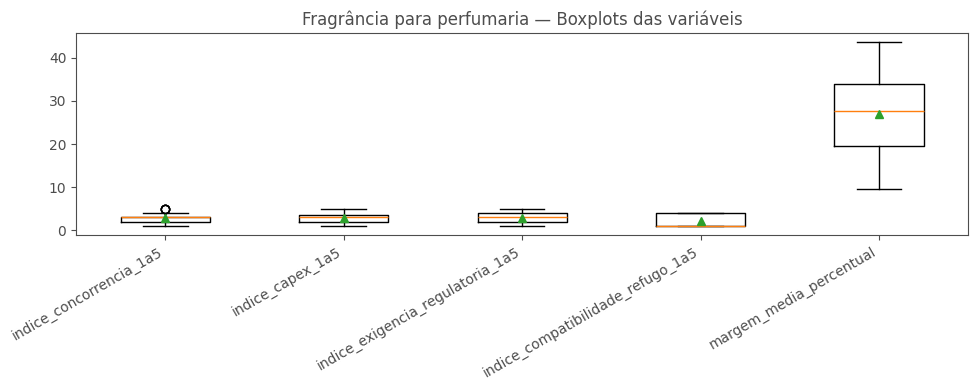


--- Insights automáticos ---
Maiores médias:
 • margem_media_percentual: 26.92
 • indice_exigencia_regulatoria_1a5: 2.93
 • indice_concorrencia_1a5: 2.83
Menores médias:
 • indice_concorrencia_1a5: 2.83
 • indice_capex_1a5: 2.78
 • indice_compatibilidade_refugo_1a5: 2.14

Maior variabilidade (desvio padrão):
 • margem_media_percentual: 9.13
 • indice_compatibilidade_refugo_1a5: 1.31
 • indice_exigencia_regulatoria_1a5: 1.24

✅ Fim da análise.


ANÁLISE INDIVIDUAL — Pó de manga (spray-dried)
Registros encontrados: 67 (4.17% do dataset)

--- Estatísticas descritivas ---
                                   count   mean    std   min    25%    50%  \
indice_concorrencia_1a5             67.0   3.00   1.02  1.00   2.00   3.00   
indice_capex_1a5                    67.0   3.06   1.16  1.00   2.00   3.00   
indice_exigencia_regulatoria_1a5    67.0   2.45   1.06  1.00   2.00   2.00   
indice_compatibilidade_refugo_1a5   67.0   2.25   1.29  1.00   1.00   2.00   
margem_media_percentual           

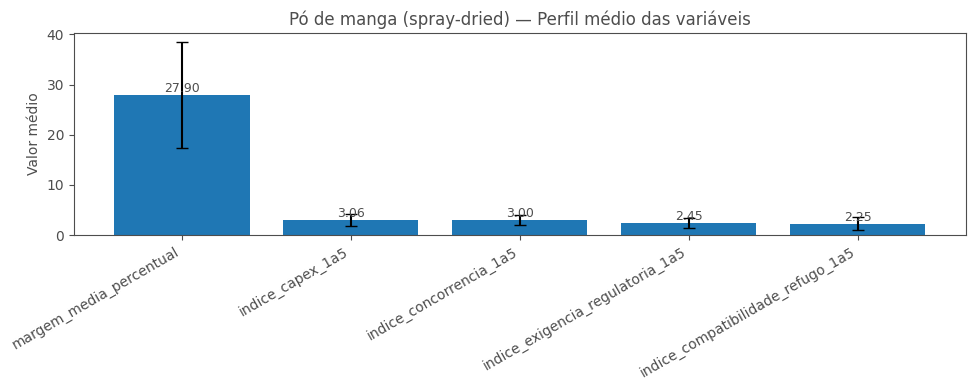

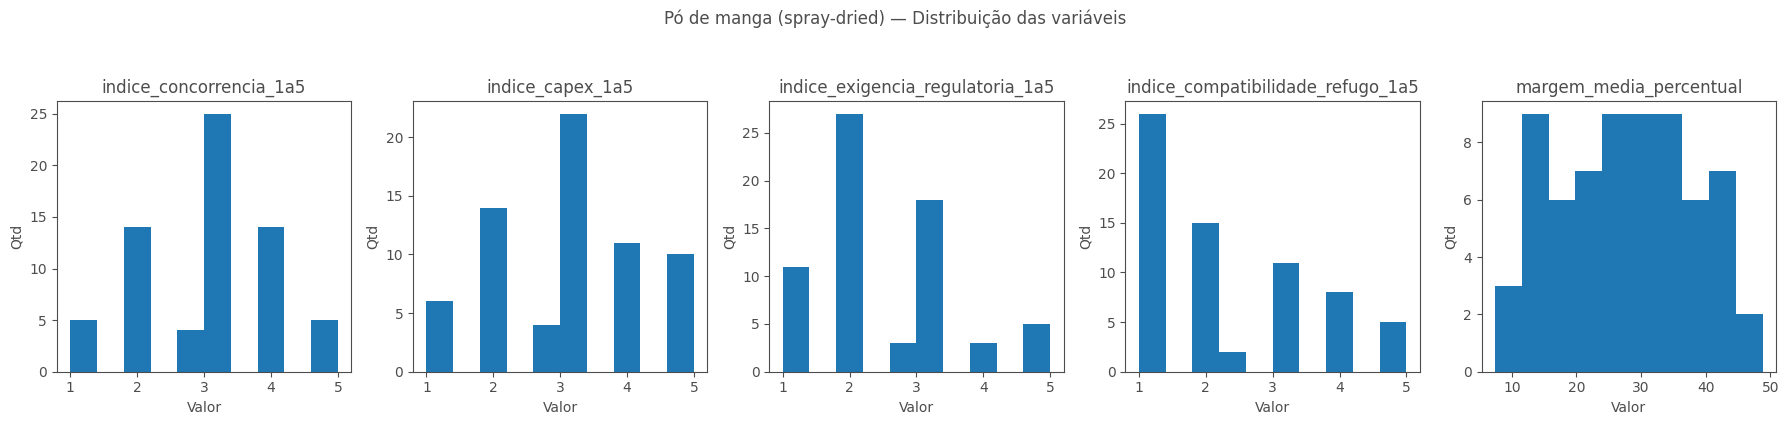

C:\Users\joaop\AppData\Local\Temp\ipykernel_40616\2704652.py:100: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


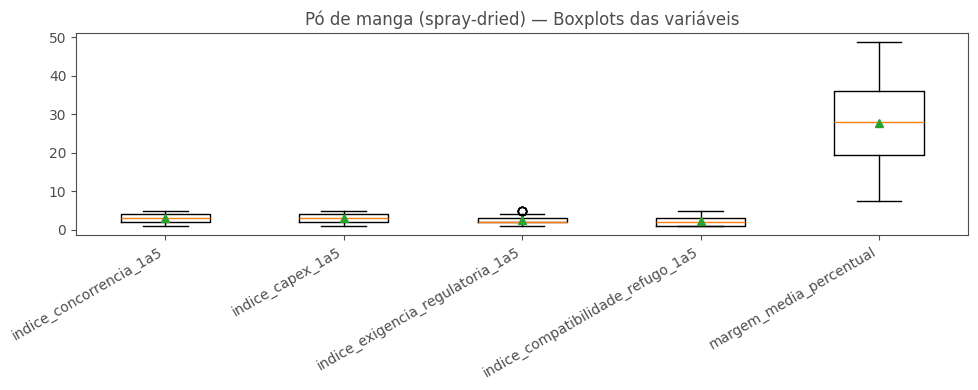


--- Insights automáticos ---
Maiores médias:
 • margem_media_percentual: 27.90
 • indice_capex_1a5: 3.06
 • indice_concorrencia_1a5: 3.00
Menores médias:
 • indice_concorrencia_1a5: 3.00
 • indice_exigencia_regulatoria_1a5: 2.45
 • indice_compatibilidade_refugo_1a5: 2.25

Maior variabilidade (desvio padrão):
 • margem_media_percentual: 10.49
 • indice_compatibilidade_refugo_1a5: 1.29
 • indice_capex_1a5: 1.16

✅ Fim da análise.



In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import unicodedata

# ============================================================
# CONFIGURAÇÕES
# ============================================================
col_produto = "produto"

features = [
    "indice_concorrencia_1a5",
    "indice_capex_1a5",
    "indice_exigencia_regulatoria_1a5",
    "indice_compatibilidade_refugo_1a5",
    "margem_media_percentual",
]

produtos = [
    "Snack de manga desidratada",
    "Suco pronto (NFC)",
    "Sorbet / picolé",
    "Biogás / energia",
    "Fragrância para perfumaria",
    "Pó de manga (spray-dried)",
]

# ============================================================
# FUNÇÕES AUXILIARES
# ============================================================
def normalizar_texto(s):
    if pd.isna(s):
        return ""
    s = str(s).strip().lower()
    s = unicodedata.normalize("NFKD", s)
    s = "".join(c for c in s if not unicodedata.combining(c))
    return " ".join(s.split())

def filtrar_produto(df, nome):
    alvo = normalizar_texto(nome)
    serie = df[col_produto].astype(str).map(normalizar_texto)
    return df.loc[serie == alvo].copy()

# ============================================================
# ANÁLISE INDIVIDUAL POR PRODUTO
# ============================================================
def analisar_produto(df, produto):
    sub = filtrar_produto(df, produto)
    n = len(sub)

    print("\n" + "="*80)
    print(f"ANÁLISE INDIVIDUAL — {produto}")
    print("="*80)
    print(f"Registros encontrados: {n} ({(n/len(df)*100):.2f}% do dataset)")

    if n == 0:
        print("⚠️ Produto não encontrado no dataset.")
        return

    # -------------------------
    # 1) Estatísticas
    # -------------------------
    stats = sub[features].describe().T.round(2)
    print("\n--- Estatísticas descritivas ---")
    print(stats)

    # -------------------------
    # 2) Perfil médio (barra)
    # -------------------------
    medias = sub[features].mean().sort_values(ascending=False)
    stds = sub[features].std().reindex(medias.index)

    plt.figure(figsize=(10, 4))
    plt.bar(medias.index, medias.values, yerr=stds.values, capsize=4)
    plt.title(f"{produto} — Perfil médio das variáveis")
    plt.ylabel("Valor médio")
    plt.xticks(rotation=30, ha="right")
    for i, v in enumerate(medias.values):
        plt.text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=9)
    plt.tight_layout()
    plt.show()

    # -------------------------
    # 3) Histogramas
    # -------------------------
    fig, axes = plt.subplots(1, len(features), figsize=(18, 4))
    for ax, col in zip(axes, features):
        ax.hist(sub[col].dropna(), bins=10)
        ax.set_title(col)
        ax.set_xlabel("Valor")
        ax.set_ylabel("Qtd")
    plt.suptitle(f"{produto} — Distribuição das variáveis", y=1.05)
    plt.tight_layout()
    plt.show()

    # -------------------------
    # 4) Boxplots
    # -------------------------
    plt.figure(figsize=(10, 4))
    plt.boxplot(
        [sub[c].dropna() for c in features],
        labels=features,
        showmeans=True
    )
    plt.title(f"{produto} — Boxplots das variáveis")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

    # -------------------------
    # 5) Insights automáticos
    # -------------------------
    print("\n--- Insights automáticos ---")
    print("Maiores médias:")
    for k, v in medias.head(3).items():
        print(f" • {k}: {v:.2f}")

    print("Menores médias:")
    for k, v in medias.tail(3).items():
        print(f" • {k}: {v:.2f}")

    print("\nMaior variabilidade (desvio padrão):")
    for k, v in stds.sort_values(ascending=False).head(3).items():
        print(f" • {k}: {v:.2f}")

    print("\n✅ Fim da análise.\n")

# ============================================================
# EXECUÇÃO
# ============================================================
for produto in produtos:
    analisar_produto(df, produto)



TABELA COMPARATIVA — MÉDIAS POR PRODUTO

                                     n_registros  indice_concorrencia_1a5  \
produto                                                                     
Polpa congelada                               60                     2.63   
Óleo / manteiga de semente de manga           51                     3.09   
Snack de manga desidratada                    52                     2.84   
Suco pronto (NFC)                             52                     2.78   
Sorbet / picolé                               70                     2.78   
Biogás / energia                              54                     3.00   
Fragrância para perfumaria                    47                     2.83   
Pó de manga (spray-dried)                     67                     3.00   

                                     indice_capex_1a5  \
produto                                                 
Polpa congelada                                  2.97   
Óleo / manteiga 

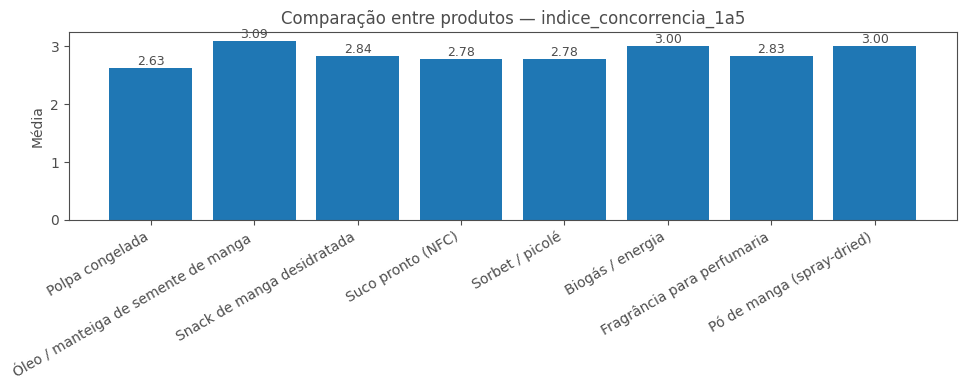

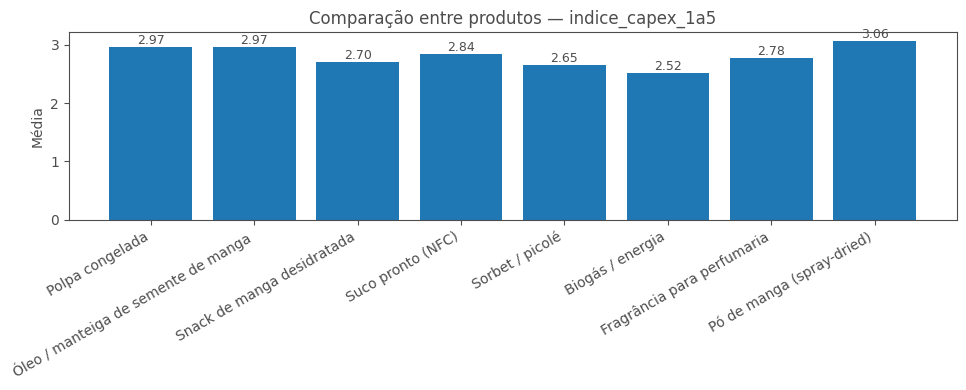

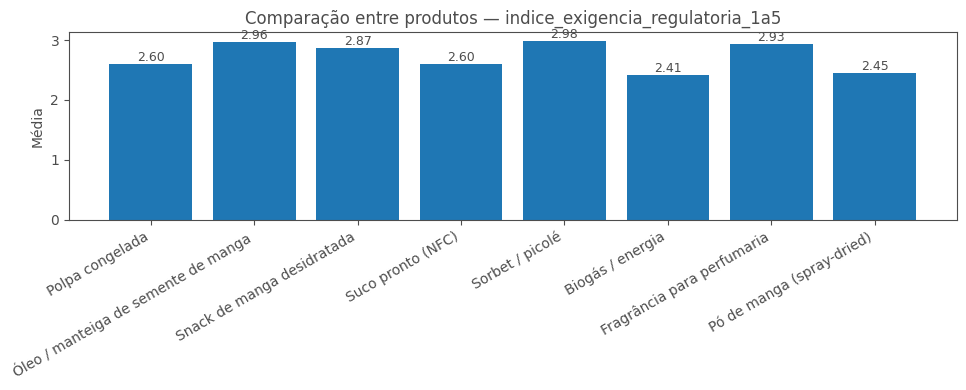

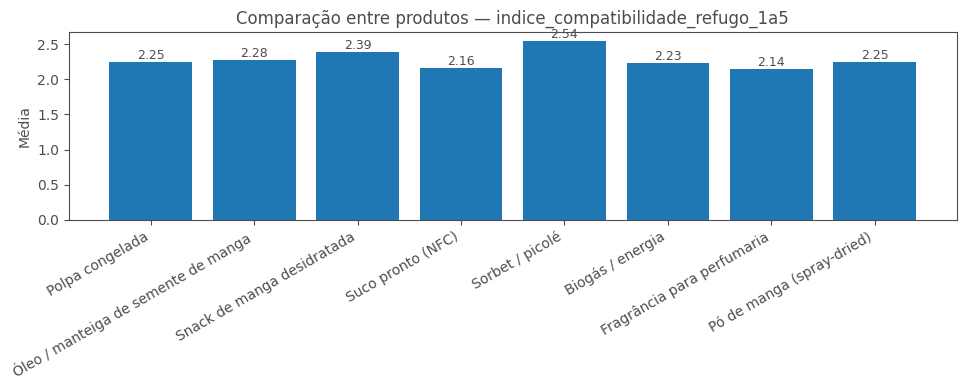

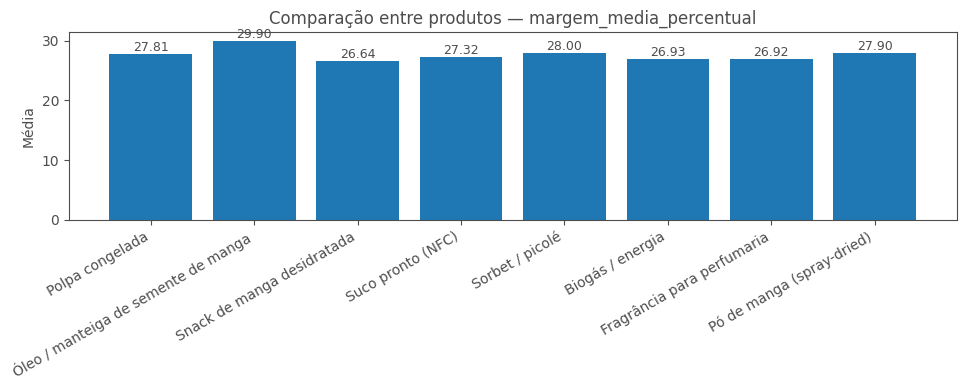

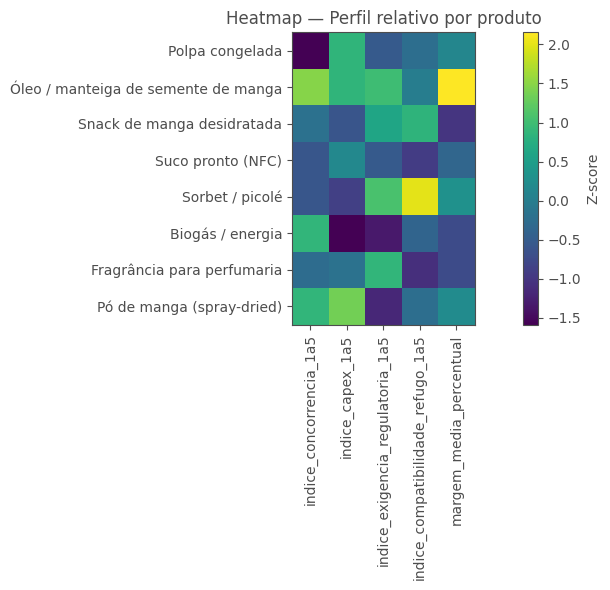

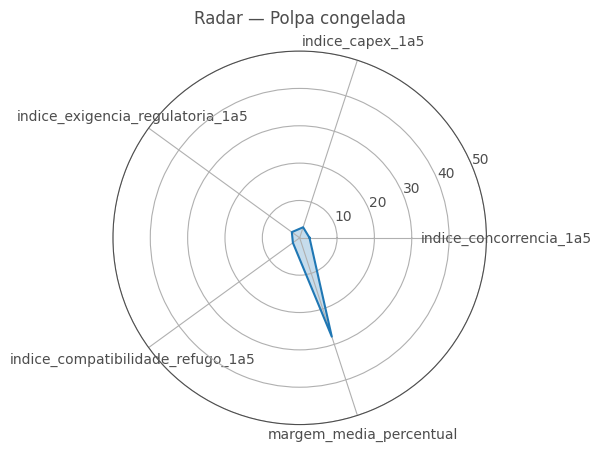

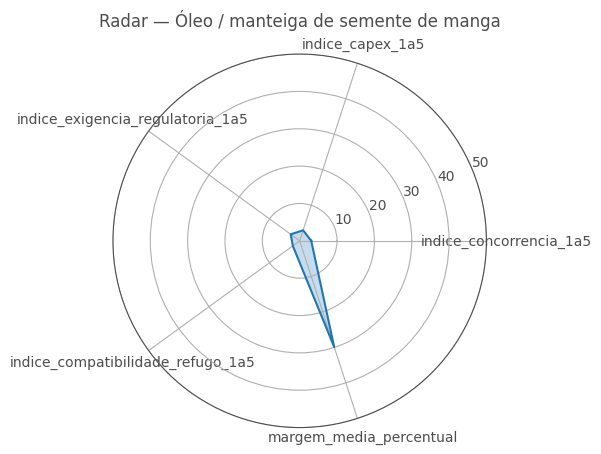

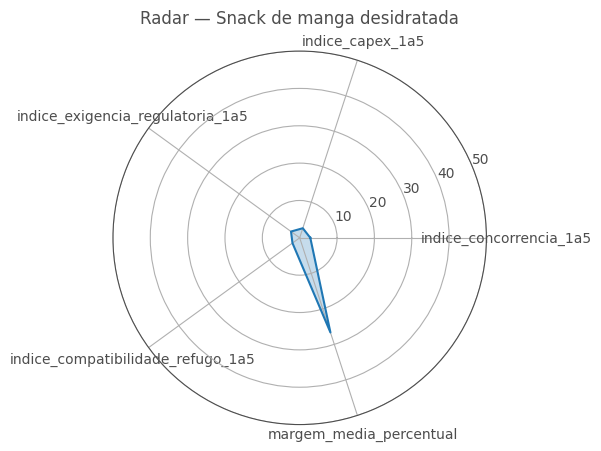

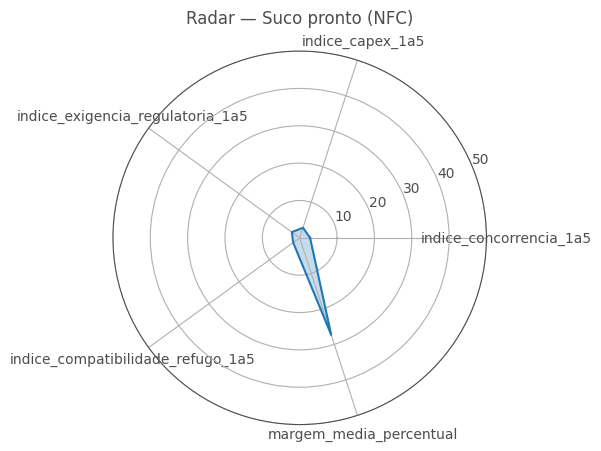

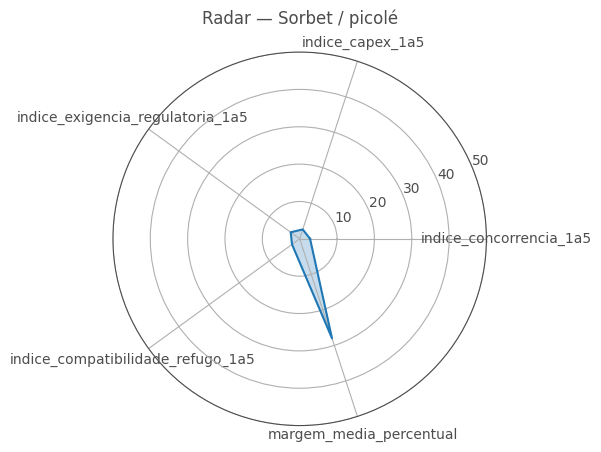

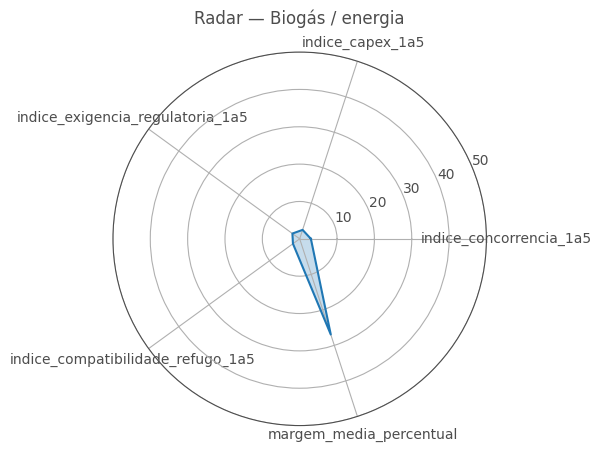

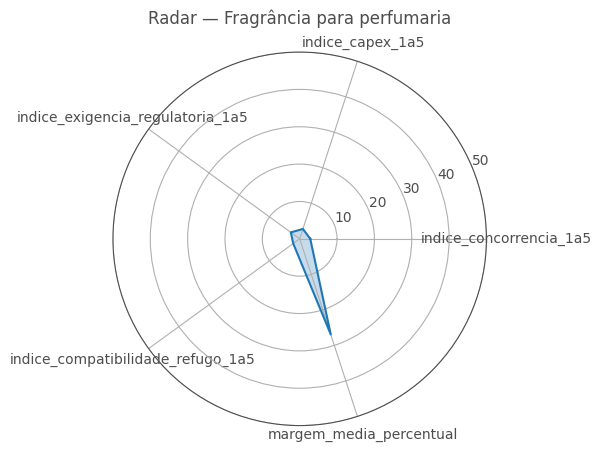

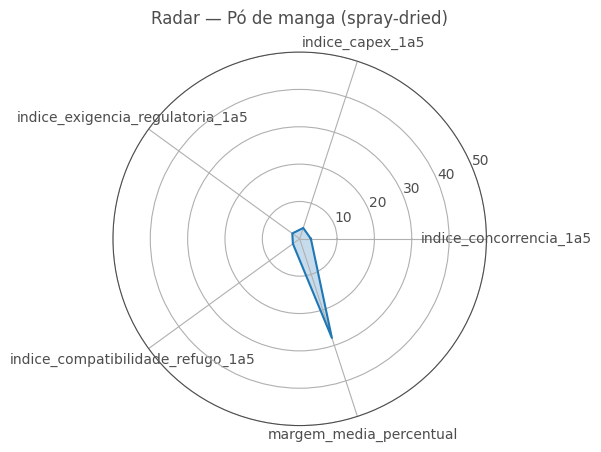

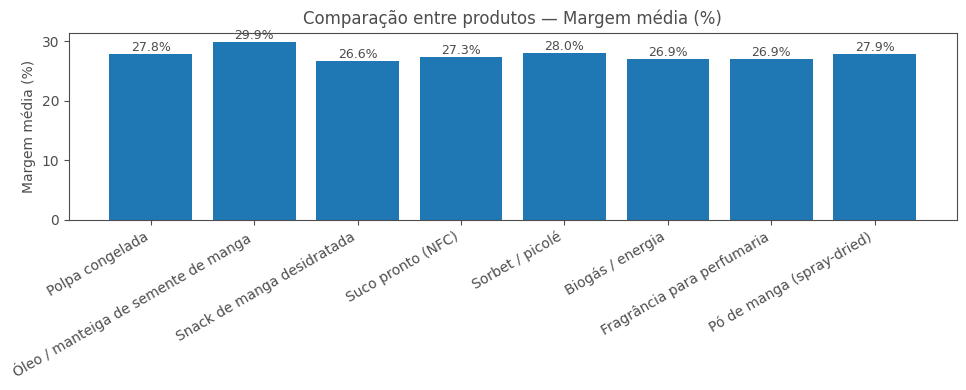


RANKINGS POR MÉTRICA


▶ indice_concorrencia_1a5
Top 3:
produto
Óleo / manteiga de semente de manga    3.09
Biogás / energia                       3.00
Pó de manga (spray-dried)              3.00
Name: indice_concorrencia_1a5, dtype: float64
Bottom 3:
produto
Polpa congelada      2.63
Suco pronto (NFC)    2.78
Sorbet / picolé      2.78
Name: indice_concorrencia_1a5, dtype: float64

▶ indice_capex_1a5
Top 3:
produto
Pó de manga (spray-dried)              3.06
Polpa congelada                        2.97
Óleo / manteiga de semente de manga    2.97
Name: indice_capex_1a5, dtype: float64
Bottom 3:
produto
Biogás / energia              2.52
Sorbet / picolé               2.65
Snack de manga desidratada    2.70
Name: indice_capex_1a5, dtype: float64

▶ indice_exigencia_regulatoria_1a5
Top 3:
produto
Sorbet / picolé                        2.98
Óleo / manteiga de semente de manga    2.96
Fragrância para perfumaria             2.93
Name: indice_exigencia_regulatoria_1a5, dtype: float64
Bottom 3:

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import unicodedata

# ============================================================
# CONFIG
# ============================================================
col_produto = "produto"

features = [
    "indice_concorrencia_1a5",
    "indice_capex_1a5",
    "indice_exigencia_regulatoria_1a5",
    "indice_compatibilidade_refugo_1a5",
    "margem_media_percentual",
]

produtos = [
    "Polpa congelada",
    "Óleo / manteiga de semente de manga",
    "Snack de manga desidratada",
    "Suco pronto (NFC)",
    "Sorbet / picolé",
    "Biogás / energia",
    "Fragrância para perfumaria",
    "Pó de manga (spray-dried)",
]

# ============================================================
# HELPERS
# ============================================================
def normalizar_texto(s):
    if pd.isna(s):
        return ""
    s = str(s).strip().lower()
    s = unicodedata.normalize("NFKD", s)
    s = "".join(c for c in s if not unicodedata.combining(c))
    return " ".join(s.split())

df["_produto_norm"] = df[col_produto].astype(str).map(normalizar_texto)

produtos_norm = {p: normalizar_texto(p) for p in produtos}

# ============================================================
# 1) TABELA COMPARATIVA DE MÉDIAS
# ============================================================
comparativo = []

for nome, norm in produtos_norm.items():
    sub = df[df["_produto_norm"] == norm]
    if len(sub) == 0:
        continue

    row = {"produto": nome, "n_registros": len(sub)}
    for f in features:
        row[f] = sub[f].mean()
    comparativo.append(row)

df_comp = pd.DataFrame(comparativo).set_index("produto")
df_comp = df_comp.round(2)

print("\n==============================")
print("TABELA COMPARATIVA — MÉDIAS POR PRODUTO")
print("==============================\n")
print(df_comp)

# ============================================================
# 2) BARRAS COMPARATIVAS (1 gráfico por feature)
# ============================================================
for col in features:
    plt.figure(figsize=(10, 4))
    plt.bar(df_comp.index, df_comp[col])
    plt.title(f"Comparação entre produtos — {col}")
    plt.ylabel("Média")
    plt.xticks(rotation=30, ha="right")
    for i, v in enumerate(df_comp[col]):
        plt.text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=9)
    plt.tight_layout()
    plt.show()

# ============================================================
# 3) HEATMAP (perfil relativo por produto)
# ============================================================
zscore = (df_comp[features] - df_comp[features].mean()) / df_comp[features].std()

plt.figure(figsize=(10, 6))
plt.imshow(zscore.values)
plt.colorbar(label="Z-score")
plt.xticks(range(len(features)), features, rotation=90)
plt.yticks(range(len(df_comp.index)), df_comp.index)
plt.title("Heatmap — Perfil relativo por produto")
plt.tight_layout()
plt.show()

# ============================================================
# 4) RADAR CHART (um por produto)
# ============================================================
labels = features
angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

for produto in df_comp.index:
    values = df_comp.loc[produto, features].values.tolist()
    values += values[:1]

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
    ax.plot(angles, values)
    ax.fill(angles, values, alpha=0.25)
    ax.set_thetagrids(np.degrees(angles[:-1]), labels)
    ax.set_ylim(0, max(50, df_comp["margem_media_percentual"].max() * 1.1))
    ax.set_title(f"Radar — {produto}", pad=20)
    plt.tight_layout()
    plt.show()

# ============================================================
# 5) COMPARAÇÃO DIRETA DE MARGEM
# ============================================================
plt.figure(figsize=(10, 4))
plt.bar(df_comp.index, df_comp["margem_media_percentual"])
plt.title("Comparação entre produtos — Margem média (%)")
plt.ylabel("Margem média (%)")
plt.xticks(rotation=30, ha="right")
for i, v in enumerate(df_comp["margem_media_percentual"]):
    plt.text(i, v, f"{v:.1f}%", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

# ============================================================
# 6) RANKINGS AUTOMÁTICOS
# ============================================================
print("\n==============================")
print("RANKINGS POR MÉTRICA")
print("==============================\n")

for col in features:
    print(f"\n▶ {col}")
    print("Top 3:")
    print(df_comp[col].sort_values(ascending=False).head(3))
    print("Bottom 3:")
    print(df_comp[col].sort_values(ascending=True).head(3))

print("\n✅ Análise comparativa finalizada.")


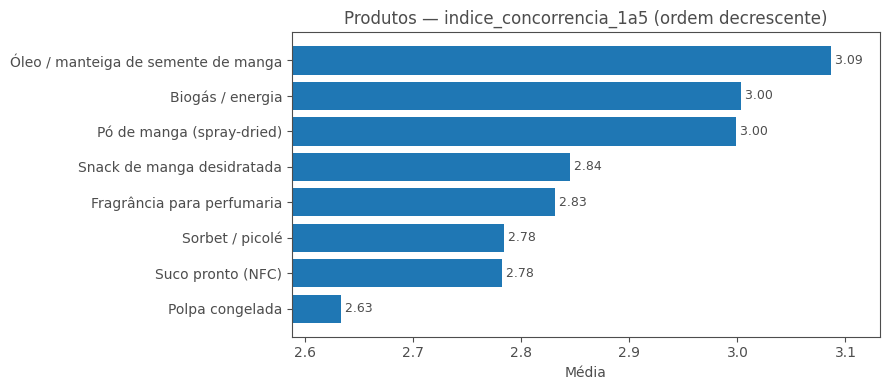

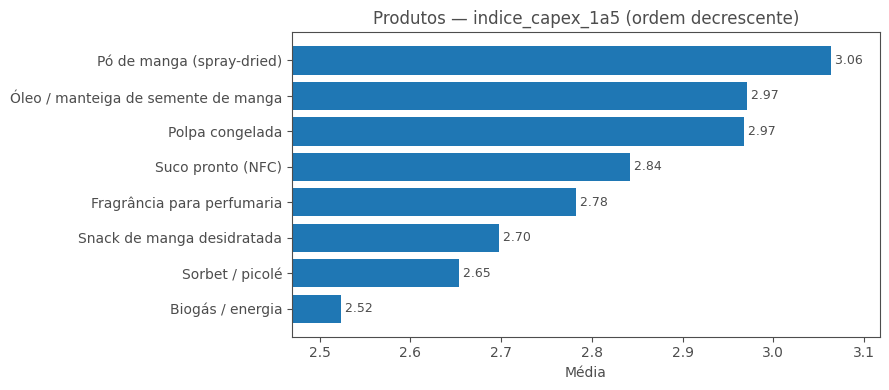

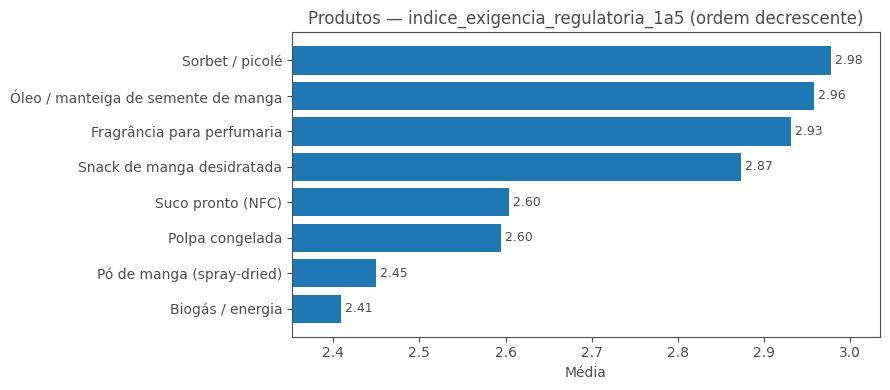

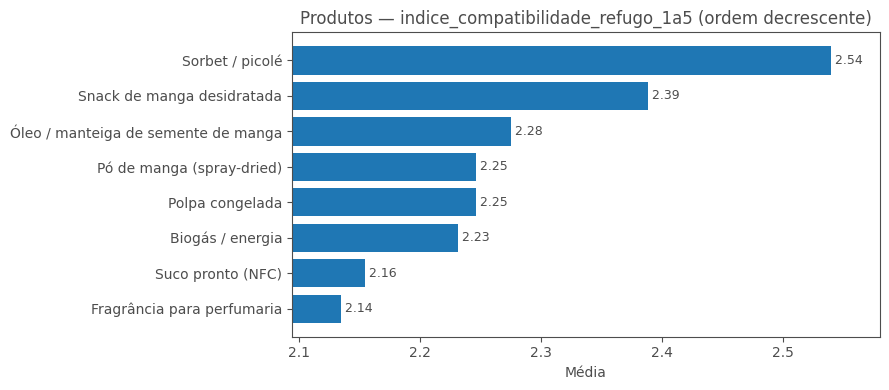

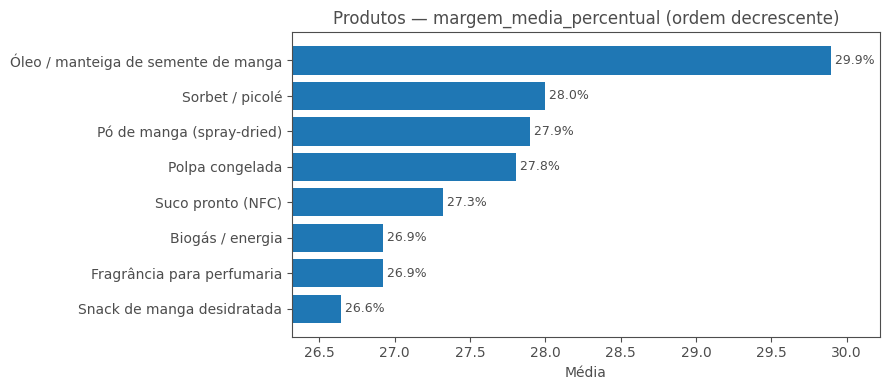

✅ Gráficos com DeltaX reduzido gerados.


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import unicodedata

# ============================================================
# CONFIG
# ============================================================
col_produto = "produto"

features = [
    "indice_concorrencia_1a5",
    "indice_capex_1a5",
    "indice_exigencia_regulatoria_1a5",
    "indice_compatibilidade_refugo_1a5",
    "margem_media_percentual",
]

produtos = [
    "Polpa congelada",
    "Óleo / manteiga de semente de manga",
    "Snack de manga desidratada",
    "Suco pronto (NFC)",
    "Sorbet / picolé",
    "Biogás / energia",
    "Fragrância para perfumaria",
    "Pó de manga (spray-dried)",
]

# ============================================================
# HELPERS
# ============================================================
def normalizar_texto(s):
    if pd.isna(s):
        return ""
    s = str(s).strip().lower()
    s = unicodedata.normalize("NFKD", s)
    s = "".join(c for c in s if not unicodedata.combining(c))
    return " ".join(s.split())

df["_produto_norm"] = df[col_produto].astype(str).map(normalizar_texto)
produtos_norm = {p: normalizar_texto(p) for p in produtos}

# ============================================================
# LOOP — BARH COM DELTAX AJUSTADO
# ============================================================
for feature in features:
    dados = []

    for nome, norm in produtos_norm.items():
        sub = df[df["_produto_norm"] == norm]
        if len(sub) == 0 or feature not in sub.columns:
            continue
        dados.append({
            "produto": nome,
            "valor": sub[feature].mean()
        })

    df_plot = pd.DataFrame(dados).dropna()

    if df_plot.empty:
        continue

    # ordena (decrescente visual = crescente no barh)
    df_plot = df_plot.sort_values("valor", ascending=True)

    # -----------------------------
    # AJUSTE DO DELTAX (ZOOM)
    # -----------------------------
    vmin = df_plot["valor"].min()
    vmax = df_plot["valor"].max()
    padding = (vmax - vmin) * 0.10 if vmax > vmin else 0.2

    x_min = vmin - padding
    x_max = vmax + padding

    # -----------------------------
    # PLOT
    # -----------------------------
    plt.figure(figsize=(9, 4))
    plt.barh(df_plot["produto"], df_plot["valor"])
    plt.title(f"Produtos — {feature} (ordem decrescente)")
    plt.xlabel("Média")
    plt.xlim(x_min, x_max)

    for i, v in enumerate(df_plot["valor"]):
        label = f"{v:.2f}" if feature != "margem_media_percentual" else f"{v:.1f}%"
        plt.text(v, i, f" {label}", va="center", fontsize=9)

    plt.tight_layout()
    plt.show()

print("✅ Gráficos com DeltaX reduzido gerados.")



================ FATURAMENTO POR PRODUTO ================

                                     count        median          mean  \
produto                                                                  
Biogás / energia                        54  1.800000e+10  5.651132e+10   
Óleo / manteiga de semente de manga     51  1.800000e+10  5.323060e+10   
Polpa congelada                         60  1.350000e+10  4.228759e+10   
Fragrância para perfumaria              47  9.000000e+09  6.825085e+10   
Suco pronto (NFC)                       52  9.000000e+09  3.983700e+10   
Snack de manga desidratada              52  9.000000e+09  4.616314e+10   
Pó de manga (spray-dried)               67  4.200000e+09  3.232190e+10   
Sorbet / picolé                         70  4.200000e+09  3.888397e+10   

                                              std  
produto                                            
Biogás / energia                     9.847074e+10  
Óleo / manteiga de semente de manga  8.9100

C:\Users\joaop\AppData\Local\Temp\ipykernel_40616\3001656381.py:64: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


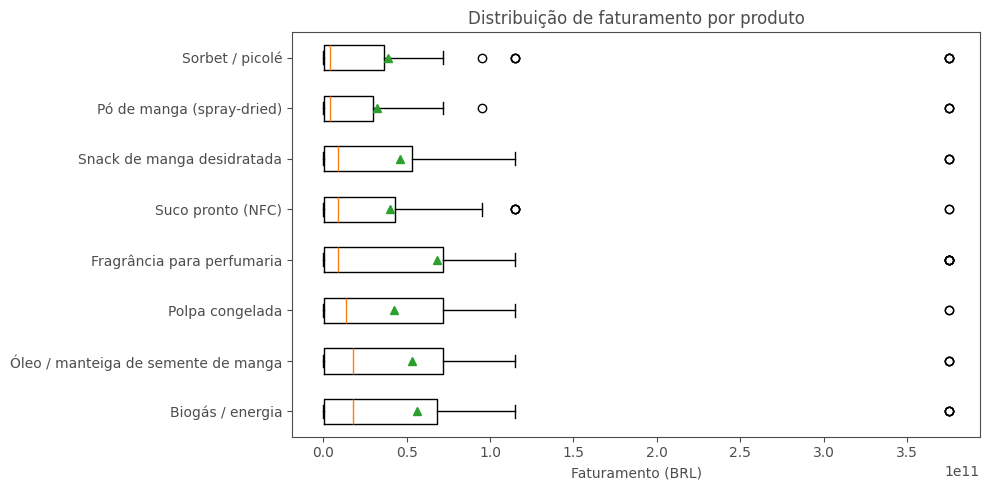


================ TIPO DE CLIENTE (%) ================

produto                              produto                              tipo_cliente
Biogás / energia                     Biogás / energia                     B2B             68.5
                                                                          B2C             31.5
Fragrância para perfumaria           Fragrância para perfumaria           B2B             83.0
                                                                          B2C             17.0
Polpa congelada                      Polpa congelada                      B2B             76.7
                                                                          B2C             23.3
Pó de manga (spray-dried)            Pó de manga (spray-dried)            B2B             80.6
                                                                          B2C             19.4
Snack de manga desidratada           Snack de manga desidratada           B2B             76.9
  

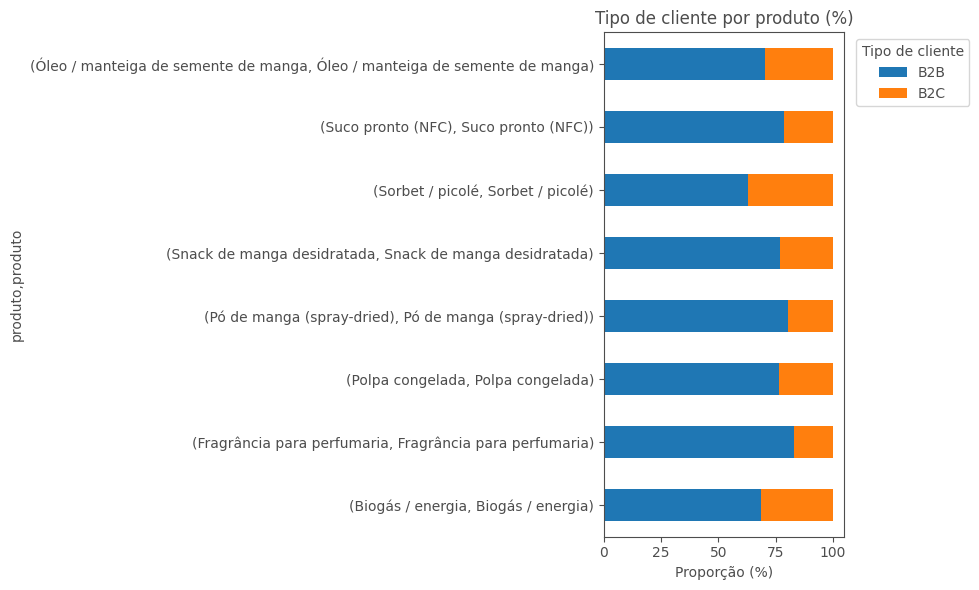


================ MERCADO PRINCIPAL (%) ================

produto                              produto                              mercado_principal
Biogás / energia                     Biogás / energia                     Ambos                25.9
                                                                          Externo              29.6
                                                                          Interno              44.4
Fragrância para perfumaria           Fragrância para perfumaria           Ambos                40.4
                                                                          Externo              17.0
                                                                          Interno              42.6
Polpa congelada                      Polpa congelada                      Ambos                30.0
                                                                          Externo              16.7
                                                  

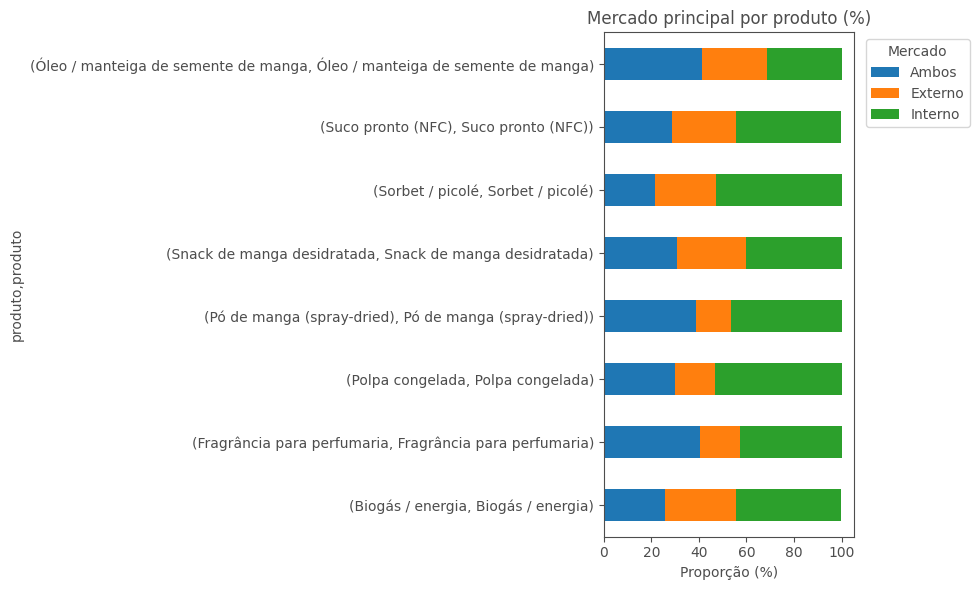


================ RESUMO PARA JUSTIFICATIVAS ================

                                     faturamento_mediano  faturamento_medio  \
produto                                                                       
Biogás / energia                            1.800000e+10       5.651132e+10   
Óleo / manteiga de semente de manga         1.800000e+10       5.323060e+10   
Polpa congelada                             1.350000e+10       4.228759e+10   
Fragrância para perfumaria                  9.000000e+09       6.825085e+10   
Suco pronto (NFC)                           9.000000e+09       3.983700e+10   
Snack de manga desidratada                  9.000000e+09       4.616314e+10   
Pó de manga (spray-dried)                   4.200000e+09       3.232190e+10   
Sorbet / picolé                             4.200000e+09       3.888397e+10   

                                     pct_b2b  pct_b2c  pct_externo  \
produto                                                              
Biogás

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import unicodedata

# ============================================================
# CONFIG
# ============================================================
produtos = [
    "Polpa congelada",
    "Óleo / manteiga de semente de manga",
    "Snack de manga desidratada",
    "Suco pronto (NFC)",
    "Sorbet / picolé",
    "Biogás / energia",
    "Fragrância para perfumaria",
    "Pó de manga (spray-dried)",
]

col_produto = "produto"
features_mercado = [
    "faturamento_empresa_brl",
    "tipo_cliente",
    "mercado_principal",
]

# ============================================================
# HELPERS
# ============================================================
def normalizar_texto(s):
    if s is None:
        return ""
    s = str(s).strip().lower()
    s = unicodedata.normalize("NFKD", s)
    s = "".join(c for c in s if not unicodedata.combining(c))
    return " ".join(s.split())

def filtrar_produtos(df, produtos):
    alvo = [normalizar_texto(p) for p in produtos]
    serie_norm = df[col_produto].astype(str).map(normalizar_texto)
    return df[serie_norm.isin(alvo)].copy()

# ============================================================
# BASE FILTRADA
# ============================================================
df_prod = filtrar_produtos(df, produtos)

# ============================================================
# 1) FATURAMENTO — DISTRIBUIÇÃO E ESTATÍSTICAS
# ============================================================
print("\n================ FATURAMENTO POR PRODUTO ================\n")

stats_fat = (
    df_prod
    .groupby(col_produto)["faturamento_empresa_brl"]
    .agg(["count", "median", "mean", "std"])
    .sort_values("median", ascending=False)
    .round(2)
)

print(stats_fat)

plt.figure(figsize=(10, 5))
plt.boxplot(
    [df_prod[df_prod[col_produto] == p]["faturamento_empresa_brl"].dropna() for p in stats_fat.index],
    labels=stats_fat.index,
    vert=False,
    showmeans=True
)
plt.title("Distribuição de faturamento por produto")
plt.xlabel("Faturamento (BRL)")
plt.tight_layout()
plt.show()

# ============================================================
# 2) TIPO DE CLIENTE — PERFIL DE MERCADO
# ============================================================
print("\n================ TIPO DE CLIENTE (%) ================\n")

tipo_cliente_pct = (
    df_prod
    .groupby([col_produto, "tipo_cliente"])
    .size()
    .groupby(level=0)
    .apply(lambda x: 100 * x / x.sum())
    .round(1)
)

print(tipo_cliente_pct)

fig, ax = plt.subplots(figsize=(10, 6))

tipo_cliente_pct.unstack(fill_value=0).plot(
    kind="barh",
    stacked=True,
    ax=ax
)

ax.set_title("Tipo de cliente por produto (%)")
ax.set_xlabel("Proporção (%)")
ax.legend(title="Tipo de cliente", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

# ============================================================
# 3) MERCADO PRINCIPAL — INTERNO vs EXTERNO
# ============================================================
print("\n================ MERCADO PRINCIPAL (%) ================\n")

mercado_pct = (
    df_prod
    .groupby([col_produto, "mercado_principal"])
    .size()
    .groupby(level=0)
    .apply(lambda x: 100 * x / x.sum())
    .round(1)
)

print(mercado_pct)

fig, ax = plt.subplots(figsize=(10, 6))

mercado_pct.unstack(fill_value=0).plot(
    kind="barh",
    stacked=True,
    ax=ax
)

ax.set_title("Mercado principal por produto (%)")
ax.set_xlabel("Proporção (%)")
ax.legend(title="Mercado", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

# ============================================================
# 4) TABELA FINAL — BASE PARA JUSTIFICATIVAS
# ============================================================
print("\n================ RESUMO PARA JUSTIFICATIVAS ================\n")

resumo = (
    df_prod
    .groupby(col_produto)
    .agg(
        faturamento_mediano=("faturamento_empresa_brl", "median"),
        faturamento_medio=("faturamento_empresa_brl", "mean"),
        pct_b2b=("tipo_cliente", lambda x: (x == "B2B").mean() * 100),
        pct_b2c=("tipo_cliente", lambda x: (x == "B2C").mean() * 100),
        pct_externo=("mercado_principal", lambda x: (x == "Externo").mean() * 100),
        pct_interno=("mercado_principal", lambda x: (x == "Interno").mean() * 100),
    )
    .round(1)
    .sort_values("faturamento_mediano", ascending=False)
)

print(resumo)


EVIDÊNCIAS NA BASE — Produtos escolhidos
produto
Polpa congelada                        60
Óleo / manteiga de semente de manga    51
Name: count, dtype: int64

------------------------------------------------------------------------------------------
CONCEITO DA TABELA: Investimento Necessário
FEATURE(S) USADA(S) NA BASE: ['indice_capex_1a5']
------------------------------------------------------------------------------------------

[Resumo por produto] -> indice_capex_1a5
                            produto  count  mean  median   std  min  max
                    Polpa congelada     60 2.968   2.908 1.201  1.0  5.0
Óleo / manteiga de semente de manga     51 2.971   3.000 1.208  1.0  5.0

[Ranking] Percentil do mean (vs dataset inteiro) -> indice_capex_1a5
                            produto  percentil_do_mean_no_dataset
                    Polpa congelada                          45.8
Óleo / manteiga de semente de manga                          45.8

[Classificação automática (tercis 

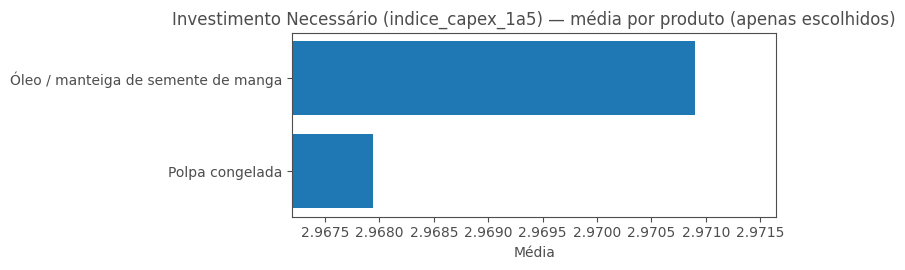


------------------------------------------------------------------------------------------
CONCEITO DA TABELA: Rentabilidade
FEATURE(S) USADA(S) NA BASE: ['margem_media_percentual']
------------------------------------------------------------------------------------------

[Resumo por produto] -> margem_media_percentual
                            produto  count   mean  median    std   min   max
                    Polpa congelada     60 27.807  28.909 11.064  9.41 54.70
Óleo / manteiga de semente de manga     51 29.896  27.800 10.745 11.28 52.99

[Ranking] Percentil do mean (vs dataset inteiro) -> margem_media_percentual
                            produto  percentil_do_mean_no_dataset
                    Polpa congelada                          48.9
Óleo / manteiga de semente de manga                          56.5

[Classificação automática (tercis do dataset)] -> margem_media_percentual  | invertido=False
                            produto classificacao_tercil
                    

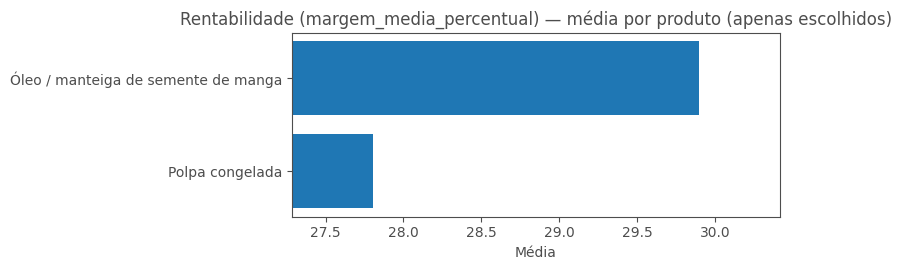


------------------------------------------------------------------------------------------
CONCEITO DA TABELA: Concorrência no mercado
FEATURE(S) USADA(S) NA BASE: ['indice_concorrencia_1a5']
------------------------------------------------------------------------------------------

[Resumo por produto] -> indice_concorrencia_1a5
                            produto  count  mean  median   std  min  max
                    Polpa congelada     60 2.633     2.5 1.041  1.0  5.0
Óleo / manteiga de semente de manga     51 3.087     3.0 1.074  1.0  5.0

[Ranking] Percentil do mean (vs dataset inteiro) -> indice_concorrencia_1a5
                            produto  percentil_do_mean_no_dataset
                    Polpa congelada                          32.1
Óleo / manteiga de semente de manga                          69.9

[Classificação automática (tercis do dataset)] -> indice_concorrencia_1a5  | invertido=True
                            produto classificacao_tercil
                    Pol

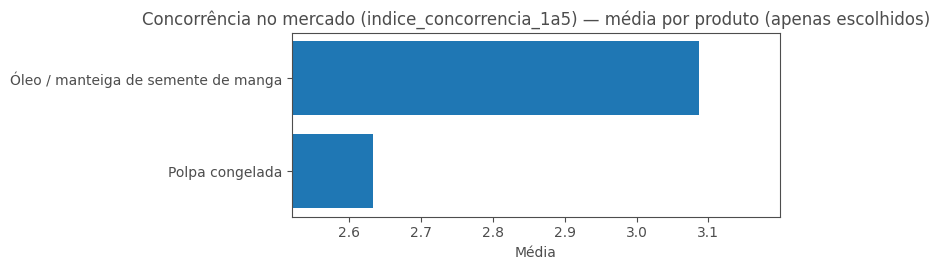


------------------------------------------------------------------------------------------
CONCEITO DA TABELA: Problemas Fiscais
FEATURE(S) USADA(S) NA BASE: ['indice_exigencia_regulatoria_1a5']
------------------------------------------------------------------------------------------

[Resumo por produto] -> indice_exigencia_regulatoria_1a5
                            produto  count  mean  median   std  min  max
                    Polpa congelada     60 2.595   2.852 1.091  1.0  5.0
Óleo / manteiga de semente de manga     51 2.958   3.000 1.248  1.0  5.0

[Ranking] Percentil do mean (vs dataset inteiro) -> indice_exigencia_regulatoria_1a5
                            produto  percentil_do_mean_no_dataset
                    Polpa congelada                          42.9
Óleo / manteiga de semente de manga                          46.9

[Classificação automática (tercis do dataset)] -> indice_exigencia_regulatoria_1a5  | invertido=True
                            produto classificacao_

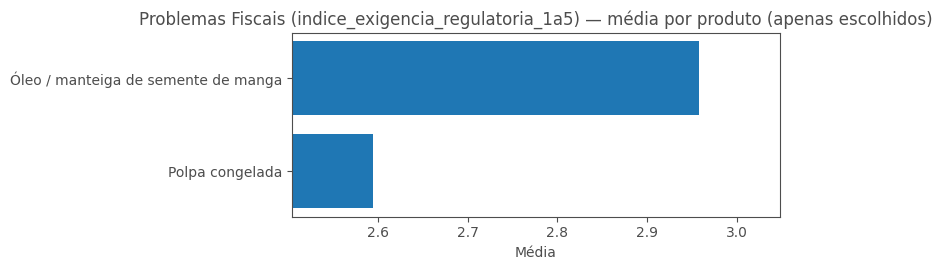


------------------------------------------------------------------------------------------
CONCEITO DA TABELA: Aproveitamento matéria prima
FEATURE(S) USADA(S) NA BASE: ['indice_compatibilidade_refugo_1a5']
------------------------------------------------------------------------------------------

[Resumo por produto] -> indice_compatibilidade_refugo_1a5
                            produto  count  mean  median   std  min  max
                    Polpa congelada     60 2.247     2.0 1.169  1.0  5.0
Óleo / manteiga de semente de manga     51 2.276     2.0 1.196  1.0  5.0

[Ranking] Percentil do mean (vs dataset inteiro) -> indice_compatibilidade_refugo_1a5
                            produto  percentil_do_mean_no_dataset
                    Polpa congelada                          55.4
Óleo / manteiga de semente de manga                          57.3

[Classificação automática (tercis do dataset)] -> indice_compatibilidade_refugo_1a5  | invertido=False
                            produt

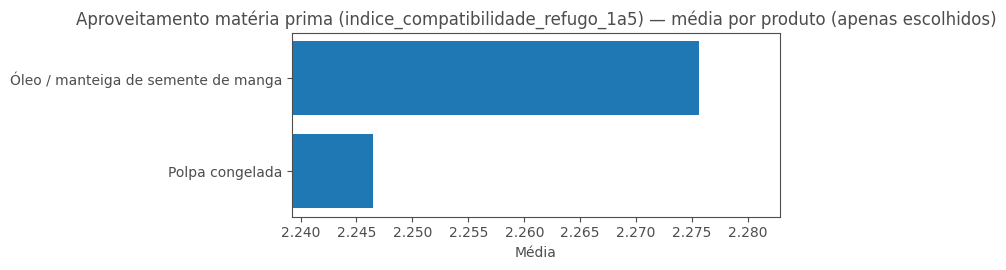


✅ Pronto: agora 'Problemas Fiscais' está embasado por 'indice_exigencia_regulatoria_1a5'.



In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import unicodedata

# ============================================================
# CONFIG
# ============================================================
col_produto = "produto"

produtos_alvo = [
    "Polpa congelada",
    "Óleo / manteiga de semente de manga",
]

# Mapeamento "coluna da tabela" -> "feature(s) do dataset" (base que embasa)
# (AQUI: "Problemas Fiscais" passa a usar indice_exigencia_regulatoria_1a5)
MAPEAMENTO_TABELA = {
    "Investimento Necessário": ["indice_capex_1a5"],
    "Rentabilidade": ["margem_media_percentual"],
    "Concorrência no mercado": ["indice_concorrencia_1a5"],
    "Problemas Fiscais": ["indice_exigencia_regulatoria_1a5"],          # <- alterado
    "Aproveitamento matéria prima": ["indice_compatibilidade_refugo_1a5"],
}

# ============================================================
# HELPERS
# ============================================================
def normalizar_texto(s: str) -> str:
    if s is None:
        return ""
    s = str(s).strip().lower()
    s = unicodedata.normalize("NFKD", s)
    s = "".join(ch for ch in s if not unicodedata.combining(ch))
    s = " ".join(s.split())
    return s

def filtrar_produtos(df: pd.DataFrame, produtos: list[str]) -> pd.DataFrame:
    if col_produto not in df.columns:
        raise KeyError(f"Não encontrei a coluna '{col_produto}' no df.")
    alvo_norm = [normalizar_texto(p) for p in produtos]
    serie_norm = df[col_produto].astype(str).map(normalizar_texto)
    return df.loc[serie_norm.isin(alvo_norm)].copy()

def classificar_tercis(valor: float, q33: float, q66: float, invertido: bool=False) -> str:
    """
    Retorna Baixo/Médio/Alto por tercis.
    invertido=False: maior = melhor/maior (ex: margem, compatibilidade)
    invertido=True: maior = pior/maior (ex: concorrência, capex, exigência regulatória)
    """
    if pd.isna(valor):
        return "Sem dado"
    if not invertido:
        if valor <= q33: return "Baixo"
        if valor <= q66: return "Médio"
        return "Alto"
    else:
        if valor <= q33: return "Baixo"
        if valor <= q66: return "Médio"
        return "Alto"

def resumo_numerico_por_produto(df_prod: pd.DataFrame, feature: str) -> pd.DataFrame:
    s = pd.to_numeric(df_prod[feature], errors="coerce")
    out = (
        df_prod.assign(_x=s)
              .groupby(col_produto)["_x"]
              .agg(count="count", mean="mean", median="median", std="std", min="min", max="max")
              .round(3)
              .reset_index()
    )
    return out

def percentil_do_mean_no_dataset(df_full: pd.DataFrame, df_prod: pd.DataFrame, feature: str) -> pd.DataFrame:
    x_all = pd.to_numeric(df_full[feature], errors="coerce").dropna()
    means_prod = pd.to_numeric(df_prod[feature], errors="coerce").groupby(df_prod[col_produto]).mean()

    def pct(v):
        if pd.isna(v) or len(x_all) == 0:
            return np.nan
        return float((x_all <= v).mean() * 100)

    return (
        means_prod.apply(pct)
                  .rename("percentil_do_mean_no_dataset")
                  .round(1)
                  .reset_index()
    )

def plot_zoom_barh(means: pd.Series, title: str):
    means = means.sort_values()
    plt.figure(figsize=(8, 2.8))
    plt.barh(means.index, means.values)
    plt.title(title)
    plt.xlabel("Média")

    # "DeltaX" (zoom) para evidenciar diferenças
    span = float(means.max() - means.min())
    if span > 0:
        xmin = max(0, float(means.min() - span * 0.25))
        xmax = float(means.max() + span * 0.25)
        plt.xlim(xmin, xmax)

    plt.tight_layout()
    plt.show()

# ============================================================
# EXECUÇÃO
# ============================================================
# Checa se as colunas do mapeamento existem
todas_features = sorted({f for lst in MAPEAMENTO_TABELA.values() for f in lst})
faltando = [f for f in todas_features if f not in df.columns]
if faltando:
    print("⚠️ Algumas features do mapeamento não existem no df (ajuste os nomes):")
    for f in faltando:
        print(" -", f)
    print()

# Filtra produtos alvo
df_sel = filtrar_produtos(df, produtos_alvo)

print("="*90)
print("EVIDÊNCIAS NA BASE — Produtos escolhidos")
print("="*90)
print(df_sel[col_produto].value_counts())

# Para cada "coluna" da tabela (conceito), gera evidências
for conceito, feats in MAPEAMENTO_TABELA.items():
    feats_ok = [f for f in feats if f in df.columns]
    if not feats_ok:
        continue

    print("\n" + "-"*90)
    print(f"CONCEITO DA TABELA: {conceito}")
    print(f"FEATURE(S) USADA(S) NA BASE: {feats_ok}")
    print("-"*90)

    for feat in feats_ok:
        # 1) Resumo numérico por produto
        resumo = resumo_numerico_por_produto(df_sel, feat)
        print(f"\n[Resumo por produto] -> {feat}")
        print(resumo.to_string(index=False))

        # 2) Percentil do mean no dataset
        pcts = percentil_do_mean_no_dataset(df, df_sel, feat)
        print(f"\n[Ranking] Percentil do mean (vs dataset inteiro) -> {feat}")
        print(pcts.to_string(index=False))

        # 3) Classificação Baixo/Médio/Alto (tercis do dataset)
        x_all = pd.to_numeric(df[feat], errors="coerce").dropna()
        if len(x_all) >= 10:
            q33, q66 = x_all.quantile([0.33, 0.66]).values

            # invertido: quanto maior, pior (concorrência, capex, exigência regulatória)
            inv = any(k in feat for k in ["concorrencia", "capex", "exigencia"])

            means_prod = pd.to_numeric(df_sel[feat], errors="coerce").groupby(df_sel[col_produto]).mean()
            veredito = (
                means_prod.apply(lambda v: classificar_tercis(v, q33, q66, invertido=inv))
                          .rename("classificacao_tercil")
                          .reset_index()
            )

            print(f"\n[Classificação automática (tercis do dataset)] -> {feat}  | invertido={inv}")
            print(veredito.to_string(index=False))
        else:
            print("\n(Pulei classificação por tercis: poucos dados válidos no dataset.)")

        # 4) Gráfico comparativo (zoom/DeltaX)
        means = pd.to_numeric(df_sel[feat], errors="coerce").groupby(df_sel[col_produto]).mean()
        if len(means.dropna()) > 0:
            plot_zoom_barh(means, f"{conceito} ({feat}) — média por produto (apenas escolhidos)")

print("\n✅ Pronto: agora 'Problemas Fiscais' está embasado por 'indice_exigencia_regulatoria_1a5'.\n")


In [20]:
import pandas as pd
import numpy as np
import unicodedata

# ============================================================
# CONFIG
# ============================================================
col_produto = "produto"

features = {
    "indice_concorrencia_1a5": "Concorrência",
    "indice_capex_1a5": "CAPEX",
    "indice_exigencia_regulatoria_1a5": "Exigência regulatória",
    "indice_compatibilidade_refugo_1a5": "Compatibilidade com refugo",
    "margem_media_percentual": "Margem média (%)",
}

produtos_tabela = [
    "Snack de manga desidratada",
    "Suco pronto (NFC)",
    "Sorbet / picolé",
    "Biogás / energia",
    "Fragrância para perfumaria",
    "Pó de manga (spray-dried)",
    "Polpa congelada",
    "Óleo / manteiga de semente de manga",
]

# ============================================================
# HELPERS
# ============================================================
def normalizar_texto(s):
    if pd.isna(s):
        return ""
    s = str(s).lower().strip()
    s = unicodedata.normalize("NFKD", s)
    s = "".join(c for c in s if not unicodedata.combining(c))
    return " ".join(s.split())

def filtrar_produtos(df, produtos):
    alvo = [normalizar_texto(p) for p in produtos]
    serie_norm = df[col_produto].astype(str).map(normalizar_texto)
    return df.loc[serie_norm.isin(alvo)].copy()

def classificar_tercil(series):
    q1 = series.quantile(0.33)
    q2 = series.quantile(0.66)

    def label(v):
        if v <= q1:
            return "Baixo"
        elif v <= q2:
            return "Médio"
        else:
            return "Alto"

    return series.apply(label)

# ============================================================
# EXECUÇÃO
# ============================================================
df_sel = filtrar_produtos(df, produtos_tabela)

resultado = []

for feat, nome_legivel in features.items():
    if feat not in df_sel.columns:
        continue

    medias = (
        pd.to_numeric(df_sel[feat], errors="coerce")
        .groupby(df_sel[col_produto])
        .mean()
        .dropna()
    )

    classes = classificar_tercil(medias)

    temp = pd.DataFrame({
        "Produto": medias.index,
        "Feature": nome_legivel,
        "Valor_medio": medias.round(3),
        "Classificacao": classes
    })

    resultado.append(temp)

df_classificado = pd.concat(resultado, ignore_index=True)

# ============================================================
# RESULTADO FINAL
# ============================================================
print("=" * 100)
print("CLASSIFICAÇÃO DOS PRODUTOS — BAIXO / MÉDIO / ALTO (DATA-DRIVEN)")
print("=" * 100)

for feat in df_classificado["Feature"].unique():
    print("\n" + "-" * 100)
    print(f"FEATURE: {feat.upper()}")
    print("-" * 100)

    display(
        df_classificado[df_classificado["Feature"] == feat]
        .sort_values("Valor_medio", ascending=False)
        .reset_index(drop=True)
    )


CLASSIFICAÇÃO DOS PRODUTOS — BAIXO / MÉDIO / ALTO (DATA-DRIVEN)

----------------------------------------------------------------------------------------------------
FEATURE: CONCORRÊNCIA
----------------------------------------------------------------------------------------------------


,Produto,Feature,Valor_medio,Classificacao
0,Óleo / manteiga de semente de manga,Concorrência,3.087,Alto
1,Biogás / energia,Concorrência,3.003,Alto
2,Pó de manga (spray-dried),Concorrência,2.998,Alto
3,Snack de manga desidratada,Concorrência,2.845,Médio
4,Fragrância para perfumaria,Concorrência,2.832,Médio
5,Sorbet / picolé,Concorrência,2.784,Baixo
6,Suco pronto (NFC),Concorrência,2.782,Baixo
7,Polpa congelada,Concorrência,2.633,Baixo



----------------------------------------------------------------------------------------------------
FEATURE: CAPEX
----------------------------------------------------------------------------------------------------


,Produto,Feature,Valor_medio,Classificacao
0,Pó de manga (spray-dried),CAPEX,3.064,Alto
1,Óleo / manteiga de semente de manga,CAPEX,2.971,Alto
2,Polpa congelada,CAPEX,2.968,Alto
3,Suco pronto (NFC),CAPEX,2.842,Médio
4,Fragrância para perfumaria,CAPEX,2.782,Médio
5,Snack de manga desidratada,CAPEX,2.698,Baixo
6,Sorbet / picolé,CAPEX,2.654,Baixo
7,Biogás / energia,CAPEX,2.524,Baixo



----------------------------------------------------------------------------------------------------
FEATURE: EXIGÊNCIA REGULATÓRIA
----------------------------------------------------------------------------------------------------


,Produto,Feature,Valor_medio,Classificacao
0,Sorbet / picolé,Exigência regulatória,2.978,Alto
1,Óleo / manteiga de semente de manga,Exigência regulatória,2.958,Alto
2,Fragrância para perfumaria,Exigência regulatória,2.931,Alto
3,Snack de manga desidratada,Exigência regulatória,2.874,Médio
4,Suco pronto (NFC),Exigência regulatória,2.605,Médio
5,Polpa congelada,Exigência regulatória,2.595,Baixo
6,Pó de manga (spray-dried),Exigência regulatória,2.449,Baixo
7,Biogás / energia,Exigência regulatória,2.409,Baixo



----------------------------------------------------------------------------------------------------
FEATURE: COMPATIBILIDADE COM REFUGO
----------------------------------------------------------------------------------------------------


,Produto,Feature,Valor_medio,Classificacao
0,Sorbet / picolé,Compatibilidade com refugo,2.540,Alto
1,Snack de manga desidratada,Compatibilidade com refugo,2.388,Alto
2,Óleo / manteiga de semente de manga,Compatibilidade com refugo,2.276,Alto
3,Pó de manga (spray-dried),Compatibilidade com refugo,2.247,Médio
4,Polpa congelada,Compatibilidade com refugo,2.247,Médio
5,Biogás / energia,Compatibilidade com refugo,2.232,Baixo
6,Suco pronto (NFC),Compatibilidade com refugo,2.155,Baixo
7,Fragrância para perfumaria,Compatibilidade com refugo,2.135,Baixo



----------------------------------------------------------------------------------------------------
FEATURE: MARGEM MÉDIA (%)
----------------------------------------------------------------------------------------------------


,Produto,Feature,Valor_medio,Classificacao
0,Óleo / manteiga de semente de manga,Margem média (%),29.896,Alto
1,Sorbet / picolé,Margem média (%),27.998,Alto
2,Pó de manga (spray-dried),Margem média (%),27.897,Alto
3,Polpa congelada,Margem média (%),27.807,Médio
4,Suco pronto (NFC),Margem média (%),27.321,Médio
5,Biogás / energia,Margem média (%),26.925,Baixo
6,Fragrância para perfumaria,Margem média (%),26.919,Baixo
7,Snack de manga desidratada,Margem média (%),26.644,Baixo


C:\Users\joaop\AppData\Local\Temp\ipykernel_40616\2605233027.py:87: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  classes_num = classes.applymap(classe_to_num)


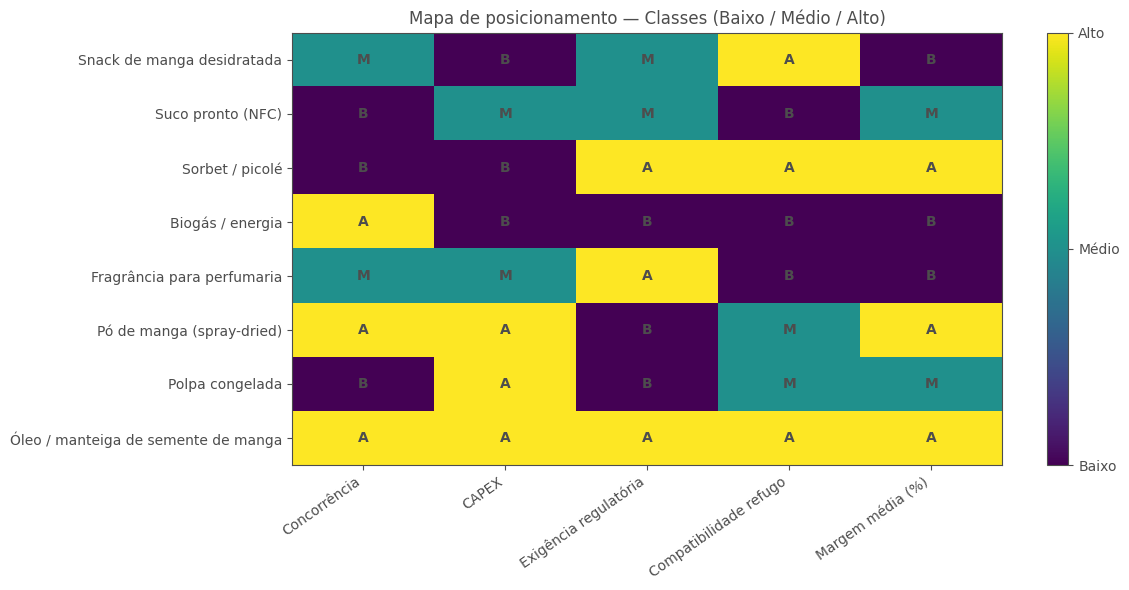

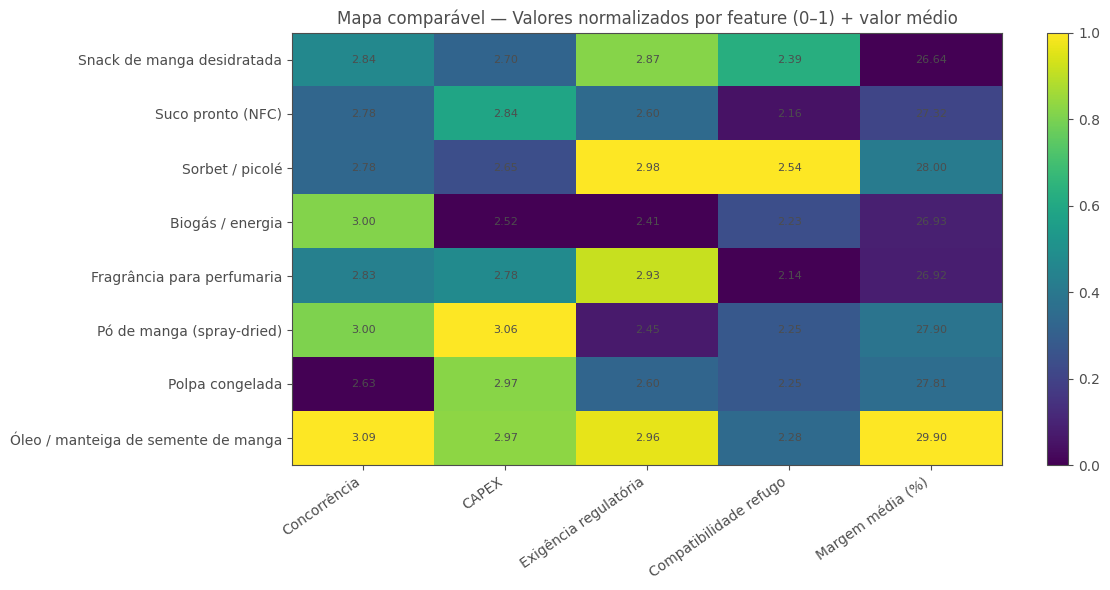

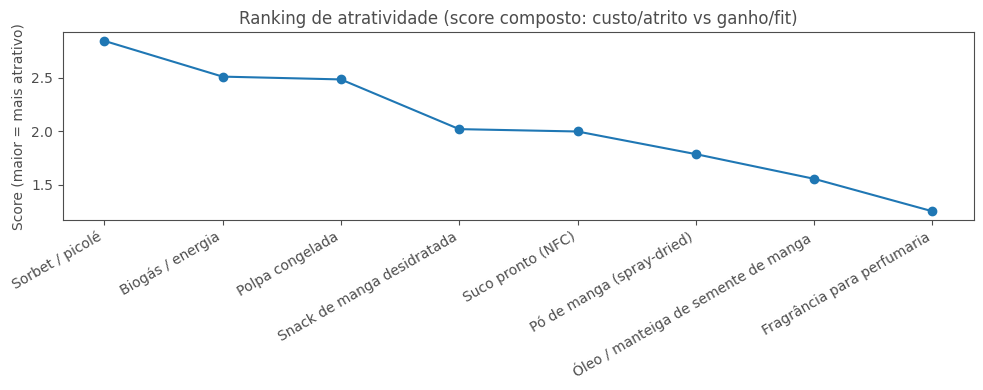

,score_composto
produto,
Sorbet / picolé,2.843
Biogás / energia,2.509
Polpa congelada,2.483
Snack de manga desidratada,2.019
Suco pronto (NFC),1.997
Pó de manga (spray-dried),1.785
Óleo / manteiga de semente de manga,1.554
Fragrância para perfumaria,1.251


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import unicodedata

# ============================================================
# CONFIG
# ============================================================
col_produto = "produto"

features = {
    "indice_concorrencia_1a5": "Concorrência",
    "indice_capex_1a5": "CAPEX",
    "indice_exigencia_regulatoria_1a5": "Exigência regulatória",
    "indice_compatibilidade_refugo_1a5": "Compatibilidade refugo",
    "margem_media_percentual": "Margem média (%)",
}

produtos_tabela = [
    "Snack de manga desidratada",
    "Suco pronto (NFC)",
    "Sorbet / picolé",
    "Biogás / energia",
    "Fragrância para perfumaria",
    "Pó de manga (spray-dried)",
    "Polpa congelada",
    "Óleo / manteiga de semente de manga",
]

# Para as features abaixo, "menor é melhor" (custo/atrito)
menor_melhor = {"Concorrência", "CAPEX", "Exigência regulatória"}
# Para as abaixo, "maior é melhor" (ganho/fit)
maior_melhor = {"Compatibilidade refugo", "Margem média (%)"}

# ============================================================
# HELPERS
# ============================================================
def normalizar_texto(s):
    if pd.isna(s):
        return ""
    s = str(s).lower().strip()
    s = unicodedata.normalize("NFKD", s)
    s = "".join(c for c in s if not unicodedata.combining(c))
    return " ".join(s.split())

def filtrar_produtos(df, produtos):
    alvo = [normalizar_texto(p) for p in produtos]
    serie_norm = df[col_produto].astype(str).map(normalizar_texto)
    return df.loc[serie_norm.isin(alvo)].copy()

def classificar_tercil(series):
    q1 = series.quantile(0.33)
    q2 = series.quantile(0.66)
    def label(v):
        if v <= q1:
            return "Baixo"
        elif v <= q2:
            return "Médio"
        else:
            return "Alto"
    return series.apply(label)

def classe_to_num(cl):
    return {"Baixo": 0, "Médio": 1, "Alto": 2}.get(cl, np.nan)

# ============================================================
# 1) TABELA PRODUTO x FEATURE (VALOR MÉDIO)
# ============================================================
df_sel = filtrar_produtos(df, produtos_tabela)

media_por_prod = {}
for feat, nome in features.items():
    if feat not in df_sel.columns:
        continue
    s = pd.to_numeric(df_sel[feat], errors="coerce")
    media_por_prod[nome] = s.groupby(df_sel[col_produto]).mean()

M = pd.DataFrame(media_por_prod).reindex(produtos_tabela)

# ============================================================
# 2) CLASSIFICAÇÃO BAIXO/MÉDIO/ALTO (por feature)
# ============================================================
classes = pd.DataFrame(index=M.index, columns=M.columns, dtype=object)
for col in M.columns:
    classes[col] = classificar_tercil(M[col].dropna()).reindex(M.index)

classes_num = classes.applymap(classe_to_num)

# ============================================================
# 3) HEATMAP 1 — CLASSES (0/1/2) com legenda Baixo/Médio/Alto
# ============================================================
plt.figure(figsize=(12, 6))
im = plt.imshow(classes_num.values, aspect="auto")

plt.title("Mapa de posicionamento — Classes (Baixo / Médio / Alto)")
plt.yticks(range(len(classes_num.index)), classes_num.index)
plt.xticks(range(len(classes_num.columns)), classes_num.columns, rotation=35, ha="right")

# anotações: B/M/A dentro da célula
for i in range(classes_num.shape[0]):
    for j in range(classes_num.shape[1]):
        txt = classes.iloc[i, j]
        if pd.isna(classes_num.iloc[i, j]):
            continue
        plt.text(j, i, txt[0], ha="center", va="center", fontsize=10, fontweight="bold")  # B/M/A

# barra com ticks custom
cbar = plt.colorbar(im, ticks=[0, 1, 2])
cbar.ax.set_yticklabels(["Baixo", "Médio", "Alto"])
plt.tight_layout()
plt.show()

# ============================================================
# 4) HEATMAP 2 — VALORES NORMALIZADOS (0–1) + valor real anotado
#    (Insight: comparabilidade entre features com escalas diferentes)
# ============================================================
# normaliza coluna a coluna
M_norm = (M - M.min()) / (M.max() - M.min())

plt.figure(figsize=(12, 6))
im2 = plt.imshow(M_norm.values, aspect="auto")

plt.title("Mapa comparável — Valores normalizados por feature (0–1) + valor médio")
plt.yticks(range(len(M_norm.index)), M_norm.index)
plt.xticks(range(len(M_norm.columns)), M_norm.columns, rotation=35, ha="right")

# anota valor real (média) em cada célula
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        v = M.iloc[i, j]
        if pd.isna(v):
            continue
        plt.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8)

plt.colorbar(im2)
plt.tight_layout()
plt.show()

# ============================================================
# 5) INSIGHT OBJETIVO: "Vantagem competitiva" por produto
#    score: soma de pontos onde "menor é melhor" é invertido
# ============================================================
score = pd.Series(0.0, index=M.index)

for col in M.columns:
    col_norm = M_norm[col]
    if col in menor_melhor:
        score += (1 - col_norm)   # menor melhor => inverte
    else:
        score += col_norm         # maior melhor => direto

score = score.sort_values(ascending=False)

plt.figure(figsize=(10, 4))
plt.plot(score.values, marker="o")
plt.title("Ranking de atratividade (score composto: custo/atrito vs ganho/fit)")
plt.xticks(range(len(score.index)), score.index, rotation=30, ha="right")
plt.ylabel("Score (maior = mais atrativo)")
plt.tight_layout()
plt.show()

display(score.to_frame("score_composto").round(3))


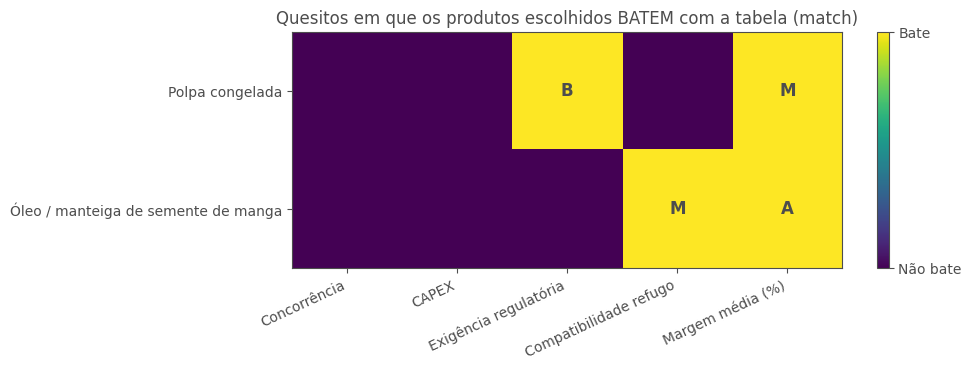

,produto,quesito,classe_obtida_base,classe_tabela,match
0,Polpa congelada,Concorrência,B,A,False
1,Polpa congelada,CAPEX,A,M,False
2,Polpa congelada,Exigência regulatória,B,B,True
3,Polpa congelada,Compatibilidade refugo,M,A,False
4,Polpa congelada,Margem média (%),M,M,True
5,Óleo / manteiga de semente de manga,Concorrência,A,B,False
6,Óleo / manteiga de semente de manga,CAPEX,A,M,False
7,Óleo / manteiga de semente de manga,Exigência regulatória,A,M,False
8,Óleo / manteiga de semente de manga,Compatibilidade refugo,M,M,True
9,Óleo / manteiga de semente de manga,Margem média (%),A,A,True


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import unicodedata

# ============================================================
# CONFIG
# ============================================================
col_produto = "produto"

features = {
    "indice_concorrencia_1a5": "Concorrência",
    "indice_capex_1a5": "CAPEX",
    "indice_exigencia_regulatoria_1a5": "Exigência regulatória",
    "indice_compatibilidade_refugo_1a5": "Compatibilidade refugo",
    "margem_media_percentual": "Margem média (%)",
}

produtos_escolhidos = [
    "Polpa congelada",
    "Óleo / manteiga de semente de manga",
]

# ✅ DEFINA AQUI O QUE A SUA TABELA DIZ (B/M/A) PARA CADA QUESITO
# Use: "B", "M", "A"
tabela_alvo = {
    "Polpa congelada": {
        "Concorrência": "A",             # <-- ajuste conforme sua tabela
        "CAPEX": "M",
        "Exigência regulatória": "B",
        "Compatibilidade refugo": "A",
        "Margem média (%)": "M",
    },
    "Óleo / manteiga de semente de manga": {
        "Concorrência": "B",
        "CAPEX": "M",
        "Exigência regulatória": "M",
        "Compatibilidade refugo": "M",
        "Margem média (%)": "A",
    }
}

# ============================================================
# HELPERS
# ============================================================
def normalizar_texto(s):
    if pd.isna(s):
        return ""
    s = str(s).lower().strip()
    s = unicodedata.normalize("NFKD", s)
    s = "".join(c for c in s if not unicodedata.combining(c))
    return " ".join(s.split())

def filtrar_produtos(df, produtos):
    alvo = [normalizar_texto(p) for p in produtos]
    serie_norm = df[col_produto].astype(str).map(normalizar_texto)
    return df.loc[serie_norm.isin(alvo)].copy()

def classificar_tercil(series):
    q1 = series.quantile(0.33)
    q2 = series.quantile(0.66)

    def label(v):
        if v <= q1:
            return "B"  # Baixo
        elif v <= q2:
            return "M"  # Médio
        else:
            return "A"  # Alto

    return series.apply(label)

# ============================================================
# 1) MÉDIA POR PRODUTO (2 escolhidos) + CLASSE B/M/A POR FEATURE
# ============================================================
df_sel = filtrar_produtos(df, produtos_escolhidos)

# tabela de médias (produto x feature)
M = pd.DataFrame(index=produtos_escolhidos, columns=list(features.values()), dtype=float)

for feat, nome in features.items():
    s = pd.to_numeric(df_sel[feat], errors="coerce")
    medias = s.groupby(df_sel[col_produto]).mean()
    # alinha no index dos escolhidos
    M[nome] = medias.reindex(produtos_escolhidos).values

# classes B/M/A calculadas a partir das médias ENTRE TODOS OS PRODUTOS DA BASE (para ser consistente)
# (se você preferir usar só os produtos da tabela, eu adapto)
df_all = df.copy()
media_all = {}
for feat, nome in features.items():
    s = pd.to_numeric(df_all[feat], errors="coerce")
    media_all[nome] = s.groupby(df_all[col_produto]).mean()

M_all = pd.DataFrame(media_all)

classes_all = pd.DataFrame(index=M_all.index, columns=M_all.columns, dtype=object)
for col in M_all.columns:
    classes_all[col] = classificar_tercil(M_all[col].dropna()).reindex(M_all.index)

# pega só os 2 produtos escolhidos
classes_escolhidos = classes_all.reindex(produtos_escolhidos)

# ============================================================
# 2) MATRIZ DE "MATCH": 1 se classe calculada == classe da tabela
# ============================================================
match = pd.DataFrame(0, index=produtos_escolhidos, columns=list(features.values()), dtype=int)

for prod in produtos_escolhidos:
    for col in match.columns:
        esperado = tabela_alvo.get(prod, {}).get(col, None)
        obtido = classes_escolhidos.loc[prod, col]
        if esperado is not None and (str(obtido) == str(esperado)):
            match.loc[prod, col] = 1

# ============================================================
# 3) PLOT: HEATMAP BINÁRIO (MATCH), COM LETRA ESPERADA
# ============================================================
plt.figure(figsize=(10, 3.8))
im = plt.imshow(match.values, aspect="auto")

plt.title("Quesitos em que os produtos escolhidos BATEM com a tabela (match)")
plt.yticks(range(len(match.index)), match.index)
plt.xticks(range(len(match.columns)), match.columns, rotation=25, ha="right")

# anotações: só escreve quando for match
for i, prod in enumerate(match.index):
    for j, col in enumerate(match.columns):
        if match.iloc[i, j] == 1:
            letra = tabela_alvo[prod][col]
            plt.text(j, i, letra, ha="center", va="center", fontsize=12, fontweight="bold")

# colorbar simples
cbar = plt.colorbar(im, ticks=[0, 1])
cbar.ax.set_yticklabels(["Não bate", "Bate"])

plt.tight_layout()
plt.show()

# ============================================================
# 4) (OPCIONAL) MOSTRA A TABELA RESUMO: obtido vs esperado
# ============================================================
resumo = []
for prod in produtos_escolhidos:
    for col in match.columns:
        resumo.append({
            "produto": prod,
            "quesito": col,
            "classe_obtida_base": classes_escolhidos.loc[prod, col],
            "classe_tabela": tabela_alvo.get(prod, {}).get(col, None),
            "match": bool(match.loc[prod, col])
        })

resumo_df = pd.DataFrame(resumo)
display(resumo_df)
